In [1]:
# Import von Bibliotheken
from datasets import load_dataset
import urllib.request
import io,re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import os
# Deutsche Stopwörter laden
!pip install nltk
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')

from nltk.corpus import stopwords
nltk.download('stopwords')
stopwords = stopwords.words('german')

from sklearn.feature_extraction.text import CountVectorizer
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline
!pip install sentence-transformers

[nltk_data] Downloading package punkt to /home/haloh001/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/haloh001/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
!pip install "transformers==4.47.1" "sentence-transformers"
from sentence_transformers import SentenceTransformer

In [3]:
# Einlesen der Langwahlprogramme (aus JSON-Format in ein Wörterbuch)

# für CDU/CSU
with open("cdu-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    CDU_text_json = json.load(datei)

# für SPD
with open("spd-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    SPD_text_json = json.load(datei)

# für Die Linke
with open("linke-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    Linke_text_json = json.load(datei)

# für die AfD
with open("afd-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    AfD_text_json = json.load(datei)

# für Bündnis 90/Grüne
with open("gruene-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    Grüne_text_json = json.load(datei)

# für FDP
with open("fdp-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    FDP_text_json = json.load(datei)

In [4]:
# Überführen aller 'eigentlichen' Texte in eine Liste pro Partei, d.h. ohne Kapitelüberschriften

# Suchfunktion in den "Partei-Wörterbüchern"

def finde_gefilterte_texte(struktur):
    ergebnisse = []
    
    # Fall A: Wenn das aktuelle Element ein Dictionary ist
    if isinstance(struktur, dict):
        # Typ/Art auslesen (liefert None, wenn der Schlüssel fehlt)
        aktueller_typ = struktur.get('type') or struktur.get('art')            # nur Suchen in diesen Elementen
        
        # Prüfen, ob 'text' existiert und der gefundene Typ gültig ist
        if 'text' in struktur and aktueller_typ in ['paragraph', 'bullet', 'absatz']:   # nur Texte überführen mit diesem Typ
            ergebnisse.append(struktur['text'])
        
        # Tiefer in alle Werte schauen für eventuelle Verschachtelungen
        for wert in struktur.values():
            ergebnisse.extend(finde_gefilterte_texte(wert))
                
    # Fall B: Wenn das aktuelle Element eine Liste ist
    elif isinstance(struktur, list):
        for element in struktur:
            ergebnisse.extend(finde_gefilterte_texte(element))
            
    return ergebnisse

CDU_text = finde_gefilterte_texte(CDU_text_json)
CDU_text = CDU_text[135:]   # da vor der eigentlichen Langfassung im CDU/CSU-Programm noch eine Kurzfassung vorangeht, wird diese ausgeblendet
SPD_text = finde_gefilterte_texte(SPD_text_json)
Linke_text = finde_gefilterte_texte(Linke_text_json)
Grüne_text = finde_gefilterte_texte(Grüne_text_json)
AfD_text = finde_gefilterte_texte(AfD_text_json)
FDP_text = finde_gefilterte_texte(FDP_text_json)

In [5]:
# durchschnittliche Anzahl der Länge jedes einzelnen Dokuments pro Partei VOR BEREINIGUNG
# zur Orientierung die Anzahl der Absätze mit einer Länge von max. 100 Zeichen
durchschnitt_CDU = round(sum(len(s) for s in CDU_text) / len(CDU_text),1)
anzahl_CDU = len([i for i in CDU_text if len(i) < 100])
print("Durchschnittliche Zeichenlänge eines Absatzes im CDU-Programm: ",durchschnitt_CDU)
print("Anzahl aller Absätze: ",len(CDU_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_CDU)
print("-----")
durchschnitt_SPD = round(sum(len(s) for s in SPD_text) / len(SPD_text),1)
anzahl_SPD = len([i for i in SPD_text if len(i) < 100])
print("Durchschnittliche Zeichenlänge eines Absatzes im SPD-Programm: ",durchschnitt_SPD)
print("Anzahl aller Absätze: ",len(SPD_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_SPD)
print("-----")
durchschnitt_Linke = round(sum(len(s) for s in Linke_text) / len(Linke_text),1)
anzahl_Linke = len([i for i in Linke_text if len(i) < 100])
print("Durchschnittliche Zeichenlänge eines Absatzes im Linke-Programm: ",durchschnitt_Linke)
print("Anzahl aller Absätze: ",len(Linke_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_Linke)
print("-----")
durchschnitt_AfD = round(sum(len(s) for s in AfD_text) / len(AfD_text),1)
anzahl_AfD = len([i for i in AfD_text if len(i) < 100])
print("Durchschnittliche Zeichenlänge eines Absatzes im AfD-Programm: ",durchschnitt_AfD)
print("Anzahl aller Absätze: ",len(AfD_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_AfD)
print("-----")
durchschnitt_Grüne = round(sum(len(s) for s in Grüne_text) / len(Grüne_text),1)
anzahl_Grüne = len([i for i in Grüne_text if len(i) < 100])
print("Durchschnittliche Zeichenlänge eines Absatzes im Grüne-Programm: ",durchschnitt_Grüne)
print("Anzahl aller Absätze: ",len(Grüne_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_Grüne)
print("-----")
durchschnitt_FDP = round(sum(len(s) for s in FDP_text) / len(FDP_text),1)
anzahl_FDP = len([i for i in FDP_text if len(i) < 100])
print("Durchschnittliche Zeichenlänge eines Absatzes im FDP-Programm: ",durchschnitt_FDP)
print("Anzahl aller Absätze: ",len(FDP_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_FDP)
print("-----")

Durchschnittliche Zeichenlänge eines Absatzes im CDU-Programm:  280.7
Anzahl aller Absätze:  660
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  123
-----
Durchschnittliche Zeichenlänge eines Absatzes im SPD-Programm:  465.3
Anzahl aller Absätze:  444
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  15
-----
Durchschnittliche Zeichenlänge eines Absatzes im Linke-Programm:  380.0
Anzahl aller Absätze:  665
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  30
-----
Durchschnittliche Zeichenlänge eines Absatzes im AfD-Programm:  299.6
Anzahl aller Absätze:  717
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  108
-----
Durchschnittliche Zeichenlänge eines Absatzes im Grüne-Programm:  649.5
Anzahl aller Absätze:  583
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  7
-----
Durchschnittliche Zeichenlänge eines Absatzes im FDP-Programm:  751.7
Anzahl aller Absätze:  200
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  1
-----


In [6]:
# Ziele:
# 1.) bestimmte String-Elemente / Absätze löschen, da diese für BERTopic u. U. sehr kurz sind, wie z.B. kurze Überschriften usw.
#     die Absätze der CDU/CSU- und AfD-Wahlprogramme sind im Vergleich im Schnitt viel kürzer als die der anderen Parteien
#
# 2.) nacheinander folgende bullet points zusammenfügen, da diese höchstwahrscheinlich zum selben Thema gehören;
#     auch zwecks Vermeidung einer möglichen Ungleichgewichtung, da jeder Absatz unabhängig seiner Länge als einzelnes Dokument gezählt wird.
#     Somit fallen einzelne kurze bullet points ungleich höher ins Gewicht als z.B. ein längerer ausformulierter Satz
#     Beispiel:
#     Textkorpus über 2 Themencluster 'Gesundheit' und 'Bildung'
#     9 einzelne Sätze in bullet-points-Form zur Gesundheit sowie 9 lange Sätze als 1 zusammenhängender Absatz zum Thema Bildung
#     würden ohne diesen Ansatz annahmegemäß zwar korrekt geclustert, aber im 'falschen' Verhältnis:
#     Statt 1:1 (9 x 1 kurze Sätze vs. 1 x 9 lange Sätze als ganzer Absatz) würden die einzelnen Dokumente mit 9:1 gewertet
#     und so getan, also ob der Text 9 mal mehr über Gesundheit statt über Bildung 'spricht', obwohl die Zeichenlänge identisch ist

# SCHRITT 1: LÖSCHEN VON ABSÄTZEN (für Ziel 1)
# sich pro Partei einzelne Absätze anzeigen lassen mit jeweils einer maximalen Länge von x Zeichen
# um fallbezogen zu entscheiden, bis zu welcher Länge bzw. welche Absätze ggf. manuell gelöscht werden müssen

In [7]:
# für das Wahlprogramm der FDP

for index, i in enumerate(FDP_text):
  if len(i) < 150:
    print(index, i)

1 Denn: Alles lässt sich ändern.


In [8]:
FDP_text = [text for text in FDP_text if len(text) >= 60]
durchschnitt_FDP_neu = round(sum(len(s) for s in FDP_text) / len(FDP_text),1)
anzahl_FDP_neu = len([i for i in FDP_text if len(i) < 100])
print("Aktualisierte durchschnittliche Länge eines Absatzes im FDP-Programm: ",durchschnitt_FDP_neu, "(alt: ",durchschnitt_FDP, ")")
print("Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_FDP_neu, "(alt: ",anzahl_FDP, ")")

Aktualisierte durchschnittliche Länge eines Absatzes im FDP-Programm:  755.3 (alt:  751.7 )
Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen:  0 (alt:  1 )


In [9]:
# für das Wahlprogramm der SPD

for index, i in enumerate(SPD_text):
  if len(i) < 125:
    print(index, i)

1 Deutschland steht vor bedeutenden Entscheidungen:
2 • Investieren wir jetzt weiter kraftvoll in unser Land? Oder lassen wir unsere Bahn, unsere Straßen und Brücken verkommen?
8 Selten in den vergangenen Jahrzehnten waren klare Haltung, Charakter und Erfahrung so entscheidend.
11 Dafür stehen wir.
13 Wir sagen: Das alles schadet Deutschland. Das ist nicht unser Weg.
22 Genau deshalb braucht Deutschland in dieser schwierigen Zeit eine starke SPD:
24 • Wir investieren weiter in Schienen, Brücken und digitale Netze.
28 • Wir kämpfen für innere und äußere Sicherheit und stellen uns den Feinden der offenen Gesellschaft konsequent entgegen.
29 • Wir sorgen dafür, dass Kitas und Schulen zuverlässig an der Seite der Familien stehen.
33 Politik mit Maß und Mitte, die verbindet und nicht spaltet.
34 Darauf kommt es jetzt an.
35 Darüber entscheiden die Wählerinnen und Wähler bei der Bundestagswahl am 23. Februar 2025.
49 Wir werden außerdem den Kauf von E-Autos stärker ankurbeln.
52 Wir können e

In [10]:
# Herauslöschen der unerwünschten Texte
# wir gehen nicht nach Länge, da teils längere Text inhaltslos sind und kürzere nicht
# manuelles Löschen bevorzugt statt pauschales Löschen z.B. "alles < 60 Zeichen"

# einzelne Löschen von Indizes verschiebt diese, daher der Weg über eine Liste
loesch_indizes = {1, 8, 11, 13, 22, 33, 34, 35, 52}

# Neue Liste erstellen ohne die unerwünschten Indizes
SPD_text = [element for index, element in enumerate(SPD_text) if index not in loesch_indizes]

durchschnitt_SPD_neu = round(sum(len(s) for s in SPD_text) / len(SPD_text),1)
anzahl_SPD_neu = len([i for i in SPD_text if len(i) < 100])
print("Aktualisierte durchschnittliche Länge eines Absatzes im SPD-Programm: ",durchschnitt_SPD_neu, "(alt: ",durchschnitt_SPD, ")")
print("Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_SPD_neu, "(alt: ",anzahl_SPD, ")")

Aktualisierte durchschnittliche Länge eines Absatzes im SPD-Programm:  473.6 (alt:  465.3 )
Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen:  6 (alt:  15 )


In [11]:
# für das Wahlprogramm der Linke

for index, i in enumerate(Linke_text):
  if len(i) < 110:
    print(index, i)

13 Unsere Leitlinie heißt: Wir gemeinsam gegen die da oben.
46 ▪ Die Grundsteuer darf nicht mehr als Teil der Betriebskosten auf die Mieter*innen umgelegt werden.
55 ▪ Investitionen in den sozialen Wohnungsbau müssen von der Schuldenbremse ausgenommen werden.
75 Geschätzte jährliche Mehreinnahmen: 108 Milliarden Euro
93 Geschätzte jährliche Mehreinnahmen: 17 Milliarden Euro
101 Geschätzte jährliche Mehreinnahmen: 42 Milliarden Euro
104 Geschätzte jährliche Mehreinnahmen: 18 Milliarden Euro
106 Geschätzte jährliche Mehreinnahmen: 36 Milliarden Euro
115 Geschätzte jährliche Mehreinnahmen: 18 Milliarden Euro
159 ▪ Wir setzen uns zudem für eine Stärkung der Kinder- und Jugendhilfe ein.
161 Senior*innen müssen in allen gesellschaftlichen Bereichen gleichberechtigt teilhaben können.
205 ▪ Wir stärken Präventions-, Beratungs- und Hilfsangebote.
287 ▪ für eine Anschubfinanzierung für neue Batterietechnologien und Energiespeicher;
305 ▪ Wir wollen die KfZ-Steuer neugestalten und große und schwe

In [12]:
# Herauslöschen der unerwünschten Texte, analog des Ansatzes bei der SPD
loesch_indizes = {13, 75, 93, 101, 104, 106, 115}
Linke_text = [element for index, element in enumerate(Linke_text) if index not in loesch_indizes]

durchschnitt_Linke_neu = round(sum(len(s) for s in Linke_text) / len(Linke_text),1)
anzahl_Linke_neu = len([i for i in Linke_text if len(i) < 100])
print("Aktualisierte durchschnittliche Länge eines Absatzes im Linke-Programm: ",durchschnitt_Linke_neu, "(alt: ",durchschnitt_Linke, ")")
print("Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_Linke_neu, "(alt: ",anzahl_Linke, ")")

Aktualisierte durchschnittliche Länge eines Absatzes im Linke-Programm:  383.5 (alt:  380.0 )
Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen:  23 (alt:  30 )


In [13]:
# für das Wahlprogramm der Grüne

for index, i in enumerate(Grüne_text):
  if len(i) < 170:
    print(index, i)

8 Nehmen wir unsere ökologische und ökonomische Zukunft in die Hand! Wachsen wir in die Zukunft!
10 Das verlangt von der Politik: Kurs halten. Verlässlichkeit herstellen. Regeln und Normen vereinfachen. Kurz: mehr ermöglichen.
13 Nehmen wir unsere soziale Zukunft in die Hand! Sorgen wir dafür, dass alle Menschen fair dabei sind und die Dinge des alltäglichen Lebens bezahlbar sind!
16 Nehmen wir unsere gesellschaftliche und demokratische Zukunft in die Hand! Sichern wir unseren Frieden in Freiheit!
23 Dafür bitten wir bei der kommenden Bundestagswahl um Ihr Vertrauen und Ihre Stimme!
24 Nehmen wir unsere Zukunft zusammen in die Hand! Wachsen wir zusammen!
92 Wir werden unsere öffentliche Verwaltung konsequent modernisieren, digitalisieren und an den Bedürfnissen der Menschen ausrichten.
164 Unsere Kulturlandschaft ist Lebensraum vieler gefährdeter Arten – wir wollen Landnutzung und Naturschutz in Einklang bringen.
186 Die Meeres- und Polarforschung liefert dafür wichtige Beiträge. Wir s

In [14]:
# Herauslöschen der unerwünschten Texte, analog des Ansatzes bei der SPD
loesch_indizes = {8, 10, 13, 16, 23, 24}
Grüne_text = [element for index, element in enumerate(Grüne_text) if index not in loesch_indizes]

durchschnitt_Grüne_neu = round(sum(len(s) for s in Grüne_text) / len(Grüne_text),1)
anzahl_Grüne_neu = len([i for i in Grüne_text if len(i) < 100])
print("Aktualisierte durchschnittliche Länge eines Absatzes im Grüne-Programm: ",durchschnitt_Grüne_neu, "(alt: ",durchschnitt_Grüne, ")")
print("Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_Grüne_neu, "(alt: ",anzahl_Grüne, ")")

Aktualisierte durchschnittliche Länge eines Absatzes im Grüne-Programm:  655.2 (alt:  649.5 )
Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen:  4 (alt:  7 )


In [15]:
# für das Wahlprogramm der AfD

for index, i in enumerate(AfD_text):
  if len(i) < 200:
    print(index, i)

0 Wir stehen fest zu den Prinzipien der Sozialen Marktwirtschaft, die seit Jahrzehnten Wohlstand und sozialen Frieden in unserem Land sichern.
3 Wir treten dafür ein, dass Arbeitnehmer immer deutlich bessergestellt sind als Empfänger von Sozialleistungen. Ihre Arbeit soll eine auskömmliche und sichere Rente gewährleisten.
12 Vor allem für Mittelstand und Landwirtschaft sind die strangulierenden Vorgaben der Politik nicht mehr zu bewältigen. Viele Betriebe geben auf oder suchen neue Chancen im Ausland.
15 Damit Unternehmer an die Zukunft des Standorts Deutschland glauben können, werden wir den Zugang zu sicherer und bezahlbarer Energie wiederherstellen durch:
16 • Verlängerung der Laufzeiten der Kohlekraftwerke
17 • Wiedereinstieg in die Nutzung der Kernenergie
18 • Reparatur und Wiederinbetriebnahme der Nord-Stream-Pipelines
19 • Aufhebung des Verbots von Gas- und Ölheizungen
20 • Abschaffung der CO₂-Abgabe
21 • Reduzierung der Energiesteuer und Senkung der Stromsteuer auf das Minimum


In [16]:
# Herauslöschen der unerwünschten Texte, analog des Ansatzes bei der SPD
loesch_indizes = {0,}
AfD_text = [element for index, element in enumerate(AfD_text) if index not in loesch_indizes]

durchschnitt_AfD_neu = round(sum(len(s) for s in AfD_text) / len(AfD_text),1)
anzahl_AfD_neu = len([i for i in AfD_text if len(i) < 100])
print("Aktualisierte durchschnittliche Länge eines Absatzes im AfD-Programm: ",durchschnitt_AfD_neu, "(alt: ",durchschnitt_AfD, ")")
print("Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_AfD_neu, "(alt: ",anzahl_AfD, ")")

Aktualisierte durchschnittliche Länge eines Absatzes im AfD-Programm:  299.8 (alt:  299.6 )
Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen:  108 (alt:  108 )


In [17]:
# für das Wahlprogramm der CDU

for index, i in enumerate(CDU_text):
  if len(i) < 90:
    print(index, i)

6 Wir wollen ein Land, das wieder Wohlstand für alle schafft.
7 Wir wollen ein Land, das frei und wieder sicher ist.
8 Wir wollen ein Land, das wieder zusammenhält.
9 Wir wollen Deutschland wieder nach vorne bringen.
10 Ein Deutschland, auf das wir wieder stolz sein können.
13 Wir wollen ein Land, das wieder Wohlstand für alle schafft.
14 Wir wollen Deutschland wieder nach vorne bringen.
15 Ein Deutschland, auf das wir wieder stolz sein können.
16 Unser Plan:
17 Leistung muss sich wieder lohnen.
18 Arbeitsrecht modernisieren.
19 Arbeits- und Fachkräfte gewinnen.
20 Wir handeln.
41 Unser Plan:
42 Steuerlast verringern.
43 Bürokratie spürbar abbauen.
44 Steuern vereinfachen.
45 Resilienz der Wirtschaft stärken.
46 Freien Handel und Exporte unterstützen.
47 Wir handeln.
96 Unser Plan:
97 Für bezahlbare Energie sorgen.
98 Bei Energieinnovationen Spitze sein.
99 Wir handeln.
118 Unser Plan:
119 Klimaziele einhalten.
120 Emissionshandel richtig umsetzen.
121 Ressourcen nachhaltig nutzen.
122

In [18]:
# Anderer Ansatz: Herauslöschen der Strings unter 90 Zeichen
# diese fassen im Vorfeld die Punkte zusammen, die anschließend ausführlich in längeren Fließtexten samt bullet points folgen

CDU_text = [text for text in CDU_text if len(text) >= 89]

durchschnitt_CDU_neu = round(sum(len(s) for s in CDU_text) / len(CDU_text),1)
anzahl_CDU_neu = len([i for i in CDU_text if len(i) < 100])
print("Aktualisierte durchschnittliche Länge eines Absatzes im CDU-Programm: ",durchschnitt_CDU_neu, "(alt: ",durchschnitt_CDU, ")")
print("Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_CDU_neu, "(alt: ",anzahl_CDU, ")")

Aktualisierte durchschnittliche Länge eines Absatzes im CDU-Programm:  336.5 (alt:  280.7 )
Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen:  2 (alt:  123 )


In [19]:
# aktualisierte durchschnittliche Länge jedes einzelnen Dokuments pro Partei NACH BEREINIGUNG
print("Durchschnittliche Länge eines Absatzes im CDU-Programm: ",durchschnitt_CDU_neu)
print("Anzahl der Gesamtabsätze: ",len(CDU_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_CDU_neu)
print("Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %: ",round(anzahl_CDU_neu/len(CDU_text)*100,2))
print("-----")
print("Durchschnittliche Länge eines Absatzes im SPD-Programm: ",durchschnitt_SPD_neu)
print("Anzahl der Gesamtabsätze: ",len(SPD_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_SPD_neu)
print("Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %: ",round(anzahl_SPD_neu/len(SPD_text)*100,2))
print("-----")
print("Durchschnittliche Länge eines Absatzes im Linke-Programm: ",durchschnitt_Linke_neu)
print("Anzahl der Gesamtabsätze: ",len(Linke_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_Linke_neu)
print("Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %: ",round(anzahl_Linke_neu/len(Linke_text)*100,2))
print("-----")
print("Durchschnittliche Länge eines Absatzes im AfD-Programm: ",durchschnitt_AfD_neu)
print("Anzahl der Gesamtabsätze: ",len(AfD_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_AfD_neu)
print("Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %: ",round(anzahl_AfD_neu/len(AfD_text)*100,2))
print("-----")
print("Durchschnittliche Länge eines Absatzes im Grüne-Programm: ",durchschnitt_Grüne_neu)
print("Anzahl der Gesamtabsätze: ",len(Grüne_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_Grüne_neu)
print("Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %: ",round(anzahl_Grüne_neu/len(Grüne_text)*100,2))
print("-----")
print("Durchschnittliche Länge eines Absatzes im FDP-Programm: ",durchschnitt_FDP_neu)
print("Anzahl der Gesamtabsätze: ",len(FDP_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_FDP_neu)
print("Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %: ",round(anzahl_FDP_neu/len(FDP_text)*100,2))
print("-----")

Durchschnittliche Länge eines Absatzes im CDU-Programm:  336.5
Anzahl der Gesamtabsätze:  539
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  2
Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %:  0.37
-----
Durchschnittliche Länge eines Absatzes im SPD-Programm:  473.6
Anzahl der Gesamtabsätze:  435
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  6
Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %:  1.38
-----
Durchschnittliche Länge eines Absatzes im Linke-Programm:  383.5
Anzahl der Gesamtabsätze:  658
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  23
Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %:  3.5
-----
Durchschnittliche Länge eines Absatzes im AfD-Programm:  299.8
Anzahl der Gesamtabsätze:  716
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  108
Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %:  15.08
-----
Durchschnittliche Länge eines Absatzes im Grüne-Programm:  655.2
Anzahl der Gesamtabsätze:  577
Anzahl 

In [20]:
# SCHRITT 2: ZUSAMMENFASSEN DER BULLET POINTS UND ANHÄNGEN DIESER 'GESAMMELTEN BULLET POINTS'
#            an an den vorherigen (normalen Fließtext-)Absatz (für Ziel 2)

# zunächst die Ermittlung wie viele Absätze 'bullet points' sind, d.h. mit Sonderzeichen wie Bindestrich oder '•' beginnen

print(f"Gefundene Strings im CDU/CSU-Wahlprogramm: {len(s := [t for t in CDU_text if t and not t[0].isalpha()])} von {len(CDU_text)} ({(len(s)/len(CDU_text)*100 if CDU_text else 0):.2f}%)")
print(f"Gefundene Strings im SPD-Wahlprogramm: {len(s := [t for t in SPD_text if t and not t[0].isalpha()])} von {len(SPD_text)} ({(len(s)/len(SPD_text)*100 if SPD_text else 0):.2f}%)")
print(f"Gefundene Strings im Linke-Wahlprogramm: {len(s := [t for t in Linke_text if t and not t[0].isalpha()])} von {len(Linke_text)} ({(len(s)/len(Linke_text)*100 if Linke_text else 0):.2f}%)")
print(f"Gefundene Strings im Grüne-Wahlprogramm: {len(s := [t for t in Grüne_text if t and not t[0].isalpha()])} von {len(Grüne_text)} ({(len(s)/len(Grüne_text)*100 if Grüne_text else 0):.2f}%)")
print(f"Gefundene Strings im AfD-Wahlprogramm: {len(s := [t for t in AfD_text if t and not t[0].isalpha()])} von {len(AfD_text)} ({(len(s)/len(AfD_text)*100 if AfD_text else 0):.2f}%)")
print(f"Gefundene Strings im FDP-Wahlprogramm: {len(s := [t for t in FDP_text if t and not t[0].isalpha()])} von {len(FDP_text)} ({(len(s)/len(FDP_text)*100 if FDP_text else 0):.2f}%)")


Gefundene Strings im CDU/CSU-Wahlprogramm: 459 von 539 (85.16%)
Gefundene Strings im SPD-Wahlprogramm: 16 von 435 (3.68%)
Gefundene Strings im Linke-Wahlprogramm: 481 von 658 (73.10%)
Gefundene Strings im Grüne-Wahlprogramm: 0 von 577 (0.00%)
Gefundene Strings im AfD-Wahlprogramm: 216 von 716 (30.17%)
Gefundene Strings im FDP-Wahlprogramm: 0 von 199 (0.00%)


In [21]:
# in anderem Notebook ermittelte Durchschnittswerte
cdu_avg_length = 281
spd_avg_length = 465
linke_avg_length = 380
grüne_avg_length = 650
afd_avg_length = 300
fdp_avg_length = 752

In [22]:
# Ermittlung der Kehrtwerte, die als Gewichtungsfaktoren für die spätere Kategorie-Zuteilung herangezogen werden

# für 'CDU_text'
# Der vorgegebene Mittelwert

# Neue Liste für die Ergebnisse
ergebnis_nach_zeichen = []

# 2. Liste iterieren und Verhältnis berechnen
for chunk in CDU_text:
    laenge_zeichen = len(chunk)
    
    # Berechnet: cdu_avg_length / zeichenlänge (verhindert Fehler bei leeren Texten)
    verhaeltnis = float(round(cdu_avg_length / laenge_zeichen,2))
    
    ergebnis_nach_zeichen.append(verhaeltnis)

# 3. Ausgabe der neuen Liste
kehrwert_cdu = []
for i in ergebnis_nach_zeichen:
    x = round(float(1/i),2)
    kehrwert_cdu.append(x)

In [23]:
# für 'SPD_text'
# Der vorgegebene Mittelwert

# Neue Liste für die Ergebnisse
ergebnis_nach_zeichen = []

# 2. Liste iterieren und Verhältnis berechnen
for chunk in SPD_text:
    laenge_zeichen = len(chunk)
    
    # Berechnet: cdu_avg_length / zeichenlänge (verhindert Fehler bei leeren Texten)
    verhaeltnis = float(round(spd_avg_length / laenge_zeichen,2))
    
    ergebnis_nach_zeichen.append(verhaeltnis)

# 3. Ausgabe der neuen Liste
kehrwert_spd = []
for i in ergebnis_nach_zeichen:
    x = round(float(1/i),2)
    kehrwert_spd.append(x)

In [24]:
# für 'Linke_text'
# Der vorgegebene Mittelwert

# Neue Liste für die Ergebnisse
ergebnis_nach_zeichen = []

# 2. Liste iterieren und Verhältnis berechnen
for chunk in Linke_text:
    laenge_zeichen = len(chunk)
    
    # Berechnet: cdu_avg_length / zeichenlänge (verhindert Fehler bei leeren Texten)
    verhaeltnis = float(round(linke_avg_length / laenge_zeichen,2))
    
    ergebnis_nach_zeichen.append(verhaeltnis)

# 3. Ausgabe der neuen Liste
kehrwert_linke = []
for i in ergebnis_nach_zeichen:
    x = round(float(1/i),2)
    kehrwert_linke.append(x)

In [25]:
# für 'Grüne_text'
# Der vorgegebene Mittelwert

# Neue Liste für die Ergebnisse
ergebnis_nach_zeichen = []

# 2. Liste iterieren und Verhältnis berechnen
for chunk in Grüne_text:
    laenge_zeichen = len(chunk)
    
    # Berechnet: cdu_avg_length / zeichenlänge (verhindert Fehler bei leeren Texten)
    verhaeltnis = float(round(grüne_avg_length / laenge_zeichen,2))
    
    ergebnis_nach_zeichen.append(verhaeltnis)

# 3. Ausgabe der neuen Liste
kehrwert_grüne = []
for i in ergebnis_nach_zeichen:
    x = round(float(1/i),2)
    kehrwert_grüne.append(x)

In [26]:
# für 'AfD_text'
# Der vorgegebene Mittelwert

# Neue Liste für die Ergebnisse
ergebnis_nach_zeichen = []

# 2. Liste iterieren und Verhältnis berechnen
for chunk in AfD_text:
    laenge_zeichen = len(chunk)
    
    # Berechnet: cdu_avg_length / zeichenlänge (verhindert Fehler bei leeren Texten)
    verhaeltnis = float(round(afd_avg_length / laenge_zeichen,2))
    
    ergebnis_nach_zeichen.append(verhaeltnis)

# 3. Ausgabe der neuen Liste
kehrwert_afd = []
for i in ergebnis_nach_zeichen:
    x = round(float(1/i),2)
    kehrwert_afd.append(x)

In [27]:
# für 'FDP_text'
# Der vorgegebene Mittelwert

# Neue Liste für die Ergebnisse
ergebnis_nach_zeichen = []

# 2. Liste iterieren und Verhältnis berechnen
for chunk in FDP_text:
    laenge_zeichen = len(chunk)
    
    # Berechnet: cdu_avg_length / zeichenlänge (verhindert Fehler bei leeren Texten)
    verhaeltnis = float(round(fdp_avg_length / laenge_zeichen,2))
    
    ergebnis_nach_zeichen.append(verhaeltnis)

# 3. Ausgabe der neuen Liste
kehrwert_fdp = []
for i in ergebnis_nach_zeichen:
    x = round(float(1/i),2)
    kehrwert_fdp.append(x)

In [28]:
import urllib.request, urllib.parse, urllib.error
stammdaten = ("MDB_STAMMDATEN.XML")  # mit den Parteizugehörigkeiten
from bs4 import BeautifulSoup
with open(stammdaten, "r", encoding="utf-8") as f:
  	soup2 = BeautifulSoup(f, "xml")

redner_id_mdb = dict()
for mdb in soup2.find_all("MDB"):
	id_tag = mdb.find("ID")
	party_tag = mdb.find("PARTEI_KURZ")
	mdb_id = id_tag.text if id_tag else None
	party = party_tag.text if party_tag else None
	redner_id_mdb[mdb_id] = party

# da wo keine Parteizugehörigkeit aus den Stammdaten ersichtlich, manuelles Hinzufügen diverser Nummern
redner_id_mdb["11002735"]  # MERZ
redner_id_mdb["999990151"] = "SPD"
redner_id_mdb["999990133"] = "SPD"
redner_id_mdb["999990074"] = "SPD"
redner_id_mdb["11005217 999990074"] = "SPD"
redner_id_mdb["999990119"] = "SPD"
redner_id_mdb["999990149"] = "SPD"
redner_id_mdb["999990080"] = "parteilos"
redner_id_mdb["999990142"] = "parteilos"
redner_id_mdb["999990154"] = "parteilos"
redner_id_mdb["999990152"] = "CDU"
redner_id_mdb["999990153"] = "CDU"
redner_id_mdb["999990150"] = "CDU"
redner_id_mdb["999990141"] = "CSU"
redner_id_mdb["999990193"] = "SPD"
redner_id_mdb["999990093"] = "SPD"
redner_id_mdb["999990120"] = "SPD"
redner_id_mdb["999990129"] = "SPD"
redner_id_mdb["999990145"] = "SPD"
redner_id_mdb["999990144"] = "CDU"
redner_id_mdb["999990125"] = "CDU"
redner_id_mdb["999990147"] = "CSU"
redner_id_mdb["999990146"] = "SPD"
redner_id_mdb["999990121"] = "SPD"
redner_id_mdb["999990148"] = "SPD"
redner_id_mdb["999990122"] = "BÜNDNIS 90/DIE GRÜNEN"
redner_id_mdb["999990123"] = "DIE LINKE"
redner_id_mdb["999990148"] = "SPD"
redner_id_mdb["999990122"] = "BÜNDNIS 90/DIE GRÜNEN"
redner_id_mdb["999990123"] = "DIE LINKE"
redner_id_mdb["999990124"] = "SPD"
redner_id_mdb["999990078"] = "FDP"
redner_id_mdb["999990082"] = "SPD"

In [29]:
# Import der Bundestagsreden via gültigem API-Key für die 5 Betrachtungszeiträume
# API-Key gültig bis zunächst Ende Mai 2027
api = "R2BZaee.DjdCyihKZMf8AOjtScubP2EVydegzjmBIQ"

# Eingrenzung Zeitraum Nr. 1, Umwandlung in json-Format & Extraktion der XML-URLs (=Protokolle) aus dem Dictionary
html_zeitraum_1 = urllib.request.urlopen("https://search.dip.bundestag.de/api/v1/plenarprotokoll?f.datum.start=2022-01-01&f.datum.end=2022-03-31&format=json&apikey=R2BZaee.DjdCyihKZMf8AOjtScubP2EVydegzjmBIQ").read()
data_zeitraum_1 = json.loads(html_zeitraum_1)
# Erfassen der XML-URLs in einer Liste
data_zeitraum_1_X = [
    doc["fundstelle"]["xml_url"]
    for doc in data_zeitraum_1["documents"]
    if "xml_url" in doc["fundstelle"]
]   # 17 Protokolle

# Eingrenzung Zeitraum Nr. 2...
html_zeitraum_2 = urllib.request.urlopen("https://search.dip.bundestag.de/api/v1/plenarprotokoll?f.datum.start=2023-10-01&f.datum.end=2023-12-31&format=json&apikey=R2BZaee.DjdCyihKZMf8AOjtScubP2EVydegzjmBIQ").read()
data_zeitraum_2 = json.loads(html_zeitraum_2)
data_zeitraum_2_X = [
    doc["fundstelle"]["xml_url"]
    for doc in data_zeitraum_2["documents"]
    if "xml_url" in doc["fundstelle"]
]  # 19 Protokolle

# Eingrenzung Zeitraum Nr. 3...
html_zeitraum_3 = urllib.request.urlopen("https://search.dip.bundestag.de/api/v1/plenarprotokoll?f.datum.start=2024-10-01&f.datum.end=2024-12-31&format=json&apikey=R2BZaee.DjdCyihKZMf8AOjtScubP2EVydegzjmBIQ").read()
data_zeitraum_3 = json.loads(html_zeitraum_3)
data_zeitraum_3_X = [
    doc["fundstelle"]["xml_url"]
    for doc in data_zeitraum_3["documents"]
    if "xml_url" in doc["fundstelle"]
]   # 19 Protokolle

# Eingrenzung Zeitraum Nr. 4...
html_zeitraum_4 = urllib.request.urlopen("https://search.dip.bundestag.de/api/v1/plenarprotokoll?f.datum.start=2025-01-01&f.datum.end=2025-02-23&format=json&apikey=R2BZaee.DjdCyihKZMf8AOjtScubP2EVydegzjmBIQ").read()
data_zeitraum_4 = json.loads(html_zeitraum_4)
data_zeitraum_4_X = [
    doc["fundstelle"]["xml_url"]
    for doc in data_zeitraum_4["documents"]
    if "xml_url" in doc["fundstelle"]
]    # 4 Protokolle

# Eingrenzung Zeitraum Nr. 5...
html_zeitraum_5 = urllib.request.urlopen("https://search.dip.bundestag.de/api/v1/plenarprotokoll?f.datum.start=2025-05-01&f.datum.end=2025-07-31&format=json&apikey=R2BZaee.DjdCyihKZMf8AOjtScubP2EVydegzjmBIQ").read()
data_zeitraum_5 = json.loads(html_zeitraum_5)
data_zeitraum_5_X = [
    doc["fundstelle"]["xml_url"]
    for doc in data_zeitraum_5["documents"]
    if "xml_url" in doc["fundstelle"]   
]    # 18 Protokolle

In [30]:
# Anzahl Reden pro Partei und Zeitraum
# zunächst leere Listen
text_liste_CDU_1 = []
text_liste_CDU_2 = []
text_liste_CDU_3 = []
text_liste_CDU_4 = []
text_liste_CDU_5 = []

text_liste_SPD_1 = []
text_liste_SPD_2 = []
text_liste_SPD_3 = []
text_liste_SPD_4 = []
text_liste_SPD_5 = []

text_liste_FDP_1 = []
text_liste_FDP_2 = []
text_liste_FDP_3 = []
text_liste_FDP_4 = []
text_liste_FDP_5 = []

text_liste_Grüne_1 = []
text_liste_Grüne_2 = []
text_liste_Grüne_3 = []
text_liste_Grüne_4 = []
text_liste_Grüne_5 = []

text_liste_Linke_1 = []
text_liste_Linke_2 = []
text_liste_Linke_3 = []
text_liste_Linke_4 = []
text_liste_Linke_5 = []

text_liste_AfD_1 = []
text_liste_AfD_2 = []
text_liste_AfD_3 = []
text_liste_AfD_4 = []
text_liste_AfD_5 = []

# Durchlauf aller extrahierter XML-URLs pro Zeitraum (1 bis 5), Anhängen der Reden pro Partei und Zeitraum an die obigen Listen
for i in data_zeitraum_1_X:
  html_x = urllib.request.urlopen(i).read()
  soup_x = BeautifulSoup(html_x, "xml")
  for rede in soup_x.find_all("rede"):
    p = rede.find_all("p")
    redner = rede.find("redner")
    id = redner.get("id")
    if redner_id_mdb[id] == "CDU":
      text_liste_CDU_1.append(p)
    if redner_id_mdb[id] == "CSU":
      text_liste_CDU_1.append(p)
    if redner_id_mdb[id] == "SPD":
      text_liste_SPD_1.append(p)
    if redner_id_mdb[id] == "DIE LINKE.":
      text_liste_Linke_1.append(p)
    if redner_id_mdb[id] == "AfD":
      text_liste_AfD_1.append(p)
    if redner_id_mdb[id] == "FDP":
      text_liste_FDP_1.append(p)
    if redner_id_mdb[id] == "BÜNDNIS 90/DIE GRÜNEN":
      text_liste_Grüne_1.append(p)
    if redner_id_mdb[id] == "GRÜNE":
      text_liste_Grüne_1.append(p)

for i in data_zeitraum_2_X:
  html_x = urllib.request.urlopen(i).read()
  soup_x = BeautifulSoup(html_x, "xml")
  for rede in soup_x.find_all("rede"):
    p = rede.find_all("p")
    redner = rede.find("redner")
    id = redner.get("id")
    if redner_id_mdb[id] == "CDU":
      text_liste_CDU_2.append(p)
    if redner_id_mdb[id] == "CSU":
      text_liste_CDU_2.append(p)
    if redner_id_mdb[id] == "SPD":
      text_liste_SPD_2.append(p)
    if redner_id_mdb[id] == "DIE LINKE.":
      text_liste_Linke_2.append(p)
    if redner_id_mdb[id] == "AfD":
      text_liste_AfD_2.append(p)
    if redner_id_mdb[id] == "FDP":
      text_liste_FDP_2.append(p)
    if redner_id_mdb[id] == "BÜNDNIS 90/DIE GRÜNEN":
      text_liste_Grüne_2.append(p)
    if redner_id_mdb[id] == "GRÜNE":
      text_liste_Grüne_2.append(p)

for i in data_zeitraum_3_X:
  html_x = urllib.request.urlopen(i).read()
  soup_x = BeautifulSoup(html_x, "xml")
  for rede in soup_x.find_all("rede"):
    p = rede.find_all("p")
    redner = rede.find("redner")
    id = redner.get("id")
    if redner_id_mdb[id] == "CDU":
      text_liste_CDU_3.append(p)
    if redner_id_mdb[id] == "CSU":
      text_liste_CDU_3.append(p)
    if redner_id_mdb[id] == "SPD":
      text_liste_SPD_3.append(p)
    if redner_id_mdb[id] == "DIE LINKE.":
      text_liste_Linke_3.append(p)
    if redner_id_mdb[id] == "AfD":
      text_liste_AfD_3.append(p)
    if redner_id_mdb[id] == "FDP":
      text_liste_FDP_3.append(p)
    if redner_id_mdb[id] == "BÜNDNIS 90/DIE GRÜNEN":
      text_liste_Grüne_3.append(p)
    if redner_id_mdb[id] == "GRÜNE":
      text_liste_Grüne_3.append(p)

for i in data_zeitraum_4_X:
  html_x = urllib.request.urlopen(i).read()
  soup_x = BeautifulSoup(html_x, "xml")
  for rede in soup_x.find_all("rede"):
    p = rede.find_all("p")
    redner = rede.find("redner")
    id = redner.get("id")
    if redner_id_mdb[id] == "CDU":
      text_liste_CDU_4.append(p)
    if redner_id_mdb[id] == "CSU":
      text_liste_CDU_4.append(p)
    if redner_id_mdb[id] == "SPD":
      text_liste_SPD_4.append(p)
    if redner_id_mdb[id] == "DIE LINKE.":
      text_liste_Linke_4.append(p)
    if redner_id_mdb[id] == "AfD":
      text_liste_AfD_4.append(p)
    if redner_id_mdb[id] == "FDP":
      text_liste_FDP_4.append(p)
    if redner_id_mdb[id] == "BÜNDNIS 90/DIE GRÜNEN":
      text_liste_Grüne_4.append(p)
    if redner_id_mdb[id] == "GRÜNE":
      text_liste_Grüne_4.append(p)

for i in data_zeitraum_5_X:
  html_x = urllib.request.urlopen(i).read()
  soup_x = BeautifulSoup(html_x, "xml")
  for rede in soup_x.find_all("rede"):
    p = rede.find_all("p")
    redner = rede.find("redner")
    id = redner.get("id")
    if redner_id_mdb[id] == "CDU":
      text_liste_CDU_5.append(p)
    if redner_id_mdb[id] == "CSU":
      text_liste_CDU_5.append(p)
    if redner_id_mdb[id] == "SPD":
      text_liste_SPD_5.append(p)
    if redner_id_mdb[id] == "DIE LINKE.":
      text_liste_Linke_5.append(p)
    if redner_id_mdb[id] == "AfD":
      text_liste_AfD_5.append(p)
    if redner_id_mdb[id] == "FDP":
      text_liste_FDP_5.append(p)
    if redner_id_mdb[id] == "BÜNDNIS 90/DIE GRÜNEN":
      text_liste_Grüne_5.append(p)
    if redner_id_mdb[id] == "GRÜNE":
      text_liste_Grüne_5.append(p)

In [31]:
# Bereinigung der Texte um Floskeln der Bundestagspräsidentin, Begrüßungsfloskeln
# und sonstigen Nicht-Rede-Elementen, die störend sind für das Topic Mining und wo es vertretbar ist
# und um zu vermeiden, dass aus den Floskeln usw. eigene Kategorien / Cluster gebildet werden

def bereinige_text_liste(liste):
    bereinigte_liste = []
    for i in liste:

        # Metadaten
        i = str(i[1:]).replace('<p klasse="J_1">', "")
        i = i.replace('<p klasse="J">', "")
        i = i.replace('<p klasse="O">', "")
        i = i.replace("<p klasse=", "")
        i = re.sub(r'-\s+', '', i)
        i = re.sub(r'[^\w\s\.!\?€,,:\(\)\-%]', '', i)

        # Sonstiges
        i = i.replace("p, ", " ")
        i = i.replace(".p, p", ".")
        i = i.replace(":p, ",": ")
        i = i.replace("nachnamefraktion", "")
        i = i.replace("fraktionnameredner", "")
        i = re.sub(r'\b(?:sup1sup|3apfussnote)\w*\s?', '', i)   # Fußnoten

        # Begrüßungen, Anreden, Höflichkeiten
        i = i.replace("Sehr geehrte Frau Präsidentin! ", "")
        i = i.replace("Sehr geehrte Präsidentin! ", "")
        i = i.replace("Sehr geehrte Kolleginnen und Kollegen!", "")
        i = i.replace("Sehr geehrte Damen und Herren!", "")
        i = i.replace("Sehr verehrte Damen und Herren! ", "")
        i = i.replace("Sehr geehrter Herr Präsident!", "")
        i = i.replace("Sehr geehrte Demokratinnen und Demokraten! ", "")
        i = i.replace("Liebe Bürgerinnen und Bürger!", "")
        i = i.replace("Liebe Frau Ministerin!", "")
        i = i.replace("Lieber Herr Minister!", "")
        i = i.replace("Sehr geehrter Herr Minister! ", "")
        i = i.replace("Sehr geehrter Herr Minister, ", "")
        i = i.replace("Sehr geehrter Frau Ministerin! ", "")
        i = i.replace("Sehr geehrter Frau Ministerin, ", "")
        i = i.replace("Liebe Kolleginnen und Kollegen!", "")
        i = i.replace("Liebe Kolleginnen und Kollegen,", "")
        i = i.replace("Lieber Kollege, ", "")
        i = i.replace(", liebe Kolleginnen und Kollegen.", "")
        i = i.replace("Liebe Kolleginnen! Liebe Kollegen!", "")
        i = i.replace(", werte Kolleginnen und Kollegen,", "")
        i = i.replace("meine Damen und Herren.p,", "")
        i = i.replace("p, Meine Damen und Herren,", "")
        i = i.replace("Sehr geschätzte Kolleginnen und Kollegen! ", "")
        i = i.replace("Meine Damen und Herren! ", "")
        i = i.replace("Meine Damen und Herren, ", "")
        i = i.replace("Vielen Dank, Frau Präsidentin!", "")
        i = i.replace("Vielen Dank, Frau Präsidentin.", "")
        i = i.replace("Vielen Dank, Herr Präsident!", "")
        i = i.replace("Vielen Dank, Herr Präsident.", "")
        i = i.replace("Herzlichen Dank, Frau Präsidentin.", "")
        i = i.replace("Herzlichen Dank, Herr Präsident.", "")
        i = i.replace("Frau Präsidentin! ", "")
        i = i.replace("Frau Ministerin! ", "")
        i = i.replace("Frau Ministerin, ", "")
        i = i.replace("Herr Minister! ", "")
        i = i.replace("Herr Minister, ", "")
        i = i.replace("Lieber Herr Bundeskanzler! ", "")
        i = i.replace("Herr Bundeskanzler!", "")
        i = i.replace(", lieber Herr Außenminister, ", "")
        i = i.replace(", Herr Bundeskanzler, ", " ")
        i = i.replace("Herr Bundeskanzler, ", " ")
        i = i.replace(", Herr Minister, ", " ")
        i = i.replace("Herr Minister, ", "")
        i = i.replace("Bitte, Herr Minister.", "")
        i = i.replace("Bitte, Frau Ministerin.", "")
        i = i.replace(", meine Damen und Herren von der Koalition,", "")
        i = i.replace("Ich frage Sie, liebe Bundesregierung und liebe Kolleginnen und Kollegen hier im Haus: ", "")
        i = i.replace("Liebe Kolleginnen und Kollegen und vor allem auch liebe Regierungsfraktionen! ", "")
        i = i.replace("Liebe Kolleginnen und Kollegen und liebe Regierungsfraktionen! ", "")
        i = i.replace("Liebe Kolleginnen und liebe Kollegen, ", "")
        i = i.replace("Meine Damen und Herren Kolleginnen und Kollegen! ", "")
        i = i.replace("Meine sehr verehrten Damen und Herren!", "")
        i = i.replace("Meine sehr geehrten Damen und Herren!", "")
        i = i.replace("Meine sehr geehrten Damen und Herren, ", "")
        i = i.replace("Meine Damen, meine Herren, ", "")
        i = i.replace("Herr Präsident! ", "")
        i = i.replace(", liebe Koalition.", ".")
        i = i.replace("Liebe Koalition, ", "")
        i = i.replace("Sehr geehrter Herr Merz, ", "")
        i = i.replace("Sehr geehrter Herr Scholz, ", "")
        i = i.replace("Liebe Kolleginnen und Kollegen der demokratischen Fraktionen!", "")
        i = i.replace(", liebe Kolleginnen und Kollegen der demokratischen Fraktionen, ", "")
        i = i.replace("Herr Kanzler Merz,", "")
        i = i.replace(", Herr Merz, ", "")
        i = i.replace("Herr Kanzler Scholz,", "")
        i = i.replace("Sehr geehrte Bundesregierung,", "")
        i = i.replace("Sehr geehrte Bundesregierung! ", "")
        i = i.replace("Meine Damen und Herren: ", "")
        i = i.replace("Zuhörerinnen und Zuhörer!", "")
        i = i.replace("Zuhörende!", "")
        i = re.sub(r'[S|s]ehr geehrte(?:[r]|\sAbgeordnet[e|e]n|\sDamen\sund\sHerren)?\s[A-ZßäöüÄÖÜa-z\s\-\/\.]+!', '', i)
        i = re.sub(r', liebe(?:r)? (?:Frau|Herr) [A-Z][a-zßäöüÄÖÜ]+(?:-[A-Z][a-zßäöüÄÖÜ]+)?(?: [A-Z][a-zßäöüÄÖÜ]+)?,', '', i)
        i = re.sub(r'[S|s]ehr geehrter Herr [A-ZßäöüÄÖÜa-z\s\-\/\.]+!', '', i)
        i = re.sub(r'[S|s]ehr geehrte Frau [A-ZßäöüÄÖÜa-z\s\-\/\.]+!', '', i)
        i = re.sub(r'[L|l]ieber [A-ZßäöüÄÖÜa-z\s\-\/\.]+!', '', i)
        i = re.sub(r'[L|l]iebe [A-ZßäöüÄÖÜa-z\s\-\/\.]+!', '', i)
        i = re.sub(r', Frau [A-Z][a-zßäöüÄÖÜ]+(?:-[A-Z][a-zßäöüÄÖÜ]+)?(?: [A-Z][a-zßäöüÄÖÜ]+)?,\s?', '', i)
        i = re.sub(r', Herr [A-Z][a-zßäöüÄÖÜ]+(?:-[A-Z][a-zßäöüÄÖÜ]+)?(?: [A-Z][a-zßäöüÄÖÜ]+)?,\s?', '', i)
        i = re.sub(r'(?:Frau|Herr) [A-Z][a-zßäöüÄÖÜ]+(?:-[A-Z][a-zßäöüÄÖÜ]+)?(?: [A-Z][a-zßäöüÄÖÜ]+)?,\s?', '', i)
        i = re.sub(r', werte Kolleginnen und Kollegen von der [A-Za-zßäöüÄÖÜ\s\-\/0-9]+:', '', i)
        i = re.sub(r', werte Abgeordnete von der [A-Za-zßäöüÄÖÜ\s\-\/0-9]+:', '', i)
        i = re.sub(r'[Hh]err Kollege [A-Z][a-zßäöüÄÖÜ]+(?:-[A-Z][a-zßäöüÄÖÜ]+)?(?: [A-Z][a-zßäöüÄÖÜ]+)?, ', '', i)
        i = re.sub(r', liebe [A-ZßäöüÄÖÜa-z\s\-\/\.]+,\s?', '', i)
        i = re.sub(r'(?:Sehr geehrter Herr|Sehr geehrte Frau) [A-ZßäöüÄÖÜa-z\s\-\/\.]+,\s?', '', i)
        i = re.sub(r'(?:Frau|Herr) (?:Ministerin|Minister) [A-ZßäöüÄÖÜa-z\s\-\/\.]+(?:,|\s)?', '', i)
        i = i.replace("Sehr geehrte ", "")
        i = i.replace("Sehr geehrter ", "")
        i = i.replace(", liebe Kolleginnen und Kollegen Haushälter der Koalition:", ":")
        i = i.replace("Exzellenzen! ", "")
        i = i.replace("Kollegen! ", "") 

        # Weitere Einleitungen
        i = i.replace("Lassen Sie mich dazu Folgendes sagen.", "")
        i = i.replace("Vielen Dank für die Ausführungen. ", "")
        i = i.replace("Lassen Sie mich dazu bitte Folgendes sagen.", "")
        i = i.replace("Erlauben Sie mir, das kurz näher zu erläutern.", "")
        i = i.replace("Erlauben Sie mir bitte, das kurz näher zu erläutern.", "")
        i = i.replace(", um es mit den Worten des Kollegen zu sagen, ", "")
        i = i.replace(", um es mit den Worten der Kollegin zu sagen, ", "")
        i = i.replace(", um es mit den Worten des Vorredners zu sagen, ", "")
        i = i.replace("Erst mal zu Ihnen, ", "")
        i = re.sub(r'[S|s]ie haben es eben gesagt, (?:Frau|Herr|\s)+ [A-Z][a-zßäöü]+\.?', '', i)
        
        # Texte der Bundestagspräsidentin, die im eigentlichen Redetext zu finden waren
        i = re.sub(r".*?hat als Nächstes das Wort für.*?\.", "", i)
        i = re.sub(r'Das\s+Wort\s+hat\s+nun\s+für\s+die\s+Fraktion\s+[\w\s.-]+[\.!?]', '', i)
        i = re.sub(r'Ich\s+erteile\s+das\s+Wort\s+als\s+Nächstes\s+[\w\s. -ÄÖÜäöüß]+[\.!?]', '', i)
        i = re.sub(r'Für\s+die\s+Fraktion\s+[\w\s.-]+\s+hat\s+nun\s+das\s+Wort\s+[\w\s.-]+[\.!?]', '', i)
        i = re.sub(r'Für die (?:\w+)-Fraktion hat das Wort d(?:ie Kollegin|er Kollege)\s+([^.]+)\.?', '', i) # 
        i = re.sub(r'Für\s+die\s+Fraktion\s+[\w\s.-]+\s+spricht\s+[\w\s.-]+[\.!?]', '', i)
        i = re.sub(r'Für\s+die\s+[\w\s.-]+\s+hat\s+nun\s+[\w\s.-]+\s+das\s+Wort[\.!?]', '', i)
        i = re.sub(r'^[A-Z][a-zßäöü]+ [A-Z][a-zßäöü]+, kommen Sie bitte zu Ihrer Rede\.', '', i)
        i = re.sub(r"Das Wort für .*? hat .*?\.", "", i)
        i = i.replace("Kommen Sie bitte zum Ende Ihrer Rede.", "")
        i = i.replace("Kommen Sie bitte zum Ende. ", "")
        i = i.replace("Es ist ihre erste Rede.", "")
        i = re.sub(r'rednerredner\s+id\d+[\w\s.-]*:', '', i)
        i = i.replace(", kommen Sie bitte zum Ende Ihrer Rede.p", "")
        i = i.replace(", kommen Sie bitte zum Schluss.", "")
        i = i.replace(", kommen Sie bitte zu Ihrer Rede.", "")
        i = i.replace("Sehr geehrter Herr Botschafter, ", "")
        i = i.replace("Kommen Sie zum Schluss.", "")
        i = re.sub(r'Die\s+nächste\s+Rednerin\s+ist\s+[\w\s.-]+\s+für\s+die\s+[\w\s.-]+[\.!?]', '', i)
        i = re.sub(r'Der\s+nächste\s+Redner\s+ist\s+[\w\s.-]+\s+für\s+die\s+[\w\s.-]+[\.!?]', '', i)
        i = re.sub(r'[D|d]er nächste Redner in der Debatte ist [A-Z][a-zßäöü]+(?:-[A-Z][a-zßäöü]+)? [A-Z][a-zßäöü]+(?:-[A-Z][a-zßäöü]+)?\.?', '', i)
        i = re.sub(r'[D|d]ie nächste Rednerin in der Debatte ist [A-Z][a-zßäöü]+(?:-[A-Z][a-zßäöü]+)? [A-Z][a-zßäöü]+(?:-[A-Z][a-zßäöü]+)?\.?', '', i)
        i = re.sub(r'rednerredner\s+[\w\s. -ÄÖÜäöüß]+:', '', i)
        i = re.sub(r'[F|f]ür die [A-Za-zßäöüÄÖÜ\s\-\/0-9]+-Fraktion erhält das Wort [A-Z][a-zßäöüÄÖÜ]+(?:-[A-Z][a-zßäöüÄÖÜ]+)?(?: [A-Z][a-zßäöüÄÖÜ]+(?:-[A-Z][a-zßäöüÄÖÜ]+)?)?\.?', '', i)
        i = re.sub(r'Als\s+Nächstes\s+spricht\s+[\w\s. -ÄÖÜäöüß]+[\.!?]', '', i)
        i = re.sub(r'Als Letzte[r]? in der Aktuellen Stunde hat das Wort d(?:ie Kollegin|er Kollege)\s+([^.]+)\.?', '', i)
        i = re.sub(r'[I|i]ch darf für die Fraktion (?:[A-Zßäöüa-z\s\/äöü]+) [A-Z][a-zßäöü]+(?:-[A-Z][a-zßäöü]+)? [A-Z][a-zßäöü]+(?:-[A-Z][a-zßäöü]+)? aufrufen\.?', '', i)
        i = re.sub(r'[I|i]ch erteile das Wort für die nächste Rede (?:[A-ZßäöüÄÖÜa-z\s\/äöü]+) [A-Z][a-zßäöüÄÖÜ]+(?:-[A-Z][a-zßäöüÄÖÜ]+)?(?: [A-Z][a-zßäöüÄÖÜ]+(?:-[A-Z][a-zßäöüÄÖÜ]+)?)?\.?', '', i)
        i = re.sub(r'[I|i]ch erteile als Nächstes das Wort de[mr] Abgeordneten [A-Z][a-zßäöüÄÖÜ]+(?: [A-Z][a-zßäöüÄÖÜ]+)* für die [A-Za-zßäöüÄÖÜ\s\/]+(?:\.)?', '', i)
        i = re.sub(r'[D|d]ie nächste Rede hält [A-Z][a-zßäöüÄÖÜ]+(?: [A-Z][a-zßäöüÄÖÜ]+)* für die [A-Za-zßäöüÄÖÜ\s\-\/0-9]+(?:\.)?', '', i)
        i = re.sub(r'[I|i]ch darf aufrufen für die [A-Za-zßäöüÄÖÜ\s\-\/0-9]+(?:\.)?', '', i)
        i = re.sub(r'[D|d]ie nächste Rede hält [A-Z][a-zßäöüÄÖÜ]+(?: [A-Z][a-zßäöüÄÖÜ]+)*(?:\.)?', '', i)
        i = re.sub(r'[A[Aa]ls nächste(?:r)? (?:Rednerin|Redner) hat [A-ZßäöüÄÖÜa-z\s\-\/\.]+ das Wort\.?', '', i)
        i = re.sub(r'[E[Ee]benfalls zur ersten Rede erteile ich das Wort [A-ZßäöüÄÖÜa-z\s\-\/\.]+\.?', '', i)
        i = re.sub(r'[Ii]ch darf [A-ZßäöüÄÖÜa-z\s\-\/\.]+ das Wort erteilen\.?', '', i)
        i = re.sub(r'[Ii]ch darf [A-ZßäöüÄÖÜa-z\s\-\/\.]+ aufrufen\.?', '', i)
        i = re.sub(r'[Ii]ch erteile das Wort [A-ZßäöüÄÖÜa-z\s\-\/\.]+\.?', '', i)
        i = re.sub(r'[Vv]ielen Dank und Gratulation zu Ihrer ersten Rede, (?:Frau|Herr) [A-ZßäöüÄÖÜa-z\s\-\/\.]+(?:\.)?', '', i)
        i = re.sub(r'[Ff]ür die [A-Za-zßäöüÄÖÜ\s\-\/0-9]+ das Wort zu seiner ersten Rede\.', '', i)
        i = re.sub(r'[Ff]ür die [A-Za-zßäöüÄÖÜ\s\-\/0-9]+ das Wort zu ihrer ersten Rede\.', '', i)
        i = re.sub(r'[Dd]er nächste Redner in der Debatte: für [A-Za-zßäöüÄÖÜ\s\-\/0-9]+(?:\.)?', '', i)
        i = re.sub(r'(Der|Die) nächste Redner(?:in)? ist [^.]+(?:\.)?', '', i)  #
        i = re.sub(r'[Dd]ie nächste Rednerin in der Debatte: für [A-Za-zßäöüÄÖÜ\s\-\/0-9]+(?:\.)?', '', i)
        i = re.sub(r'[Dd]ann rufe ich [A-ZßäöüÄÖÜa-z\s\-\/\.]+ in der Debatte auf: [A-Z][a-zßäöüÄÖÜ]+(?:-[A-Z][a-zßäöüÄÖÜ]+)?(?: [A-Z][a-zßäöüÄÖÜ]+)? für [A-Za-zßäöüÄÖÜ\s\-\/0-9]+(?:\.)?', '', i)
        i = re.sub(r'[Zz]u (?:seiner|ihrer) ersten Rede hat nun [A-ZßäöüÄÖÜa-z\s\-\/\.]+ das Wort\.?', '', i)
        i = re.sub(r'von der [A-Za-zßäöüÄÖÜ\s\-\/0-9]+, für (?:den|die) es hier die erste Rede ist\.?', '', i)
        i = i.replace("Das Wort hat nun für die Fraktion ", "")
        i = i.replace("Ich erteile das Wort als Nächstes ", "")
        i = re.sub(r'[Aa]ls [Nn]ächste(?:r)? hat (?:das Wort )?[\w\s.\-ÄÖÜäöüß0-9/]+?\s*[.!?]+(\s*|$)', '', i)

        # Debatten-Floskeln, Eigenlob & Rechtfertigungen usw.
        i = i.replace("Das liegt doch völlig auf der Hand.", "")
        i = i.replace("das liegt doch völlig auf der Hand.", "")
        i = i.replace("Schauen wir uns die Sache doch einmal genauer an.", "")
        i = i.replace("Davon können Sie sich selbst überzeugen.", "")
        i = i.replace("Machen wir uns an dieser Stelle doch bitte nichts vor.", "")
        i = i.replace("Ich möchte das an dieser Stelle kurz aufgreifen.", "")
        i = i.replace("Das ist die Frage, um die es heute geht.", "")
        i = i.replace("Genau um diese Frage geht es.", "")
        i = i.replace(", wie ich bereits eingangs erwähnt habe, ", "")
        i = i.replace(", um es einmal ganz klar zu sagen, ", "")
        i = i.replace(", das steht völlig außer Frage, ", "")
        i = i.replace(", das wissen Sie doch ganz genau, ", "")
        i = i.replace(", wie wir alle hier im Raum wissen, ", "")
        i = i.replace(", wenn Sie mir diesen Vergleich gestatten, ", "")
        i = i.replace(", wenn wir ehrlich zu uns selbst sind, ", "")
        i = i.replace(", wenn wir ganz ehrlich zu uns selbst sind, ", "")
        i = i.replace("Ich sage das in aller Deutlichkeit und Offenheit.", "")
        i = i.replace("Das will ich mal sagen. ", "")
        i = i.replace("Ich sage ganz offen: ", "")
        i = i.replace("Das führt uns direkt zum Kern des Problems.", "")
        i = i.replace("Dass diese Debatte heute hier stattfindet, finde ich unglaublich wichtig.", "")
        i = i.replace("Woran liegt es? ", "")
        i = i.replace("Ich habe mich wirklich gefragt: ", "")
        i = i.replace("Ich frage mich da tatsächlich:", "")
        i = i.replace("Einfacher gesagt: ", "")
        i = i.replace("Ich freue mich darauf. ", "")
        i = i.replace("Wir werden das gemeinsam schaffen.", "")
        i = i.replace("Da gibt es von Ihnen keine Antwort.", "")
        i = i.replace("Was ist mit unserer Zukunft?", "")
        i = i.replace("Deswegen:", "")
        i = i.replace("Insofern: ","")
        i = i.replace("Also: ", "")
        i = i.replace("Aber ich sage Ihnen: ", "")
        i = i.replace(", vor allem von der Koalition!", "")
        i = i.replace(", um das Kind beim Namen zu nennen, ", "")
        i = i.replace(", um es auf den Punkt zu bringen, ", "")
        i = i.replace("Um es auf den Punkt zu bringen, ", "")
        i = i.replace("Zu Beginn möchte ich feststellen: ", "")
        i = i.replace(", das ist doch die reine Wahrheit, ", "")
        i = i.replace("Das ist doch die reine Wahrheit.", "")
        i = i.replace("Das will ich an dieser Stelle gar nicht bestreiten.", "")
        i = i.replace("Ich lade Sie dazu herzlich ein.", "")
        i = i.replace(", wie wir es in der Vergangenheit oft genug gesehen haben, ", "")
        i = i.replace(", wie es so schön heißt, ", "")
        i = i.replace("Das waren Ihre Worte.", "")
        i = i.replace("Seien Sie ehrlich!", "")
        i = i.replace("Das ist ein Argument, das man nicht einfach wegwischen kann.", "")
        i = i.replace("Das können Sie drehen und wenden, wie Sie wollen.", "")
        i = i.replace("Ich stelle mir die Frage:", "")
        i = i.replace("Das ist vollkommen richtig.", "")
        i = i.replace("Halten Sie doch endlich mal Wort!", "")
        i = i.replace("Halten Sie endlich mal Wort!", "")
        i = i.replace("Halten Sie endlich Wort!", "")
        i = i.replace("Das ist schlichtweg falsch.", "")
        i = i.replace("Das weisen wir entschieden zurück.", "")
        i = i.replace("Das war die Erklärung dazu.", "")
        i = i.replace("Wir fahren jetzt fort in der Debatte.", "")
        i = i.replace("So einfach ist das nicht.", "")
        i = i.replace("Das macht doch keinen Sinn!", "")
        i = i.replace("Das ergibt doch keinen Sinn!", "")        
        i = i.replace("Wir nehmen die Sorgen der Menschen ernst.", "")
        i = i.replace("Wir müssen jetzt Farbe bekennen.", "")
        i = i.replace("Wir dürfen keine Zeit mehr verlieren.", "")
        i = i.replace("Das ist ein Gebot der Stunde.", "")
        i = i.replace("Dagegen müssen wir etwas tun.", "")
        i = i.replace("Eine letzte Bitte.", "")
        i = i.replace("Ich möchte an dieser Stelle direkt an die Worte meines Vorredners anknüpfen.", "")
        i = i.replace("Ich möchte an dieser Stelle direkt an die Worte meiner Vorrednerin anknüpfen.", "") 
        i = i.replace("Ich will es nur noch mal allen sagen:", "")
        i = i.replace("Ich will es nur noch mal sagen: ", "")
        i = i.replace("Sie täuschen sich.", "")                      
        i = i.replace("Das ist falsch.", "")
        i = i.replace("Wir handeln jetzt.", "")
        i = i.replace("Das ist Fakt.", "")
        i = i.replace("Das reicht nicht.", "")
        i = i.replace("Handeln Sie endlich!", "")
        i = i.replace(", wenn ich das so sagen darf, ", "")
        i = i.replace(", wie zu erwarten war, ", "")
        i = i.replace(", wie wir alle wissen, ", "")
        i = i.replace(", soweit wir wissen, ", "")
        i = i.replace(", wie ich vermute, ", "")
        i = i.replace(", wie ich finde, ", "")
        i = i.replace(", wenn ich das so sagen darf, ", "")
        i = i.replace("Das ist genau das Problem.", "")
        i = i.replace("Meine Frage nun: ", "")
        i = i.replace("Das ist das Problem.", "")
        i = i.replace("Das ist genau das Problem!", "")
        i = i.replace("Das ist das Problem!", "")
        i = i.replace(", auch wenn ich weiß, ", "")
        i = i.replace(", glaube ich, ", "")
        i = i.replace(", ehrlich gesagt, ", "")
        i = i.replace("Sie haben dieses Versprechen gebrochen.", "")
        i = i.replace("Sie haben dieses Versprechen gebrochen!", "")
        i = i.replace("Ich würde Sie freundlich bitten, diese Frage zu beantworten.", "")
        i = i.replace("Da fragt man sich wirklich: ", "")
        i = i.replace(". Darum geht es hier.", "")
        i = i.replace(". Darum geht es.", "")
        i = i.replace("Und da wollte ich fragen: ", "")
        i = i.replace("Die Frage lautete: ", "")
        i = i.replace("Die Frage lautet: ", "")
        i = re.sub(r'[Uu]nsere Bilanz kann sich sehen lassen\.?', '', i)
        i = re.sub(r'[Ww]ir haben ein (?:klares|stimmiges|schlüssiges) Konzept vorgelegt\\.?', '', i)
        i = re.sub(r'[Ww]ir nehmen die Sorgen der Menschen ernst\.?', '', i)
        i = re.sub(r'[Ww]ir haben Verantwortung übernommen\.?', '', i)
        i = re.sub(r'[Ww]ir haben die Probleme angepackt\.?', '', i)
        i = re.sub(r'[Ww]ir haben Wort gehalten\.?', '', i)
        i = re.sub(r'[Ww]ir haben geliefert\.?', '', i)
        i = re.sub(r'[Ee]s ist fünf vor zwölf\.?', '', i)  

        # allgemeine politische Leerformeln & Metaphern  ==> von Gemini vorgeschlagen
        i = re.sub(r'[Dd]as ist die Kehrseite der Medaille\.?', '', i)
        i = re.sub(r'[Ww]ir müssen den Gürtel enger schnallen\.?', '', i)
        i = re.sub(r'[Ww]ir dürfen die Augen nicht verschließen\.?', '', i)
        i = re.sub(r'[Ww]ir müssen Taten folgen lassen\.?', '', i)
        i = re.sub(r'[Ww]ir dürfen den Anschluss nicht verlieren\.?', '', i)
        i = re.sub(r'[Ww]ir stehen vor (?:enormen|großen) Herausforderungen\.?', '', i)
        i = re.sub(r'[Dd]as ist ein Armutszeugnis\.?', '', i)
        i = re.sub(r'[Ww]ir dürfen nicht wegschauen\.?', '', i)
        i = re.sub(r'[Dd]as ist (?:ein|das) Gebot der Stunde\.?', '', i)
        i = re.sub(r'[Dd]as geht\s*(?:völlig|total|komplett)?\s*an der Realität vorbei\.?', '', i)
        i = re.sub(r'[Ww]ir müssen Taten folgen lassen\.?', '', i)
        i = i.replace(" in Zeiten wie diesen ", "")
        i = re.sub(r'[Dd]as ist reine Symbolpolitik\.?', '', i)
        i = re.sub(r'[Dd]as ist ein Tropfen auf den heißen Stein\.?', '', i)
        i = re.sub(r'[Dd]as steht auf einem (?:ganz|völlig) anderen Blatt\.?', '', i)
        i = re.sub(r'[Ee]s ist Zeit für einen (echten )?Aufbruch\.?', '', i)
        i = re.sub(r'[Ww]ir müssen (jetzt )?(entschlossen )?handeln\.?', '', i)
        i = re.sub(r'[Dd]ie Welt befindet sich (im )?(in einem )? Wandel\.?', '', i)
        i = re.sub(r'[Ww]ir müssen (die )?Bürokratie (spürbar )?abbauen\.?', '', i)
        i = re.sub(r'[Pp]olitik muss (wieder )?verständlicher werden\.?', '', i)
        i = re.sub(r'[Ii]nnovationen sind der Schlüssel zum Erfolg\.?', '', i)

        # Angriffe auf die politischen Gegener  ==> von Gemini vorgeschlagen
        i = re.sub(r'[Ss]ie streuen den Menschen Sand in die Augen\.?', '', i)
        i = re.sub(r'[Ss]ie betreiben hier reine Klientelpolitik\.?', '', i)
        i = re.sub(r'[Dd]as ist ein Offenbarungseid\.?', '', i)
        i = re.sub(r'[Ss]ie haben aus der Vergangenheit nichts gelernt\.?', '', i)
        i = re.sub(r'[Ss]ie verharmlosen die situation\.?', '', i)
        i = re.sub(r'[Ss]ie machen eine Politik an den (?:Menschen|Wählern|Bürgern) vorbei\.?', '', i)
        i = re.sub(r'[Ii]hre Politik ist krachend gescheitert\.?', '', i)
        i = re.sub(r'[Ss]ie betreiben Augenwischerei\.?', '', i)
        i = re.sub(r'[Ss]ie haben aus der Vergangenheit nichts gelernt\.?', '', i)
        i = re.sub(r'[Dd]as ist billige Polemik\.?', '', i)
        i = re.sub(r'[Ii]hre Argumente greifen zu kurz\.?', '', i)
        i = re.sub(r'[Ss]ie haben aus der Vergangenheit nichts gelernt\.?', '', i)

        # Rhetorische Fokussierungen   ==> von Gemini vorgeschlagen
        i = re.sub(r'[Ll]assen sie mich (eines |das an einem Beispiel )?(sagen|klarstellen|betonen|festmachen)\.?', '', i)
        i = re.sub(r'[Ee]ines muss man ganz klar sagen\.?', '', i)
        i = re.sub(r'[Mm]achen wir uns (doch )?nichts vor\.?', '', i)
        i = re.sub(r'[Ii]ch sage das in aller Deutlichkeit\.?', '', i)
        i = re.sub(r'[Mm]an kann es drehen und wenden, wie man will\.?', '', i)
        i = re.sub(r'[Dd]as kann doch nicht ihr Ernst sein\.?', '', i)
        i = re.sub(r'[Dd]as ist nur die halbe Wahrheit\.?', '', i)
        i = re.sub(r'[Dd]as liegt doch auf der Hand\.?', '', i)

        # kurze Ein-/Zweiwort-Sätze
        i = i.replace("Einverstanden.", "")
        i = i.replace("Zitat Ende.", "")
        i = i.replace("Basta! ", "")
        i = i.replace("Sicher.", "")
        i = i.replace("Eben.", "")
        i = i.replace(". Genau. ", "")
        i = i.replace(". Bitte.", "")
        i = i.replace("! Bitte.", "")
        i = i.replace("Auf gehts! ", "")
        
        # Schluss- und Dankesformeln
        i = i.replace("p, Vielen Dank Ihnen.", ". Ihnen.")
        i = i.replace("Ich komme jetzt zum Schluss meiner Ausführungen", "")
        i = i.replace("Ich komme zum Schluss.", "")
        i = i.replace(". Ihnen.", "")
        i = i.replace("p, Vielen Dank.", "")
        i = i.replace("Vielen Dank Ihnen. ", "")
        i = i.replace("Herzlichen Dank.", "")
        i = i.replace("An der Stelle vielen herzlichen Dank.", "")
        i = i.replace("Vielen Dank.", "")
        i = i.replace("Ganz herzlichen Dank.", "")
        i = i.replace("Ganz herzlichen Dank,", "")
        i = i.replace("Vielen herzlichen Dank.", "")
        i = i.replace("Herzlichen Dank für die Aufmerksamkeit.", "")
        i = i.replace("Vielen Dank für die Aufmerksamkeit.", "")
        i = i.replace("Vielen Dank für Ihre Aufmerksamkeit.", "")
        i = i.replace("Danke schön.", "")
        i = i.replace("Danke schön!", "") 
        i = i.replace("Danke sehr. ", "")
        i = i.replace("Vielen Dank dafür!", "")
        i = i.replace("Vielen Dank, Frau Ministerin. ", "")
        i = i.replace("Vielen Dank, Herr Minister. ", "")
        i = i.replace(". Danke.", ".")
        i = i.replace("Viel Erfolg.", "")
        i = i.replace("Ich danke Ihnen.", "")
        i = i.replace("Wir freuen uns auf die Zusammenarbeit.", "")
        i = i.replace("Wir freuen uns auf die Zusammenarbeit!", "")
        i = i.replace("Ihnen allen erholsame und gesegnete Weihnachten.", "")
        i = i.replace("Frohe Weihnachten!", "")
        i = i.replace(", meine sehr verehrten Damen und Herren.", ".")

        # letzte Bereinigungen
        i = i.removesuffix('p')
        i = re.sub(r"\s+", " ", i)
        i = re.sub(r"id\d+\S*", " ", i)
        i = i.replace("\xa0", "")
        i = i.replace("</p>", "")
        i = i.replace("</p", "")
        i = i.replace("p, p, ", "")
        i = i.lstrip()
        i = i.rstrip(" ")
        i = i.replace("redner ", "")
        i = i.replace("vorname", "")
        i = re.sub(r"vorname(.*?)vorname", " ", i)
        i = re.sub(r"nachname(.*?)nachname", " ", i)
        i = re.sub(r"fraktion(.*?)fraktion", " ", i)
        i = i.replace("Sehr verehrter ", "")
        i = i.replace("Sehr geschätzte ", "")
        i = i.replace("Liebe Kolleginnen", "")
        i = i.replace("Geschätzter ", "")
        i = i.replace("Verehrte ", "")
        i = i.replace("nachname fraktion", "")
        i = i.replace("rolle rolle_langBundesminister", "")
        i = i.replace("rolle_kurzBundesminister für ", "")
        i = i.replace("Bundesministerin des Innern und für Heimat", "")
        i = i.replace("Bundesministerin BMI", "")
        i = i.replace("rolle_kurz", "")
        i = i.replace("(CDUCSU)", "")
        i = i.replace("(SPD)", "")
        bereinigte_liste.append(i)
    return bereinigte_liste

# Zeitraum 1
text_liste_CDU_1_clean = bereinige_text_liste(text_liste_CDU_1)
text_liste_SPD_1_clean = bereinige_text_liste(text_liste_SPD_1)
text_liste_Linke_1_clean = bereinige_text_liste(text_liste_Linke_1)
text_liste_AfD_1_clean = bereinige_text_liste(text_liste_AfD_1)
text_liste_Grüne_1_clean = bereinige_text_liste(text_liste_Grüne_1)
text_liste_FDP_1_clean = bereinige_text_liste(text_liste_FDP_1)

# Zeitraum 2
text_liste_CDU_2_clean = bereinige_text_liste(text_liste_CDU_2)
text_liste_SPD_2_clean = bereinige_text_liste(text_liste_SPD_2)
text_liste_Linke_2_clean = bereinige_text_liste(text_liste_Linke_2)
text_liste_AfD_2_clean = bereinige_text_liste(text_liste_AfD_2)
text_liste_Grüne_2_clean = bereinige_text_liste(text_liste_Grüne_2)
text_liste_FDP_2_clean = bereinige_text_liste(text_liste_FDP_2)

# Zeitraum 3
text_liste_CDU_3_clean = bereinige_text_liste(text_liste_CDU_3)
text_liste_SPD_3_clean = bereinige_text_liste(text_liste_SPD_3)
text_liste_Linke_3_clean = bereinige_text_liste(text_liste_Linke_3)
text_liste_AfD_3_clean = bereinige_text_liste(text_liste_AfD_3)
text_liste_Grüne_3_clean = bereinige_text_liste(text_liste_Grüne_3)
text_liste_FDP_3_clean = bereinige_text_liste(text_liste_FDP_3)

# Zeitraum 4
text_liste_CDU_4_clean = bereinige_text_liste(text_liste_CDU_4)
text_liste_SPD_4_clean = bereinige_text_liste(text_liste_SPD_4)
text_liste_Linke_4_clean = bereinige_text_liste(text_liste_Linke_4)
text_liste_AfD_4_clean = bereinige_text_liste(text_liste_AfD_4)
text_liste_Grüne_4_clean = bereinige_text_liste(text_liste_Grüne_4)
text_liste_FDP_4_clean = bereinige_text_liste(text_liste_FDP_4)

# Zeitraum 5
text_liste_CDU_5_clean = bereinige_text_liste(text_liste_CDU_5)
text_liste_SPD_5_clean = bereinige_text_liste(text_liste_SPD_5)
text_liste_Linke_5_clean = bereinige_text_liste(text_liste_Linke_5)
text_liste_AfD_5_clean = bereinige_text_liste(text_liste_AfD_5)
text_liste_Grüne_5_clean = bereinige_text_liste(text_liste_Grüne_5)
text_liste_FDP_5_clean = bereinige_text_liste(text_liste_FDP_5)

In [ ]:
# Liste wieder laden

with open("text_liste_CDU_1_json.json", "r", encoding="utf-8") as f:
    text_liste_CDU_1_clean = json.load(f)

with open("text_liste_CDU_2_json.json", "r", encoding="utf-8") as f:
    text_liste_CDU_2_clean = json.load(f)

with open("text_liste_CDU_3_json.json", "r", encoding="utf-8") as f:
    text_liste_CDU_3_clean = json.load(f)

with open("text_liste_CDU_4_json.json", "r", encoding="utf-8") as f:
    text_liste_CDU_4_clean = json.load(f)

with open("text_liste_CDU_5_json.json", "r", encoding="utf-8") as f:
    text_liste_CDU_5_clean = json.load(f)

with open("text_liste_SPD_1_json.json", "r", encoding="utf-8") as f:
    text_liste_SPD_1_clean = json.load(f)

with open("text_liste_SPD_2_json.json", "r", encoding="utf-8") as f:
    text_liste_SPD_2_clean = json.load(f)

with open("text_liste_SPD_3_json.json", "r", encoding="utf-8") as f:
    text_liste_SPD_3_clean = json.load(f)

with open("text_liste_SPD_4_json.json", "r", encoding="utf-8") as f:
    text_liste_SPD_4_clean = json.load(f)

with open("text_liste_SPD_5_json.json", "r", encoding="utf-8") as f:
    text_liste_SPD_5_clean = json.load(f)

with open("text_liste_Linke_1_json.json", "r", encoding="utf-8") as f:
    text_liste_Linke_1_clean = json.load(f)

with open("text_liste_Linke_2_json.json", "r", encoding="utf-8") as f:
    text_liste_Linke_2_clean = json.load(f)

with open("text_liste_Linke_3_json.json", "r", encoding="utf-8") as f:
    text_liste_Linke_3_clean = json.load(f)

with open("text_liste_Linke_4_json.json", "r", encoding="utf-8") as f:
    text_liste_Linke_4_clean = json.load(f)

with open("text_liste_Linke_5_json.json", "r", encoding="utf-8") as f:
    text_liste_Linke_5_clean = json.load(f)

with open("text_liste_Grüne_1_json.json", "r", encoding="utf-8") as f:
    text_liste_Grüne_1_clean = json.load(f)

with open("text_liste_Grüne_2_json.json", "r", encoding="utf-8") as f:
    text_liste_Grüne_2_clean = json.load(f)

with open("text_liste_Grüne_3_json.json", "r", encoding="utf-8") as f:
    text_liste_Grüne_3_clean = json.load(f)

with open("text_liste_Grüne_4_json.json", "r", encoding="utf-8") as f:
    text_liste_Grüne_4_clean = json.load(f)

with open("text_liste_Grüne_5_json.json", "r", encoding="utf-8") as f:
    text_liste_Grüne_5_clean = json.load(f)

with open("text_liste_AfD_1_json.json", "r", encoding="utf-8") as f:
    text_liste_AfD_1_clean = json.load(f)

with open("text_liste_AfD_2_json.json", "r", encoding="utf-8") as f:
    text_liste_AfD_2_clean = json.load(f)

with open("text_liste_AfD_3_json.json", "r", encoding="utf-8") as f:
    text_liste_AfD_3_clean = json.load(f)

with open("text_liste_AfD_4_json.json", "r", encoding="utf-8") as f:
    text_liste_AfD_4_clean = json.load(f)

with open("text_liste_AfD_5_json.json", "r", encoding="utf-8") as f:
    text_liste_AfD_5_clean = json.load(f)

with open("text_liste_FDP_1_json.json", "r", encoding="utf-8") as f:
    text_liste_FDP_1_clean = json.load(f)

with open("text_liste_FDP_2_json.json", "r", encoding="utf-8") as f:
    text_liste_FDP_2_clean = json.load(f)

with open("text_liste_FDP_3_json.json", "r", encoding="utf-8") as f:
    text_liste_FDP_3_clean = json.load(f)

with open("text_liste_FDP_4_json.json", "r", encoding="utf-8") as f:
    text_liste_FDP_4_clean = json.load(f)

with open("text_liste_FDP_5_json.json", "r", encoding="utf-8") as f:
    text_liste_FDP_5_clean = json.load(f)

In [32]:
# TESTDRUCK
print(len(text_liste_Linke_4_clean))
print(len(text_liste_Linke_4_clean[0]))
print(len(text_liste_Linke_5_clean))
print(len(text_liste_Linke_5_clean[0]))
print(text_liste_Linke_4_clean[0][:1000])

24
9661
218
4334
Es ist ganz spannend, wenn man, wie meine Partei, an Hunderttausenden Haustüren klingelt, mit den Leuten spricht und vor allem zuhört. Dann stellt man nämlich fest: Ganz oft sind es die sozialen Fragen, die die Leute umtreiben: Wie komme ich über die Runden? Kann ich mir mein Leben noch leisten? Muss ich wegziehen, weil die Mieten immer weiter erhöht werden? Vor allem: Wo finde ich überhaupt noch eine bezahlbare Wohnung? Heute geht es ja eigentlich um die Bilanz der Ampel, und beim Thema Mieten ist die katastrophal. Dabei hat Olaf Scholz bei der letzten Wahl noch plakatiert, er sei der Kanzler für bezahlbares Wohnen. Aber nicht mal die zahnlose Mietpreisbremse haben Sie verlängert. Der Plan, 400 000 Wohnungen pro Jahr zu bauen 100 000 davon sozial gebunden , ist krachend gescheitert. Die Mieten sind auf neuem Höchstniveau. Und wir sehen jeden Tag, wozu das führt: Rentner-innen müssen ihr soziales Umfeld verlassen, weil die Rente nicht mehr für die Wohnung reicht, in de

In [33]:
!pip install langchain_text_splitters
from langchain_text_splitters import RecursiveCharacterTextSplitter

def split_text(text):
    # chunk_size: Maximale Zeichenanzahl pro Abschnitt
    # chunk_overlap: Wie viele Zeichen vom vorherigen Abschnitt wiederholt werden
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=800,
        chunk_overlap=100,       # keine chunk_overlap
        separators = ["\n\n", "\n", ". ", "? ", "! ", " ", ""] # Sucht erst nach Absätzen, dann Sätzen, dann Wörtern
    )

    # Gibt eine Liste von Strings zurück
    return splitter.split_text(text)

In [34]:
# Wahlprogramme nicht in chunks aufteilen; Annahme: Absätze behandeln i.d.R. ein Thema
CDU_WP_chunks = CDU_text
SPD_WP_chunks = SPD_text
Grüne_WP_chunks = Grüne_text
AfD_WP_chunks = AfD_text
Linke_WP_chunks = Linke_text
FDP_WP_chunks = FDP_text

# in integer verwandeln, wichtig für später zur Berechnung der Themenanteile

CDU_WP_chunks_len = len(CDU_WP_chunks)
SPD_WP_chunks_len = len(SPD_WP_chunks)
Grüne_WP_chunks_len = len(Grüne_WP_chunks)
AfD_WP_chunks_len = len(AfD_WP_chunks)
Linke_WP_chunks_len = len(Linke_WP_chunks)
FDP_WP_chunks_len = len(FDP_WP_chunks)

CDU_anteil = kehrwert_cdu
SPD_anteil = kehrwert_spd
Linke_anteil = kehrwert_linke
Grüne_anteil = kehrwert_grüne
AfD_anteil = kehrwert_afd
FDP_anteil = kehrwert_fdp

In [35]:
# Bundestagsreden in chunks aufteilen von 800 Zeichen, ohne chunk_overlap

CDU_1_chunks = [chunk for rede in text_liste_CDU_1_clean for chunk in split_text(rede)]
CDU_2_chunks = [chunk for rede in text_liste_CDU_2_clean for chunk in split_text(rede)]
CDU_3_chunks = [chunk for rede in text_liste_CDU_3_clean for chunk in split_text(rede)]
CDU_4_chunks = [chunk for rede in text_liste_CDU_4_clean for chunk in split_text(rede)]
CDU_5_chunks = [chunk for rede in text_liste_CDU_5_clean for chunk in split_text(rede)]

SPD_1_chunks = [chunk for rede in text_liste_SPD_1_clean for chunk in split_text(rede)]
SPD_2_chunks = [chunk for rede in text_liste_SPD_2_clean for chunk in split_text(rede)]
SPD_3_chunks = [chunk for rede in text_liste_SPD_3_clean for chunk in split_text(rede)]
SPD_4_chunks = [chunk for rede in text_liste_SPD_4_clean for chunk in split_text(rede)]
SPD_5_chunks = [chunk for rede in text_liste_SPD_5_clean for chunk in split_text(rede)]

Linke_1_chunks = [chunk for rede in text_liste_Linke_1_clean for chunk in split_text(rede)]
Linke_2_chunks = [chunk for rede in text_liste_Linke_2_clean for chunk in split_text(rede)]
Linke_3_chunks = [chunk for rede in text_liste_Linke_3_clean for chunk in split_text(rede)]
Linke_4_chunks = [chunk for rede in text_liste_Linke_4_clean for chunk in split_text(rede)]
Linke_5_chunks = [chunk for rede in text_liste_Linke_5_clean for chunk in split_text(rede)]

Grüne_1_chunks = [chunk for rede in text_liste_Grüne_1_clean for chunk in split_text(rede)]
Grüne_2_chunks = [chunk for rede in text_liste_Grüne_2_clean for chunk in split_text(rede)]
Grüne_3_chunks = [chunk for rede in text_liste_Grüne_3_clean for chunk in split_text(rede)]
Grüne_4_chunks = [chunk for rede in text_liste_Grüne_4_clean for chunk in split_text(rede)]
Grüne_5_chunks = [chunk for rede in text_liste_Grüne_5_clean for chunk in split_text(rede)]
# Grüne_5_chunks = split_text(text_liste_Grüne_5_str)

AfD_1_chunks = [chunk for rede in text_liste_AfD_1_clean for chunk in split_text(rede)]
AfD_2_chunks = [chunk for rede in text_liste_AfD_2_clean for chunk in split_text(rede)]
AfD_3_chunks = [chunk for rede in text_liste_AfD_3_clean for chunk in split_text(rede)]
AfD_4_chunks = [chunk for rede in text_liste_AfD_4_clean for chunk in split_text(rede)]
AfD_5_chunks = [chunk for rede in text_liste_AfD_5_clean for chunk in split_text(rede)]

FDP_1_chunks = [chunk for rede in text_liste_FDP_1_clean for chunk in split_text(rede)]
FDP_2_chunks = [chunk for rede in text_liste_FDP_2_clean for chunk in split_text(rede)]
FDP_3_chunks = [chunk for rede in text_liste_FDP_3_clean for chunk in split_text(rede)]
FDP_4_chunks = [chunk for rede in text_liste_FDP_4_clean for chunk in split_text(rede)]

# in integer verwandeln, wichtig für später zur Berechnung der Themenanteile

CDU_1_chunks_len = len(CDU_1_chunks)
CDU_2_chunks_len = len(CDU_2_chunks)
CDU_3_chunks_len = len(CDU_3_chunks)
CDU_4_chunks_len = len(CDU_4_chunks)
CDU_5_chunks_len = len(CDU_5_chunks)

SPD_1_chunks_len = len(SPD_1_chunks)
SPD_2_chunks_len = len(SPD_2_chunks)
SPD_3_chunks_len = len(SPD_3_chunks)
SPD_4_chunks_len = len(SPD_4_chunks)
SPD_5_chunks_len = len(SPD_5_chunks)

Grüne_1_chunks_len = len(Grüne_1_chunks)
Grüne_2_chunks_len = len(Grüne_2_chunks)
Grüne_3_chunks_len = len(Grüne_3_chunks)
Grüne_4_chunks_len = len(Grüne_4_chunks)
Grüne_5_chunks_len = len(Grüne_5_chunks)

Linke_1_chunks_len = len(Linke_1_chunks)
Linke_2_chunks_len = len(Linke_2_chunks)
Linke_3_chunks_len = len(Linke_3_chunks)
Linke_4_chunks_len = len(Linke_4_chunks)
Linke_5_chunks_len = len(Linke_5_chunks)

AfD_1_chunks_len = len(AfD_1_chunks)
AfD_2_chunks_len = len(AfD_2_chunks)
AfD_3_chunks_len = len(AfD_3_chunks)
AfD_4_chunks_len = len(AfD_4_chunks)
AfD_5_chunks_len = len(AfD_5_chunks)

FDP_1_chunks_len = len(FDP_1_chunks)
FDP_2_chunks_len = len(FDP_2_chunks)
FDP_3_chunks_len = len(FDP_3_chunks)
FDP_4_chunks_len = len(FDP_4_chunks)

# Gewichte pro Bundestagsreden

CDU_1_chunks_gewicht = [1] * len(CDU_1_chunks)
CDU_2_chunks_gewicht = [1] * len(CDU_2_chunks)
CDU_3_chunks_gewicht = [1] * len(CDU_3_chunks)
CDU_4_chunks_gewicht = [1] * len(CDU_4_chunks)
CDU_5_chunks_gewicht = [1] * len(CDU_5_chunks)

SPD_1_chunks_gewicht = [1] * len(SPD_1_chunks)
SPD_2_chunks_gewicht = [1] * len(SPD_2_chunks)
SPD_3_chunks_gewicht = [1] * len(SPD_3_chunks)
SPD_4_chunks_gewicht = [1] * len(SPD_4_chunks)
SPD_5_chunks_gewicht = [1] * len(SPD_5_chunks)

Grüne_1_chunks_gewicht = [1] * len(Grüne_1_chunks)
Grüne_2_chunks_gewicht = [1] * len(Grüne_2_chunks)
Grüne_3_chunks_gewicht = [1] * len(Grüne_3_chunks)
Grüne_4_chunks_gewicht = [1] * len(Grüne_4_chunks)
Grüne_5_chunks_gewicht = [1] * len(Grüne_5_chunks)

Linke_1_chunks_gewicht = [1] * len(Linke_1_chunks)
Linke_2_chunks_gewicht = [1] * len(Linke_2_chunks)
Linke_3_chunks_gewicht = [1] * len(Linke_3_chunks)
Linke_4_chunks_gewicht = [1] * len(Linke_4_chunks)
Linke_5_chunks_gewicht = [1] * len(Linke_5_chunks)

AfD_1_chunks_gewicht = [1] * len(AfD_1_chunks)
AfD_2_chunks_gewicht = [1] * len(AfD_2_chunks)
AfD_3_chunks_gewicht = [1] * len(AfD_3_chunks)
AfD_4_chunks_gewicht = [1] * len(AfD_4_chunks)
AfD_5_chunks_gewicht = [1] * len(AfD_5_chunks)

FDP_1_chunks_gewicht = [1] * len(FDP_1_chunks)
FDP_2_chunks_gewicht = [1] * len(FDP_2_chunks)
FDP_3_chunks_gewicht = [1] * len(FDP_3_chunks)
FDP_4_chunks_gewicht = [1] * len(FDP_4_chunks)

In [36]:
# 1. Chunks aller Parteien kombinieren
alle_chunks = (CDU_WP_chunks + CDU_1_chunks + CDU_2_chunks + CDU_3_chunks + CDU_4_chunks + CDU_5_chunks +
SPD_WP_chunks + SPD_1_chunks + SPD_2_chunks + SPD_3_chunks + SPD_4_chunks + SPD_5_chunks +
Grüne_WP_chunks + Grüne_1_chunks + Grüne_2_chunks + Grüne_3_chunks + Grüne_4_chunks + Grüne_5_chunks +
AfD_WP_chunks + AfD_1_chunks + AfD_2_chunks + AfD_3_chunks + AfD_4_chunks + AfD_5_chunks +
Linke_WP_chunks + Linke_1_chunks + Linke_2_chunks + Linke_3_chunks + Linke_4_chunks + Linke_5_chunks +
FDP_WP_chunks + FDP_1_chunks + FDP_2_chunks + FDP_3_chunks + FDP_4_chunks)

# Parteilabels

partei_labels = (
    ["CDU/CSU"] * CDU_WP_chunks_len + ["CDU/CSU"] * CDU_1_chunks_len + ["CDU/CSU"] * CDU_2_chunks_len + ["CDU/CSU"] * CDU_3_chunks_len + ["CDU/CSU"] * CDU_4_chunks_len + ["CDU/CSU"] * CDU_5_chunks_len +
    ["SPD"] * SPD_WP_chunks_len + ["SPD"] * SPD_1_chunks_len + ["SPD"] * SPD_2_chunks_len + ["SPD"] * SPD_3_chunks_len + ["SPD"] * SPD_4_chunks_len + ["SPD"] * SPD_5_chunks_len +
    ["Grüne"] * Grüne_WP_chunks_len + ["Grüne"] * Grüne_1_chunks_len + ["Grüne"] * Grüne_2_chunks_len + ["Grüne"] * Grüne_3_chunks_len + ["Grüne"] * Grüne_4_chunks_len + ["Grüne"] * Grüne_5_chunks_len +
    ["AfD"] * AfD_WP_chunks_len + ["AfD"] * AfD_1_chunks_len + ["AfD"] * AfD_2_chunks_len + ["AfD"] * AfD_3_chunks_len + ["AfD"] * AfD_4_chunks_len + ["AfD"] * AfD_5_chunks_len +
    ["Linke"] * Linke_WP_chunks_len + ["Linke"] * Linke_1_chunks_len + ["Linke"] * Linke_2_chunks_len + ["Linke"] * Linke_3_chunks_len + ["Linke"] * Linke_4_chunks_len + ["Linke"] * Linke_5_chunks_len +
    ["FDP"] * FDP_WP_chunks_len + ["FDP"] * FDP_1_chunks_len + ["FDP"] * FDP_2_chunks_len + ["FDP"] * FDP_3_chunks_len + ["FDP"] * FDP_4_chunks_len
)

# alle Gewichte

alle_anteil = (CDU_anteil + CDU_1_chunks_gewicht + CDU_2_chunks_gewicht + CDU_3_chunks_gewicht + CDU_4_chunks_gewicht + CDU_5_chunks_gewicht +
SPD_anteil + SPD_1_chunks_gewicht + SPD_2_chunks_gewicht + SPD_3_chunks_gewicht + SPD_4_chunks_gewicht + SPD_5_chunks_gewicht +
Grüne_anteil + Grüne_1_chunks_gewicht + Grüne_2_chunks_gewicht + Grüne_3_chunks_gewicht + Grüne_4_chunks_gewicht + Grüne_5_chunks_gewicht +
AfD_anteil + AfD_1_chunks_gewicht + AfD_2_chunks_gewicht + AfD_3_chunks_gewicht + AfD_4_chunks_gewicht + AfD_5_chunks_gewicht +
Linke_anteil + Linke_1_chunks_gewicht + Linke_2_chunks_gewicht + Linke_3_chunks_gewicht + Linke_4_chunks_gewicht + Linke_5_chunks_gewicht +
FDP_anteil + FDP_1_chunks_gewicht + FDP_2_chunks_gewicht + FDP_3_chunks_gewicht + FDP_4_chunks_gewicht)

In [37]:
print("Anzahl aller Chunks: ",len(alle_chunks))

Anzahl aller Chunks:  46306


In [38]:
seed_dict_keys = {
    0: "Innere Sicherheit",
    1: "Asyl- und Zuwanderungspolitik",
    2: "Gesellschafts- und Familienpolitik",
    3: "Verkehrs- und Infrastrukturpolitik",
    4: "Wohnungsmarktpolitik",
    5: "Gesundheitspolitik",
    6: "Bildungspolitik",
    7: "Wirtschaft und Finanzen",
    8: "Digitalisierung & Verwaltung",
    9: "Außen-, Europa- und Verteidigungspolitik",
    10: "Arbeitsmarktpolitik",
    11: "Sozial- und Rentenpolitik",
    12: "Umweltpolitik"
}

topic_names = list(seed_dict_keys.values())

seed_topic_list = [

    # 0 Innere Sicherheit
    ['innenminister', 'bundespolizei', 'bundeskriminalamt', 'verfassungsschutz', 'kriminalitätsbekämpfung', 'kriminalstatistik', 'messerverbot', 'vorratsdatenspeicherung', 'kriminalität', 'clankriminalität', 'gewaltkriminalität', 'organisierte Kriminalität', 'messer', 'körperverletzung', 'gewalttäter', 'straftat', 'gefährder', 'waffenrecht', 'extremisten'],

    # 1 Asyl und Zuwanderung
    ['asylverfahren', 'irreguläre migration', 'migration', 'rückführung', 'geflüchtete', 'integration', 'grenzschutz', 'abschiebung', 'massenmigration', 'migrationshintergrund', 'migrationströme', 'migrationspolitik', 'integrationsfähigkeit', 'islamismus', 'islam', 'remigration', 'muslime', 'migrationsdebatte', 'fluchtumlage', 'fluchtursache'],

    # 2 Gesellschaft und Familie
    ['frauenquote', 'gender', 'diskriminierung', 'selbstbestimmungsgesetz', 'entgeltgleichheit', 'elterngeld', 'familienförderung', 'kindergrundsicherung', 'kindergeld', 'elternzeit', 'gendern', 'gendergerechtigkeit', 'familienpolitik', 'kinderrechte', 'kinder', 'mütter', 'väter', 'jugendschutz', 'elternrechte'],

    # 3 Verkehr und Infrastruktur
    ['brückensanierung', 'schienennetz', 'deutsche bahn', 'deutschlandticket', 'radwege', 'straßenbau', 'e-mobilität', 'verkehrswende', 'fernverkehr', 'brücken', 'flughafen', 'hafen', 'logistik', 'straßen', 'bahnstrecke', 'güterverkehr', 'wasserstraßen', 'fußwege'],

    # 4 Wohnungsmarkt
    ['grundsteuer', 'mietpreisbremse', 'wohngeld', 'sozialer wohnungsbau', 'wohnungsbau', 'immobilienmarkt', 'baugenehmigung', 'heizungsgesetz', 'immobilie', 'bestandsimmobilie', 'wohnungsbauvorhaben', 'mietenstopp', 'mieterhöhung', 'grundstück', 'wohnkonzerne', 'immobilienhandel', 'immobiliengesellschaft'],

    # 5 Gesundheit
    ['diabetes', 'krankenkasse', 'pflege', 'patientenakte', 'arzneimittel', 'apotheken', 'krankenhaus', 'krankenhausreform', 'gesundheitsversorgung', 'medizin', 'pflegenotstand', 'gesundheitssystem', 'ärzte', 'gesundheitspolitik', 'pflegeversicherung', 'pflegebedürftig', 'pflegegeld', 'krankheit', 'krankenversicherung', 'therapeut', 'praxen', 'schwangerschaft', 'abtreibung'],

    # 6 Bildung
    ['schule', 'forschung', 'lehrermangel', 'kita', 'bafög', 'berufsausbildung', 'hochschule', 'universität', 'pisa-studie', 'forscher', 'professor', 'wissenschaft', 'fakultät', 'schüler', 'duale ausbildung', 'forschungseinrichtung', 'fortbildung', 'wissenschaftler', 'weiterbildung', 'bildungssystem', 'bildungschancen'],

    # 7 Wirtschaft und Finanzen
    ['mittelstand', 'lieferketten', 'finanzpolitik', 'freihandel', 'wirtschaftswachstum', 'wettbewerbsfähigkeit', 'steuererleichterung', 'schuldenbremse', 'haushaltsplan', 'subventionen', 'volkswagen', 'industrie', 'chemiewirtschaft', 'volkswirtschaft', 'marktwirtschaft', 'handel', 'wirtschaftsabkommen', 'wachstum', 'wirtschaft', 'steuergeld', 'finanzmärkte', 'börse', 'staatsfinanzen', 'konzerne', 'unternehmen', 'betriebe', 'gastronomie', 'einzelhandel', 'handwerk'],

    # 8 Digitalisierung und Verwaltung
    ['breitbandausbau', 'ki', 'digitale transformation', 'onlinezugangsgesetz', 'cybersecurity', 'glasfaser', 'entbürokratisierung', 'genehmigungsverfahren', 'download', 'mbit', 'software', 'open-source', 'digital', 'digitale prozesse', 'digitaler datenaustausch', 'datenanalyse', 'bürokratiewahnsinn', 'bürokratie', 'steuerbürokratie'],

    # 9 Außen Europa Verteidigung
    ['südostasien', 'japan', 'indopazifik', 'reservisten', 'moldau', 'beitrittsverhandlungen', 'bundeswehr', 'gaza', 'frontex', 'nato', 'weltordnung', 'verteidigung', 'eu-außengrenze', 'asien', 'afrika', 'türkei', 'ukraine', 'frankreich', 'polen', 'china', 'usa', 'vereinigte staaten', 'amerika', 'russland', 'israel', 'hamas', 'sicherheitspolitik', 'außenpolitik', 'diplomatie', 'soldaten'],

    # 10 Arbeitsmarkt
    ['jobcenter', 'fachkräftemangel', 'kurzarbeit', 'mindestlohn', 'arbeitslosengeld', 'fachkräfteeinwanderung', 'tarifvertrag', 'vollbeschäftigung', 'arbeitszeitgesetz', 'lohn', 'mittlere einkommen', 'kleine einkommen', 'lebensunterhalt', 'einkommensteuer', 'grundfreibetrag', 'nettoeinkommen', 'bruttoeinkommen', 'erwerbsanreize', 'steuertarif'],

    # 11 Sozial und Rente
    ['armut', 'hilfeempfänger', 'rentenniveau', 'altersvorsorge', 'grundsicherung', 'sozialhilfe', 'renteneintrittsalter', 'bürgergeld', 'rentenpaket', 'rentensystem', 'rente', 'generationengerechtigkeit', 'soziale sicherungssysteme', 'betriebliche vorsorge', 'private vorsorge', 'vermögensbildung', 'eigentum', 'schonvermögen', 'im alter', 'betriebsrente', 'beitragsstabilität'],

    # 12 Umwelt
    ['emissionen', 'emissionshandel', 'treibhausgase', 'klimafreundlich', 'verbrenner', 'klimaschutz', 'erneuerbar', 'erneuerbare_energien', 'windkraft', 'naturschutz', 'co2', 'artenschutz', 'co2-emissionen', 'klimaziel', 'erderwärmung', 'energiewende']
]

# alle keywords als 1 string -> später wird dieser lange string embedded anstatt die obigen kurzen Kategorienamen
seed_topic_strings = [
    # 0 Innere Sicherheit
    'innenminister, bundespolizei, bundeskriminalamt, verfassungsschutz, kriminalitätsbekämpfung, kriminalstatistik, messerverbot, vorratsdatenspeicherung, kriminalität, clankriminalität, gewaltkriminalität, organisierte Kriminalität, messer, körperverletzung, gewalttäter, straftat, gefährder, waffenrecht, extremisten',

    # 1 Asyl und Zuwanderung
    'asylverfahren, irreguläre migration, migration, rückführung, geflüchtete, integration, grenzschutz, abschiebung, massenmigration, migrationshintergrund, migrationströme, migrationspolitik, integrationsfähigkeit, islamismus, islam, remigration, muslime, migrationsdebatte, fluchtumlage, fluchtursache',

    # 2 Gesellschaft und Familie
    'frauenquote, gender, diskriminierung, selbstbestimmungsgesetz, entgeltgleichheit, elterngeld, familienförderung, kindergrundsicherung, kindergeld, elternzeit, gendern, gendergerechtigkeit, familienpolitik, kinderrechte, kinder, mütter, väter, jugendschutz, elternrechte',

    # 3 Verkehr und Infrastruktur
    'brückensanierung, schienennetz, deutsche bahn, deutschlandticket, radwege, straßenbau, e-mobilität, verkehrswende, fernverkehr, brücken, flughafen, hafen, logistik, straßen, bahnstrecke, güterverkehr, wasserstraßen, fußwege',

    # 4 Wohnungsmarkt
    'grundsteuer, mietpreisbremse, wohngeld, sozialer wohnungsbau, wohnungsbau, immobilienmarkt, baugenehmigung, heizungsgesetz, immobilie, bestandsimmobilie, wohnungsbauvorhaben, mietenstopp, mieterhöhung, grundstück, wohnkonzerne, immobilienhandel, immobiliengesellschaft',

    # 5 Gesundheit
    'diabetes, krankenkasse, pflege, patientenakte, arzneimittel, apotheken, krankenhaus, krankenhausreform, gesundheitsversorgung, medizin, pflegenotstand, gesundheitssystem, ärzte, gesundheitspolitik, pflegeversicherung, pflegebedürftig, pflegegeld, krankheit, krankenversicherung, therapeut, praxen, schwangerschaft, abtreibung',

    # 6 Bildung
    'schule, forschung, lehrermangel, kita, bafög, berufsausbildung, hochschule, universität, pisa-studie, forscher, professor, wissenschaft, fakultät, schüler, duale ausbildung, forschungseinrichtung, fortbildung, wissenschaftler, weiterbildung, bildungssystem, bildungschancen',

    # 7 Wirtschaft und Finanzen
    'mittelstand, lieferketten, finanzpolitik, freihandel, wirtschaftswachstum, wettbewerbsfähigkeit, steuererleichterung, schuldenbremse, haushaltsplan, subventionen, volkswagen, industrie, chemiewirtschaft, volkswirtschaft, marktwirtschaft, handel, wirtschaftsabkommen, wachstum, wirtschaft, steuergeld, finanzmärkte, börse, staatsfinanzen, konzerne, unternehmen, betriebe, gastronomie, einzelhandel, handwerk',

    # 8 Digitalisierung und Verwaltung
    'breitbandausbau, ki, digitale transformation, onlinezugangsgesetz, cybersecurity, glasfaser, entbürokratisierung, genehmigungsverfahren, download, mbit, software, open-source, digital, digitale prozesse, digitaler datenaustausch, datenanalyse, bürokratiewahnsinn, bürokratie, steuerbürokratie',

    # 9 Außen Europa Verteidigung
    'südostasien, japan, indopazifik, reservisten, moldau, beitrittsverhandlungen, bundeswehr, gaza, frontex, nato, weltordnung, verteidigung, eu-außengrenze, asien, afrika, türkei, ukraine, frankreich, polen, china, usa, vereinigte staaten, amerika, russland, israel, hamas, sicherheitspolitik, außenpolitik, diplomatie, soldaten',

    # 10 Arbeitsmarkt
    'fachkräftemangel, kurzarbeit, mindestlohn, arbeitslosengeld, fachkräfteeinwanderung, tarifvertrag, vollbeschäftigung, arbeitszeitgesetz, lohn, mittlere einkommen, kleine einkommen, lebensunterhalt, einkommensteuer, grundfreibetrag, nettoeinkommen, bruttoeinkommen, erwerbsanreize, steuertarif',

    # 11 Sozial und Rente
    'armut, hilfeempfänger, rentenniveau, altersvorsorge, grundsicherung, sozialhilfe, renteneintrittsalter, bürgergeld, rentenpaket, rentensystem, rente, generationengerechtigkeit, soziale sicherungssysteme, betriebliche vorsorge, private vorsorge, vermögensbildung, eigentum, schonvermögen, im alter, betriebsrente, beitragsstabilität',

    # 12 Umwelt
    'emissionen, emissionshandel, treibhausgase, klimafreundlich, verbrenner, klimaschutz, erneuerbare_energien, erneuerbar, windkraft, naturschutz, co2, artenschutz, co2-emissionen, klimaziel, erderwärmung, energiewende'
]

In [39]:
seed_documents = [
    sentence
    for topic in seed_topic_list
    for sentence in topic
]

seed_topic_labels = []

for topic_id, topic in enumerate(seed_topic_list):
    seed_topic_labels.extend(
        [topic_id] * len(topic)
    )

In [40]:
stoppwörter = ['90', '90die', 'aber', 'abgeordnete', 'absolut', 'afd', 'alle', 'allem', 'allen', 'aller', 'alles', 'als', 'also',
    'am', 'an', 'ander', 'andere', 'anderem', 'anderen', 'anderer', 'anderes', 'anderm', 'andern', 'anscheinend',
    'anderr', 'anders', 'antrag', 'arbeiten', 'auch', 'ausschüsse', 'auf', 'aus', 'basis', 'bei', 'bevölkerung',
    'bin', 'bis', 'bisher', 'bist', 'bitte', 'brauchen', 'bundesregierung', 'bundestag', 'bundespräsidenten', 'bundespräsident', 'bündnis', 'cdu', 'cducsu',
    'csu', 'da', 'dafür', 'damen', 'damit', 'dank', 'danke', 'dann', 'das', 'dass', 'dasselbe', 'dazu', 'dr',
    'daß', 'debatte', 'definitiv', 'dein', 'deine', 'deinem', 'deinen', 'deiner', 'deines', 'dem', 'demokraten', 'demokratie', 'demselben', 'den',
    'denn', 'denselben', 'der', 'derer', 'derselbe', 'derselben', 'des', 'desselben', 'dessen', 'deutschen', 'deutsch', 'deswegen', 'deshalb',
    'deutschland', 'dich', 'die', 'dies', 'diese', 'dieselbe', 'dieselben', 'diesem', 'diesen', 'dieser', 'dieses',
    'dir', 'doch', 'dort', 'du', 'durch', 'eben', 'ebene', 'ebenen', 'ein', 'eine', 'einem', 'einen', 'einer', 'ende',
    'eines', 'einig', 'einige', 'einigem', 'einigen', 'einiger', 'einiges', 'einmal', 'er', 'es', 'etwas', 'euch',
    'euer', 'eure', 'eurem', 'euren', 'eurer', 'eures', 'euro', 'faktisch', 'fdp', 'frage', 'fraktionbündnis', 'fraktion', 'frau', 'für', 'ganz', 'geehrte',
    'gegen', 'geht', 'generationen', 'gerecht', 'gerechtigkeit', 'gerade', 'gesellschaft', 'gewesen', 'grünenfraktion', 'gewissermaßen', 'gewissenhaft', 'gibt', 'gott', 'grüne', 'grünen', 'gut', 'hab', 'habe', 'haben',
    'hat', 'hatte', 'hatten', 'helfe', 'herr', 'herren', 'heute', 'hier', 'hin', 'hinter', 'hätte', 'ich', 'ihm',
    'ihn', 'ihnen', 'ihr', 'ihre', 'ihrem', 'ihren', 'ihrer', 'ihres', 'im', 'immer', 'in', 'indem', 'ins', 'international',
    'ist', 'ja', 'jahr', 'jahren', 'jede', 'jedem', 'jeden', 'jeder', 'jedes', 'jene', 'jenem', 'jenen', 'jener', 'jedermann',
    'jenes', 'jetzt', 'kann', 'kein', 'keine', 'keinem', 'keinen', 'keiner', 'keines', 'kollege', 'kollegen', 'kommen',
    'kollegin', 'kolleginnen', 'können', 'könnte', 'land', 'letzte', 'letzten', 'liebe', 'liegen', 'linke', 'machen', 'mal',
    'man', 'manche', 'manchem', 'manchen', 'mancher', 'manches', 'maßnahme', 'maßnahmen', 'mehr', 'mein', 'meine', 'möchte',
    'meinem', 'meinen', 'meiner', 'meines', 'menschen', 'merz', 'mich', 'milliarden', 'minister', 'ministerin', 'nächste', 'nächsten',
    'mir', 'mit', 'muss', 'musste', 'müssen', 'nach', 'name', 'namen', 'natürlich', 'nicht', 'nichts', 'noch', 'nun', 'nur', 'offensichtlich',
    'ob', 'oder', 'ohne', 'parlament', 'partei', 'praktisch', 'prozent', 'prozesse', 'präsident', 'präsidentin', 'quasi', 'rede', 'redner', 'rednerin',
    'regierung', 'sagen', 'scheinbar', 'schon', 'schritte', 'sehr', 'sein', 'seine', 'seinem', 'seinen', 'seiner', 'seines',
    'selbst', 'setzen', 'sich', 'sie', 'sind', 'sitzungswochen', 'so', 'solche', 'solchem', 'solchen', 'solcher', 'solches', 'soll', 'schwöre',
    'sollte', 'sondern', 'sonst', 'sowie', 'spd', 'tatsächlich', 'um', 'und', 'union', 'uns', 'unser', 'unsere', 'unserem', 'vertrauensfrage', 'vertrauen',
    'unseren', 'unseres', 'unter', 'viel', 'viele', 'vielen', 'vielleicht', 'vollkommen', 'vom', 'von', 'vor', 'wahl', 'wahlkreise', 'wahr', 'war', 'waren', 'warst', 'was',
    'weg', 'weihnachten', 'weil', 'weiter', 'welche', 'welchem', 'welchen', 'welcher', 'welches', 'weltweit', 'welt', 'wenden',
    'weltweiten', 'weniger', 'wenn', 'werde', 'werden', 'wie', 'wieder', 'will', 'wir', 'wird', 'wirklich', 'wirst', 'wo',
    'wollen', 'wollte', 'wort', 'während', 'wünsche', 'würde', 'würden', 'ziel', 'ziele', 'zu', 'zum', 'zur',
    'zwar', 'zwischen', 'über']

In [41]:
vectorizer_model = CountVectorizer(
    stop_words=stoppwörter,
    ngram_range=(1, 2),
    max_df=0.2
)

# Embedding-Modell und Vektorisier definieren

!pip install einops

# Wichtig: trust_remote_code=True ist für die Jina-Architektur zwingend erforderlich.
embedding_model = SentenceTransformer(
    "jinaai/jina-embeddings-v3", 
    trust_remote_code=True,
    model_kwargs={"attn_implementation": "eager"}  # <- Verhindert den Triton-Fehler
)

embedding_model.encode_kwargs = {"task": "separation"}

flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn i

In [42]:
# Embeddings der 13 vorgegebenen Themen
topic_embeddings = embedding_model.encode(
    seed_topic_strings,  # 'topic_names' wären nur die einzelnen wörter embedded, seed_topic_strings sind alle wörter
    normalize_embeddings=True
)

# Embeddings deiner Textsegmente
document_embeddings = embedding_model.encode(
    alle_chunks,
    normalize_embeddings=True,
    show_progress_bar=True
)

from sklearn.metrics.pairwise import cosine_similarity

similarities = cosine_similarity(
    document_embeddings,
    topic_embeddings
)

# den jeweils höchsten Ähnlichkeitswert und den dazugehörigen Index ermitteln
max_similarities = similarities.max(axis=1)
highest_topic_indices = similarities.argmax(axis=1)

# Threshold anwenden: Wenn < 0.4, weise -1 (oder einen anderen Platzhalter) zu
threshold = 0.4
assigned_topics = np.where(max_similarities >= threshold, highest_topic_indices, -1)

Batches:   0%|          | 0/1448 [00:00<?, ?it/s]

In [43]:
zeitraum_labels = (
    ["WP"] * CDU_WP_chunks_len + 
    ["A"] * CDU_1_chunks_len + 
    ["B"] * CDU_2_chunks_len + 
    ["C"] * CDU_3_chunks_len + 
    ["D"] * CDU_4_chunks_len + 
    ["E"] * CDU_5_chunks_len +

    ["WP"] * SPD_WP_chunks_len + 
    ["A"] * SPD_1_chunks_len + 
    ["B"] * SPD_2_chunks_len + 
    ["C"] * SPD_3_chunks_len + 
    ["D"] * SPD_4_chunks_len + 
    ["E"] * SPD_5_chunks_len +

    ["WP"] * Grüne_WP_chunks_len + 
    ["A"] * Grüne_1_chunks_len + 
    ["B"] * Grüne_2_chunks_len + 
    ["C"] * Grüne_3_chunks_len + 
    ["D"] * Grüne_4_chunks_len + 
    ["E"] * Grüne_5_chunks_len +

    ["WP"] * AfD_WP_chunks_len + 
    ["A"] * AfD_1_chunks_len + 
    ["B"] * AfD_2_chunks_len + 
    ["C"] * AfD_3_chunks_len + 
    ["D"] * AfD_4_chunks_len + 
    ["E"] * AfD_5_chunks_len +

    ["WP"] * Linke_WP_chunks_len + 
    ["A"] * Linke_1_chunks_len + 
    ["B"] * Linke_2_chunks_len + 
    ["C"] * Linke_3_chunks_len + 
    ["D"] * Linke_4_chunks_len + 
    ["E"] * Linke_5_chunks_len +

    ["WP"] * FDP_WP_chunks_len + 
    ["A"] * FDP_1_chunks_len + 
    ["B"] * FDP_2_chunks_len + 
    ["C"] * FDP_3_chunks_len + 
    ["D"] * FDP_4_chunks_len +
    ["E"] * 0
)

In [49]:
results = pd.DataFrame({
    "document": alle_chunks,
    "partei": partei_labels,
    "gewicht" : alle_anteil,
    "zeitraum": zeitraum_labels,
    "topic_id": assigned_topics,
    "similarity": similarities.max(axis=1)
})

results["topic"] = results["topic_id"].map(seed_dict_keys)
results

,document,partei,gewicht,zeitraum,topic_id,similarity,topic
0,Unsere Bundesrepublik Deutschland ist eine gro...,CDU/CSU,1.96,WP,7,0.460025,Wirtschaft und Finanzen
1,Die vergangenen Jahre zeichnen leider ein ande...,CDU/CSU,1.20,WP,7,0.479335,Wirtschaft und Finanzen
2,Zugleich erleben wir Herausforderungen histori...,CDU/CSU,1.12,WP,8,0.467143,Digitalisierung & Verwaltung
3,"Wir wissen aber auch: Deutschland hat alles, u...",CDU/CSU,1.79,WP,-1,0.365783,NaN
4,Diese Kraft werden wir freisetzen. Dafür brauc...,CDU/CSU,1.35,WP,7,0.426122,Wirtschaft und Finanzen
...,...,...,...,...,...,...,...
46301,. Hierzu bedarf es eines funktionierenden Schu...,FDP,1.00,D,1,0.655009,Asyl- und Zuwanderungspolitik
46302,. Viertens. Deutschland steht im Bereich Migra...,FDP,1.00,D,1,0.513791,Asyl- und Zuwanderungspolitik
46303,Den heute von der CDUCSU-Bundestagsfraktion ei...,FDP,1.00,D,1,0.479318,Asyl- und Zuwanderungspolitik
46304,. Ich möchte an dieser Stelle jedoch auch beto...,FDP,1.00,D,1,0.485790,Asyl- und Zuwanderungspolitik


In [50]:
zeitraum_namen = {
    "WP": "Wahlprogramm",
    "A": "01.01.-31.03.2022",
    "B": "01.10.-31.12.2023",
    "C": "01.10.-31.12.2024",
    "D": "01.01.-23.02.2025",
    "E": "01.05.-31.07.2025"
}

results["zeitraum_name"] = results["zeitraum"].map(zeitraum_namen)

In [51]:
# 1. Sicherstellen, dass die Spalte 'gewicht' als Zahl (Float) vorliegt
results["gewicht"] = pd.to_numeric(results["gewicht"], errors='coerce').fillna(0)

# 2. Gewichte pro Partei, Zeitraum und Topic aufsummieren (Spaltenname 'zeitraum' korrigiert)
distribution = (
    results
    .groupby(["partei", "zeitraum_name", "topic"])["gewicht"]
    .sum()
    .reset_index()
)

# 3. Den prozentualen Anteil (Verteilung) berechnen
distribution["anteil"] = (
    distribution
    .groupby(["partei", "zeitraum_name"])["gewicht"]
    .transform(lambda x: (x / x.sum()) * 100 if x.sum() != 0 else 0)
)

# 4. Die rohe Summenspalte entfernen, um nur noch die Prozentverteilung zu sehen
distribution = distribution.drop(columns=["gewicht"])

distribution

,partei,zeitraum_name,topic,anteil
0,AfD,01.01.-23.02.2025,Arbeitsmarktpolitik,0.694444
1,AfD,01.01.-23.02.2025,Asyl- und Zuwanderungspolitik,21.527778
2,AfD,01.01.-23.02.2025,"Außen-, Europa- und Verteidigungspolitik",9.027778
3,AfD,01.01.-23.02.2025,Bildungspolitik,1.388889
4,AfD,01.01.-23.02.2025,Digitalisierung & Verwaltung,1.388889
...,...,...,...,...
444,SPD,Wahlprogramm,Sozial- und Rentenpolitik,7.970014
445,SPD,Wahlprogramm,Umweltpolitik,9.756164
446,SPD,Wahlprogramm,Verkehrs- und Infrastrukturpolitik,4.660226
447,SPD,Wahlprogramm,Wirtschaft und Finanzen,15.593624


In [52]:
cdu_data = distribution[distribution['partei'] == 'CDU/CSU']  # ok
spd_data = distribution[distribution['partei'] == 'SPD']
linke_data = distribution[distribution['partei'] == 'Linke']
grüne_data = distribution[distribution['partei'] == 'Grüne']  # ok
fdp_data = distribution[distribution['partei'] == 'FDP']
afd_data = distribution[distribution['partei'] == 'AfD']  # ok

In [53]:
distribution_matrix = (
    distribution
    .pivot_table(
        index="topic",
        columns=["partei", "zeitraum_name"],
        values="anteil",
        fill_value=0
    )
)

distribution_matrix

partei                                                 AfD                    \
zeitraum_name                            01.01.-23.02.2025 01.01.-31.03.2022   
topic                                                                          
Arbeitsmarktpolitik                               0.694444          1.385390   
Asyl- und Zuwanderungspolitik                    21.527778          5.415617   
Außen-, Europa- und Verteidigungspolitik          9.027778         16.498741   
Bildungspolitik                                   1.388889          2.896725   
Digitalisierung & Verwaltung                      1.388889          6.549118   
Gesellschafts- und Familienpolitik               12.500000          8.438287   
Gesundheitspolitik                                0.000000          3.400504   
Innere Sicherheit                                23.611111          9.193955   
Sozial- und Rentenpolitik                         1.388889          5.289673   
Umweltpolitik                                     9.722222         10.201511   
Verkehrs- und Infrastrukturpolitik                1.388889          2.015113   
Wirtschaft und Finanzen                          16.666667         23.425693   
Wohnungsmarktpolitik                              0.694444          5.289673   

partei                                                                        \
zeitraum_name                            01.05.-31.07.2025 01.10.-31.12.2023   
topic                                                                          
Arbeitsmarktpolitik                               2.895981          4.413146   
Asyl- und Zuwanderungspolitik                    10.224586         10.985915   
Außen-, Europa- und Verteidigungspolitik          9.751773          6.572770   
Bildungspolitik                                   2.600473          3.755869   
Digitalisierung & Verwaltung                      8.392435         11.267606   
Gesellschafts- und Familienpolitik                6.323877          7.417840   
Gesundheitspolitik                                3.486998          1.690141   
Innere Sicherheit                                 9.101655          9.107981   
Sozial- und Rentenpolitik                         4.609929          5.915493   
Umweltpolitik                                     9.042553         10.985915   
Verkehrs- und Infrastrukturpolitik                4.491726          2.816901   
Wirtschaft und Finanzen                          20.803783         21.314554   
Wohnungsmarktpolitik                              8.274232          3.755869   

partei                                                                   \
zeitraum_name                            01.10.-31.12.2024 Wahlprogramm   
topic                                                                     
Arbeitsmarktpolitik                               3.140097     5.661280   
Asyl- und Zuwanderungspolitik                     8.816425    15.067913   
Außen-, Europa- und Verteidigungspolitik          9.782609     4.109766   
Bildungspolitik                                   1.086957     4.376633   
Digitalisierung & Verwaltung                      8.816425     7.041631   
Gesellschafts- und Familienpolitik                7.367150    12.298009   
Gesundheitspolitik                                6.159420     4.288291   
Innere Sicherheit                                10.386473     7.336106   
Sozial- und Rentenpolitik                         5.555556     9.364302   
Umweltpolitik                                     6.884058     7.717083   
Verkehrs- und Infrastrukturpolitik                2.777778     3.853940   
Wirtschaft und Finanzen                          26.570048    15.958700   
Wohnungsmarktpolitik                              2.657005     2.926344   

partei                                             CDU/CSU                    \
zeitraum_name                            01.01.-23.02.2025 01.01.-31.03.2022   
topic                                                                        

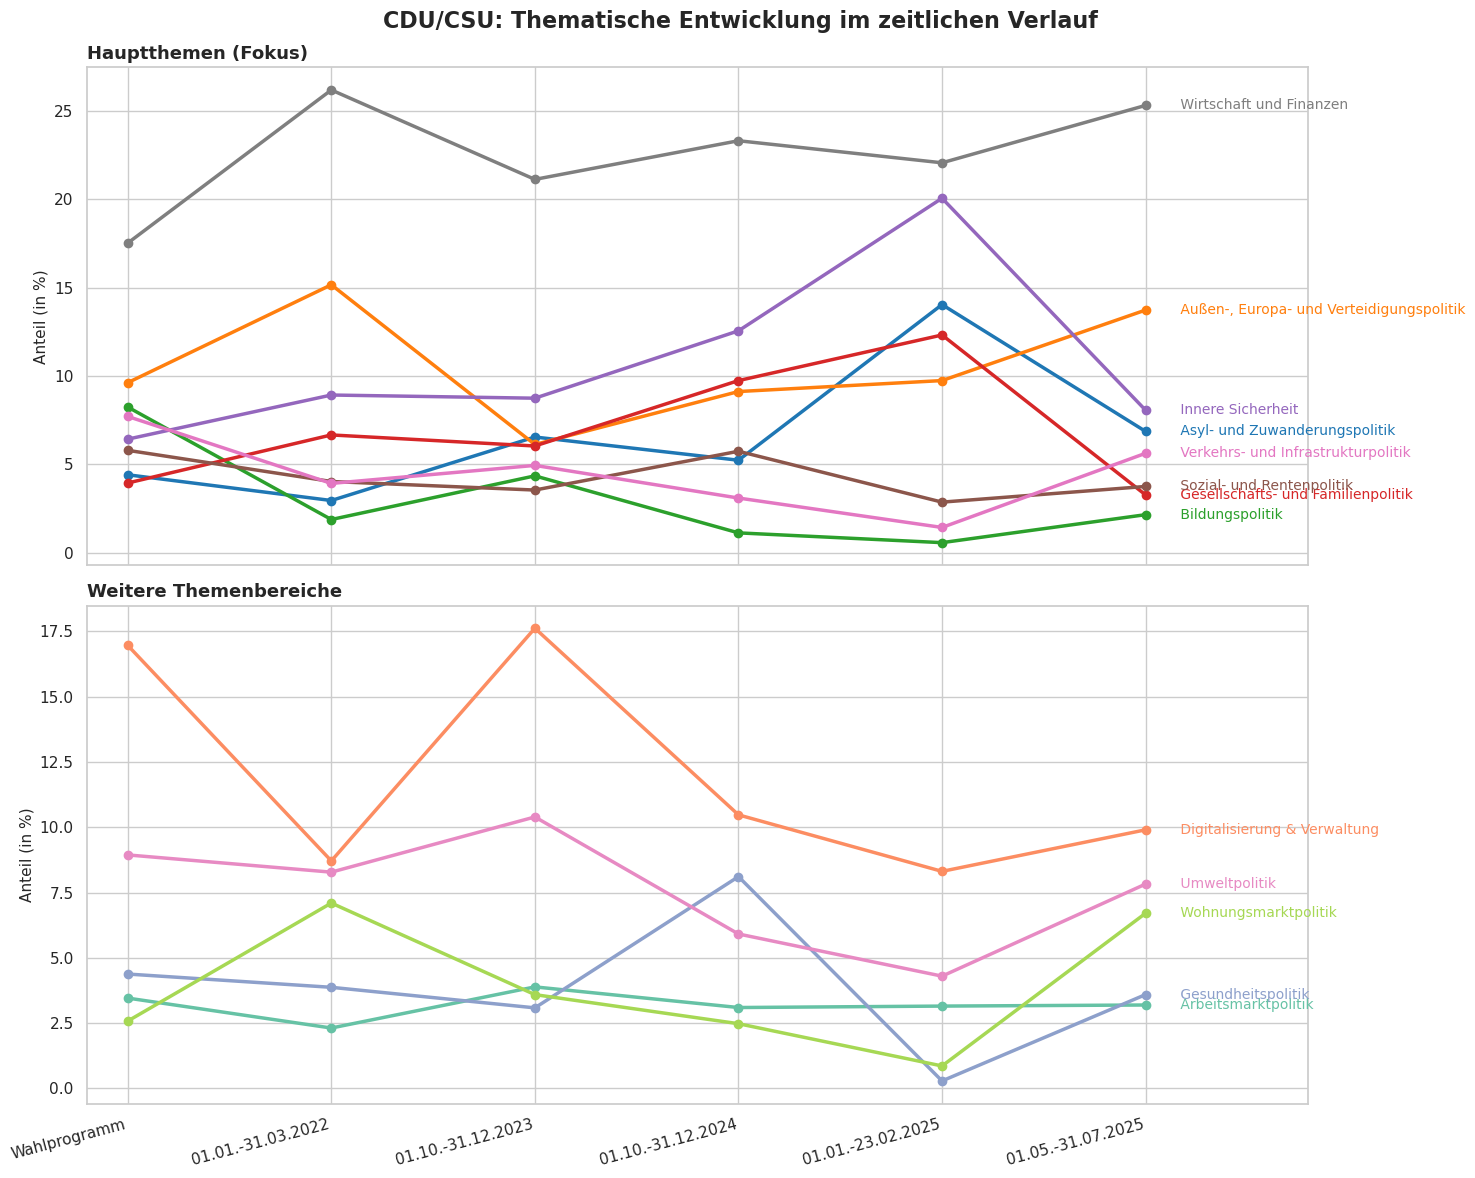

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Daten gezielt für die CDU/CSU filtern
cdu_data = distribution[distribution["partei"] == "CDU/CSU"].copy()

# 2. Chronologische Reihenfolge der Zeiträume definieren (von links nach rechts)
# Falls du noch weitere Zeiträume dazwischen hast, füge sie einfach in dieser Liste ein.
zeitreihenfolge = [
    "Wahlprogramm",  # Ganz links
    "01.01.-31.03.2022",
    "01.10.-31.12.2023",
    "01.10.-31.12.2024",
    "01.01.-23.02.2025",
    "01.05.-31.07.2025"
]

# 3. Nur die definierten Zeiträume im Plot berücksichtigen
cdu_data = cdu_data[cdu_data["zeitraum_name"].isin(zeitreihenfolge)]

# 4. Daten in eine Pivot-Tabelle umformen (Themen als Zeilen, Zeiträume als Spalten)
plot_df = cdu_data.pivot(
    index="topic", 
    columns="zeitraum_name", 
    values="anteil"
).fillna(0)

# Strikte chronologische Sortierung der Spalten erzwingen
plot_df = plot_df[zeitreihenfolge]

# ============================================================
# Grafik mit Matplotlib und Seaborn erstellen (Aufgeteilt in 2 Subplots)
# ============================================================
sns.set_theme(style="whitegrid")

# Definiere die Themen für die obere Hälfte
top_themen = [
    "Innere Sicherheit", 
    "Wirtschaft und Finanzen",
    "Asyl- und Zuwanderungspolitik", 
    "Außen-, Europa- und Verteidigungspolitik",
    "Sozial- und Rentenpolitik",
    "Bildungspolitik",
    "Gesellschafts- und Familienpolitik",
    "Verkehrs- und Infrastrukturpolitik"
]

# Datenrahmen in obere und untere Gruppe splitten
plot_df_top = plot_df[plot_df.index.isin(top_themen)]
plot_df_bottom = plot_df[~plot_df.index.isin(top_themen)]

# 2 Zeilen (übereinander), 1 Spalte erzeugen. sharex=True teilt die X-Achse.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
x_points = range(len(zeitreihenfolge))

# ------------------------------------------------------------
# 1. Obere Hälfte (Spezifische Kategorien)
# ------------------------------------------------------------
colors_top = sns.color_palette("tab10", len(plot_df_top))
for idx, (thema, reihe) in enumerate(plot_df_top.iterrows()):
    y_values = reihe.values
    ax1.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_top[idx])
    
    # Text-Label rechts
    ax1.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}", # ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_top[idx], va='center', fontweight='medium'
    )
ax1.set_title("Hauptthemen (Fokus)", fontsize=13, fontweight="bold", loc="left")
ax1.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# 2. Untere Hälfte (Der Rest)
# ------------------------------------------------------------
colors_bottom = sns.color_palette("Set2", len(plot_df_bottom)) # Andere Palette zur Unterscheidung
for idx, (thema, reihe) in enumerate(plot_df_bottom.iterrows()):
    y_values = reihe.values
    ax2.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_bottom[idx])
    
    # Text-Label rechts
    ax2.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}",  #  ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_bottom[idx], va='center', fontweight='medium'
    )
ax2.set_title("Weitere Themenbereiche", fontsize=13, fontweight="bold", loc="left")
ax2.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# Gemeinsames Styling und Achsen
# ------------------------------------------------------------
# Gesamttitel für das gesamte Plot-Fenster
fig.suptitle("CDU/CSU: Thematische Entwicklung im zeitlichen Verlauf", fontsize=16, fontweight="bold", y=0.98)

# X-Achsen-Beschriftung setzen (nur auf dem unteren Plot nötig wegen sharex=True)
ax2.set_xticks(x_points)
ax2.set_xticklabels(zeitreihenfolge, rotation=15, ha="right", fontsize=11)

# Rechten Rand auf beiden Plots erweitern für die Labels
ax1.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)
ax2.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)

plt.tight_layout()
plt.savefig('cdu_themen_verlauf_hard.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [56]:
cdu_data

,partei,zeitraum_name,topic,anteil
77,CDU/CSU,01.01.-23.02.2025,Arbeitsmarktpolitik,3.151862
78,CDU/CSU,01.01.-23.02.2025,Asyl- und Zuwanderungspolitik,14.040115
79,CDU/CSU,01.01.-23.02.2025,"Außen-, Europa- und Verteidigungspolitik",9.742120
80,CDU/CSU,01.01.-23.02.2025,Bildungspolitik,0.573066
81,CDU/CSU,01.01.-23.02.2025,Digitalisierung & Verwaltung,8.309456
...,...,...,...,...
150,CDU/CSU,Wahlprogramm,Sozial- und Rentenpolitik,5.795231
151,CDU/CSU,Wahlprogramm,Umweltpolitik,8.939126
152,CDU/CSU,Wahlprogramm,Verkehrs- und Infrastrukturpolitik,7.712820
153,CDU/CSU,Wahlprogramm,Wirtschaft und Finanzen,17.519872


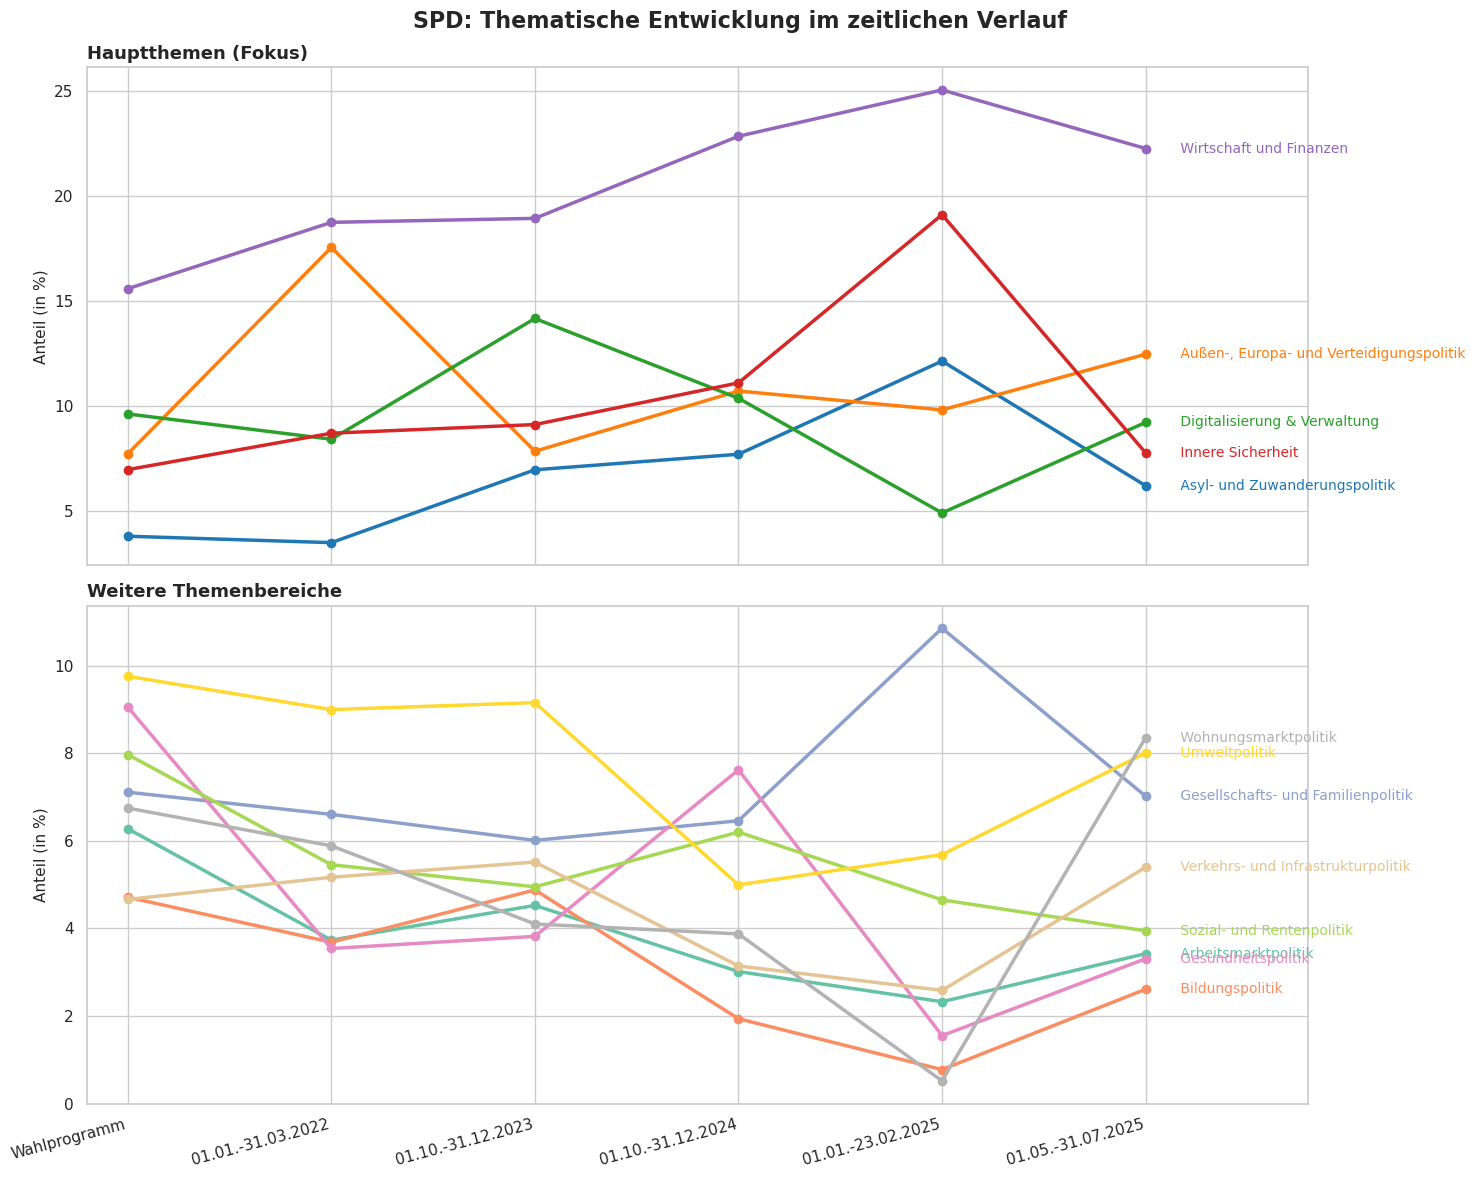

In [57]:
# 1. Daten gezielt für die CDU/CSU filtern
spd_data = distribution[distribution["partei"] == "SPD"].copy()

# 2. Chronologische Reihenfolge der Zeiträume definieren (von links nach rechts)
# Falls du noch weitere Zeiträume dazwischen hast, füge sie einfach in dieser Liste ein.
zeitreihenfolge = [
    "Wahlprogramm",  # Ganz links
    "01.01.-31.03.2022",
    "01.10.-31.12.2023",
    "01.10.-31.12.2024",
    "01.01.-23.02.2025",
    "01.05.-31.07.2025"
]

# 3. Nur die definierten Zeiträume im Plot berücksichtigen
spd_data = spd_data[spd_data["zeitraum_name"].isin(zeitreihenfolge)]

# 4. Daten in eine Pivot-Tabelle umformen (Themen als Zeilen, Zeiträume als Spalten)
plot_df = spd_data.pivot(
    index="topic", 
    columns="zeitraum_name", 
    values="anteil"
).fillna(0)

# Strikte chronologische Sortierung der Spalten erzwingen
plot_df = plot_df[zeitreihenfolge]

# ============================================================
# Grafik mit Matplotlib und Seaborn erstellen (Aufgeteilt in 2 Subplots)
# ============================================================
sns.set_theme(style="whitegrid")

# Definiere die Themen für die obere Hälfte
top_themen = [
    "Innere Sicherheit", 
    "Wirtschaft und Finanzen",
    "Asyl- und Zuwanderungspolitik", 
    "Digitalisierung & Verwaltung",
    "Außen-, Europa- und Verteidigungspolitik",
]

# Datenrahmen in obere und untere Gruppe splitten
plot_df_top = plot_df[plot_df.index.isin(top_themen)]
plot_df_bottom = plot_df[~plot_df.index.isin(top_themen)]

# 2 Zeilen (übereinander), 1 Spalte erzeugen. sharex=True teilt die X-Achse.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
x_points = range(len(zeitreihenfolge))

# ------------------------------------------------------------
# 1. Obere Hälfte (Spezifische Kategorien)
# ------------------------------------------------------------
colors_top = sns.color_palette("tab10", len(plot_df_top))
for idx, (thema, reihe) in enumerate(plot_df_top.iterrows()):
    y_values = reihe.values
    ax1.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_top[idx])
    
    # Text-Label rechts
    ax1.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}", # ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_top[idx], va='center', fontweight='medium'
    )
ax1.set_title("Hauptthemen (Fokus)", fontsize=13, fontweight="bold", loc="left")
ax1.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# 2. Untere Hälfte (Der Rest)
# ------------------------------------------------------------
colors_bottom = sns.color_palette("Set2", len(plot_df_bottom)) # Andere Palette zur Unterscheidung
for idx, (thema, reihe) in enumerate(plot_df_bottom.iterrows()):
    y_values = reihe.values
    ax2.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_bottom[idx])
    
    # Text-Label rechts
    ax2.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}",  #  ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_bottom[idx], va='center', fontweight='medium'
    )
ax2.set_title("Weitere Themenbereiche", fontsize=13, fontweight="bold", loc="left")
ax2.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# Gemeinsames Styling und Achsen
# ------------------------------------------------------------
# Gesamttitel für das gesamte Plot-Fenster
fig.suptitle("SPD: Thematische Entwicklung im zeitlichen Verlauf", fontsize=16, fontweight="bold", y=0.98)

# X-Achsen-Beschriftung setzen (nur auf dem unteren Plot nötig wegen sharex=True)
ax2.set_xticks(x_points)
ax2.set_xticklabels(zeitreihenfolge, rotation=15, ha="right", fontsize=11)

# Rechten Rand auf beiden Plots erweitern für die Labels
ax1.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)
ax2.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)

plt.tight_layout()
plt.savefig('spd_themen_verlauf_hard.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [58]:
spd_data

,partei,zeitraum_name,topic,anteil
371,SPD,01.01.-23.02.2025,Arbeitsmarktpolitik,2.325581
372,SPD,01.01.-23.02.2025,Asyl- und Zuwanderungspolitik,12.144703
373,SPD,01.01.-23.02.2025,"Außen-, Europa- und Verteidigungspolitik",9.819121
374,SPD,01.01.-23.02.2025,Bildungspolitik,0.775194
375,SPD,01.01.-23.02.2025,Digitalisierung & Verwaltung,4.909561
...,...,...,...,...
444,SPD,Wahlprogramm,Sozial- und Rentenpolitik,7.970014
445,SPD,Wahlprogramm,Umweltpolitik,9.756164
446,SPD,Wahlprogramm,Verkehrs- und Infrastrukturpolitik,4.660226
447,SPD,Wahlprogramm,Wirtschaft und Finanzen,15.593624


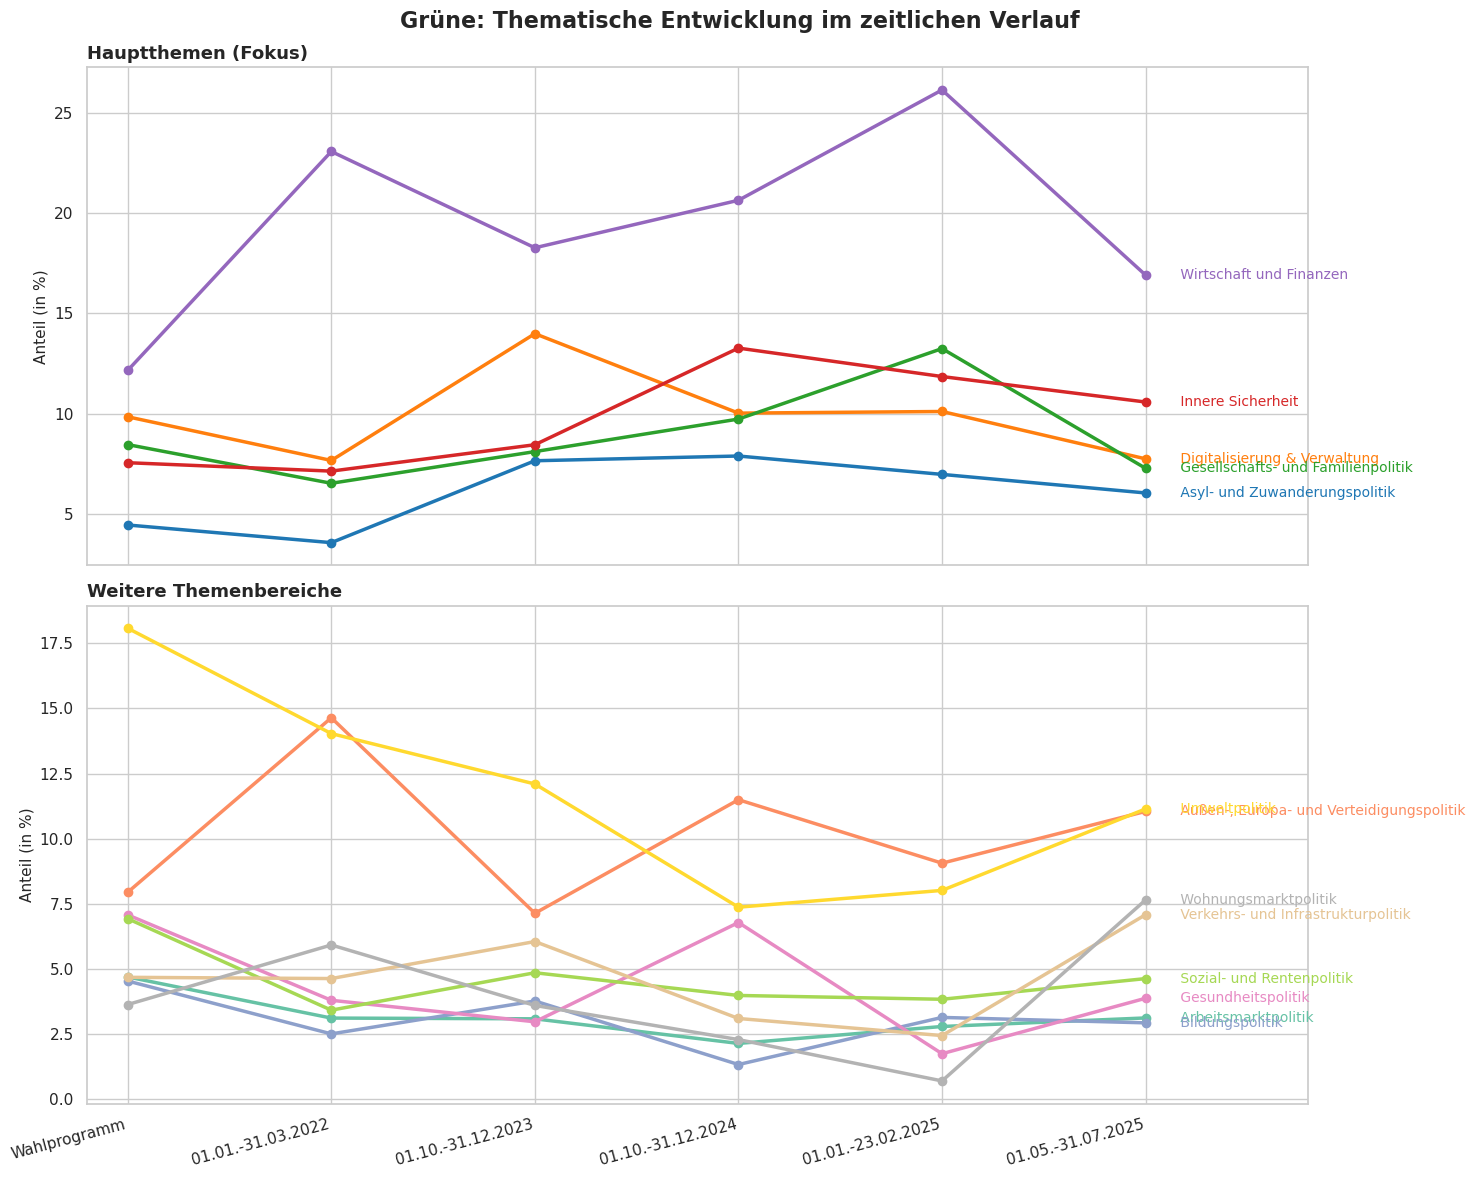

In [59]:
# 1. Daten gezielt für die Grüne filtern
grüne_data = distribution[distribution["partei"] == "Grüne"].copy()

# 2. Chronologische Reihenfolge der Zeiträume definieren (von links nach rechts)
# Falls du noch weitere Zeiträume dazwischen hast, füge sie einfach in dieser Liste ein.
zeitreihenfolge = [
    "Wahlprogramm",  # Ganz links
    "01.01.-31.03.2022",
    "01.10.-31.12.2023",
    "01.10.-31.12.2024",
    "01.01.-23.02.2025",
    "01.05.-31.07.2025"
]

# 3. Nur die definierten Zeiträume im Plot berücksichtigen
grüne_data = grüne_data[grüne_data["zeitraum_name"].isin(zeitreihenfolge)]

# 4. Daten in eine Pivot-Tabelle umformen (Themen als Zeilen, Zeiträume als Spalten)
plot_df = grüne_data.pivot(
    index="topic", 
    columns="zeitraum_name", 
    values="anteil"
).fillna(0)

# Strikte chronologische Sortierung der Spalten erzwingen
plot_df = plot_df[zeitreihenfolge]

# ============================================================
# Grafik mit Matplotlib und Seaborn erstellen (Aufgeteilt in 2 Subplots)
# ============================================================
sns.set_theme(style="whitegrid")

# Definiere die Themen für die obere Hälfte
top_themen = [
    "Innere Sicherheit", 
    "Wirtschaft und Finanzen",
    "Asyl- und Zuwanderungspolitik", 
    "Digitalisierung & Verwaltung",
    "Gesellschafts- und Familienpolitik"
]

# Datenrahmen in obere und untere Gruppe splitten
plot_df_top = plot_df[plot_df.index.isin(top_themen)]
plot_df_bottom = plot_df[~plot_df.index.isin(top_themen)]

# 2 Zeilen (übereinander), 1 Spalte erzeugen. sharex=True teilt die X-Achse.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
x_points = range(len(zeitreihenfolge))

# ------------------------------------------------------------
# 1. Obere Hälfte (Spezifische Kategorien)
# ------------------------------------------------------------
colors_top = sns.color_palette("tab10", len(plot_df_top))
for idx, (thema, reihe) in enumerate(plot_df_top.iterrows()):
    y_values = reihe.values
    ax1.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_top[idx])
    
    # Text-Label rechts
    ax1.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}", # ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_top[idx], va='center', fontweight='medium'
    )
ax1.set_title("Hauptthemen (Fokus)", fontsize=13, fontweight="bold", loc="left")
ax1.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# 2. Untere Hälfte (Der Rest)
# ------------------------------------------------------------
colors_bottom = sns.color_palette("Set2", len(plot_df_bottom)) # Andere Palette zur Unterscheidung
for idx, (thema, reihe) in enumerate(plot_df_bottom.iterrows()):
    y_values = reihe.values
    ax2.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_bottom[idx])
    
    # Text-Label rechts
    ax2.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}",  #  ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_bottom[idx], va='center', fontweight='medium'
    )
ax2.set_title("Weitere Themenbereiche", fontsize=13, fontweight="bold", loc="left")
ax2.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# Gemeinsames Styling und Achsen
# ------------------------------------------------------------
# Gesamttitel für das gesamte Plot-Fenster
fig.suptitle("Grüne: Thematische Entwicklung im zeitlichen Verlauf", fontsize=16, fontweight="bold", y=0.98)

# X-Achsen-Beschriftung setzen (nur auf dem unteren Plot nötig wegen sharex=True)
ax2.set_xticks(x_points)
ax2.set_xticklabels(zeitreihenfolge, rotation=15, ha="right", fontsize=11)

# Rechten Rand auf beiden Plots erweitern für die Labels
ax1.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)
ax2.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)

plt.tight_layout()
plt.savefig('Grüne_themen_verlauf_hard.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [60]:
grüne_data

,partei,zeitraum_name,topic,anteil
218,Grüne,01.01.-23.02.2025,Arbeitsmarktpolitik,2.787456
219,Grüne,01.01.-23.02.2025,Asyl- und Zuwanderungspolitik,6.968641
220,Grüne,01.01.-23.02.2025,"Außen-, Europa- und Verteidigungspolitik",9.059233
221,Grüne,01.01.-23.02.2025,Bildungspolitik,3.135889
222,Grüne,01.01.-23.02.2025,Digitalisierung & Verwaltung,10.104530
...,...,...,...,...
291,Grüne,Wahlprogramm,Sozial- und Rentenpolitik,6.927057
292,Grüne,Wahlprogramm,Umweltpolitik,18.081289
293,Grüne,Wahlprogramm,Verkehrs- und Infrastrukturpolitik,4.675764
294,Grüne,Wahlprogramm,Wirtschaft und Finanzen,12.153647


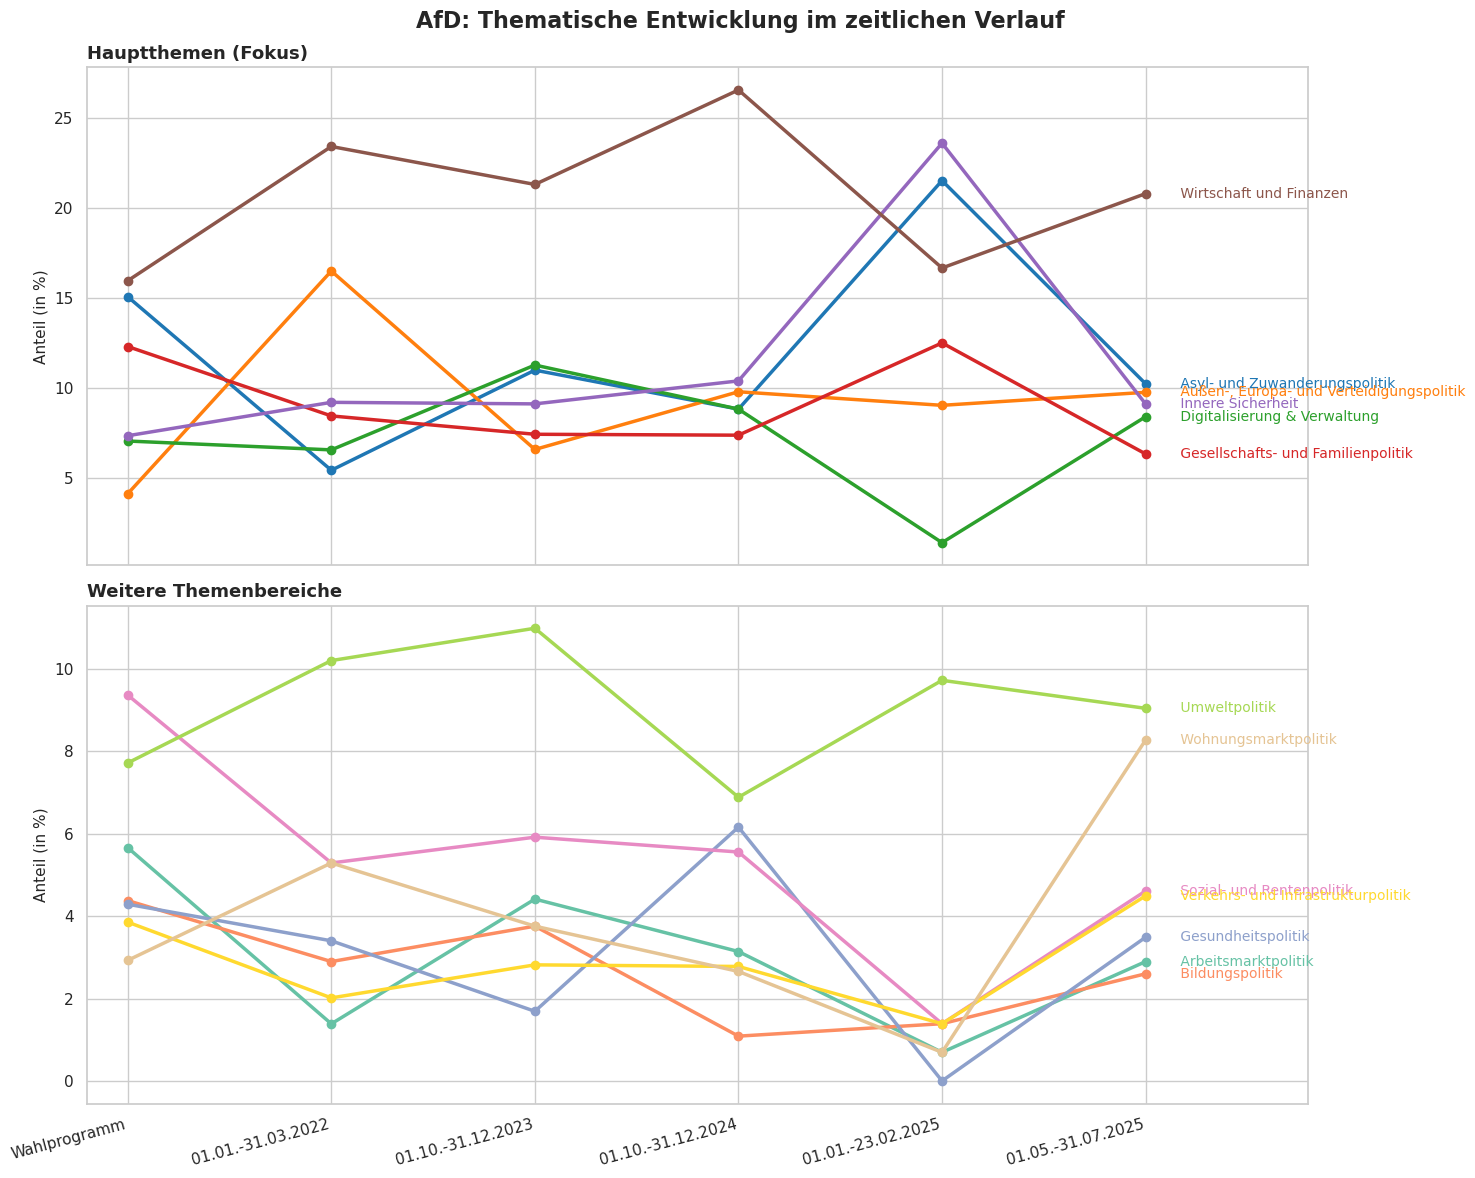

In [61]:
# 1. Daten gezielt für die AfD filtern
afd_data = distribution[distribution["partei"] == "AfD"].copy()

# 2. Chronologische Reihenfolge der Zeiträume definieren (von links nach rechts)
# Falls du noch weitere Zeiträume dazwischen hast, füge sie einfach in dieser Liste ein.
zeitreihenfolge = [
    "Wahlprogramm",  # Ganz links
    "01.01.-31.03.2022",
    "01.10.-31.12.2023",
    "01.10.-31.12.2024",
    "01.01.-23.02.2025",
    "01.05.-31.07.2025"
]

# 3. Nur die definierten Zeiträume im Plot berücksichtigen
afd_data = afd_data[afd_data["zeitraum_name"].isin(zeitreihenfolge)]

# 4. Daten in eine Pivot-Tabelle umformen (Themen als Zeilen, Zeiträume als Spalten)
plot_df = afd_data.pivot(
    index="topic", 
    columns="zeitraum_name", 
    values="anteil"
).fillna(0)

# Strikte chronologische Sortierung der Spalten erzwingen
plot_df = plot_df[zeitreihenfolge]

# ============================================================
# Grafik mit Matplotlib und Seaborn erstellen (Aufgeteilt in 2 Subplots)
# ============================================================
sns.set_theme(style="whitegrid")

# Definiere die Themen für die obere Hälfte
top_themen = [
    "Innere Sicherheit", 
    "Wirtschaft und Finanzen",
    "Asyl- und Zuwanderungspolitik", 
    "Digitalisierung & Verwaltung",
    "Außen-, Europa- und Verteidigungspolitik",
    "Gesellschafts- und Familienpolitik"
]

# Datenrahmen in obere und untere Gruppe splitten
plot_df_top = plot_df[plot_df.index.isin(top_themen)]
plot_df_bottom = plot_df[~plot_df.index.isin(top_themen)]

# 2 Zeilen (übereinander), 1 Spalte erzeugen. sharex=True teilt die X-Achse.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
x_points = range(len(zeitreihenfolge))

# ------------------------------------------------------------
# 1. Obere Hälfte (Spezifische Kategorien)
# ------------------------------------------------------------
colors_top = sns.color_palette("tab10", len(plot_df_top))
for idx, (thema, reihe) in enumerate(plot_df_top.iterrows()):
    y_values = reihe.values
    ax1.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_top[idx])
    
    # Text-Label rechts
    ax1.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}", # ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_top[idx], va='center', fontweight='medium'
    )
ax1.set_title("Hauptthemen (Fokus)", fontsize=13, fontweight="bold", loc="left")
ax1.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# 2. Untere Hälfte (Der Rest)
# ------------------------------------------------------------
colors_bottom = sns.color_palette("Set2", len(plot_df_bottom)) # Andere Palette zur Unterscheidung
for idx, (thema, reihe) in enumerate(plot_df_bottom.iterrows()):
    y_values = reihe.values
    ax2.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_bottom[idx])
    
    # Text-Label rechts
    ax2.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}",  #  ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_bottom[idx], va='center', fontweight='medium'
    )
ax2.set_title("Weitere Themenbereiche", fontsize=13, fontweight="bold", loc="left")
ax2.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# Gemeinsames Styling und Achsen
# ------------------------------------------------------------
# Gesamttitel für das gesamte Plot-Fenster
fig.suptitle("AfD: Thematische Entwicklung im zeitlichen Verlauf", fontsize=16, fontweight="bold", y=0.98)

# X-Achsen-Beschriftung setzen (nur auf dem unteren Plot nötig wegen sharex=True)
ax2.set_xticks(x_points)
ax2.set_xticklabels(zeitreihenfolge, rotation=15, ha="right", fontsize=11)

# Rechten Rand auf beiden Plots erweitern für die Labels
ax1.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)
ax2.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)

plt.tight_layout()
plt.savefig('AfD_themen_verlauf_hard.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [62]:
afd_data

,partei,zeitraum_name,topic,anteil
0,AfD,01.01.-23.02.2025,Arbeitsmarktpolitik,0.694444
1,AfD,01.01.-23.02.2025,Asyl- und Zuwanderungspolitik,21.527778
2,AfD,01.01.-23.02.2025,"Außen-, Europa- und Verteidigungspolitik",9.027778
3,AfD,01.01.-23.02.2025,Bildungspolitik,1.388889
4,AfD,01.01.-23.02.2025,Digitalisierung & Verwaltung,1.388889
...,...,...,...,...
72,AfD,Wahlprogramm,Sozial- und Rentenpolitik,9.364302
73,AfD,Wahlprogramm,Umweltpolitik,7.717083
74,AfD,Wahlprogramm,Verkehrs- und Infrastrukturpolitik,3.853940
75,AfD,Wahlprogramm,Wirtschaft und Finanzen,15.958700


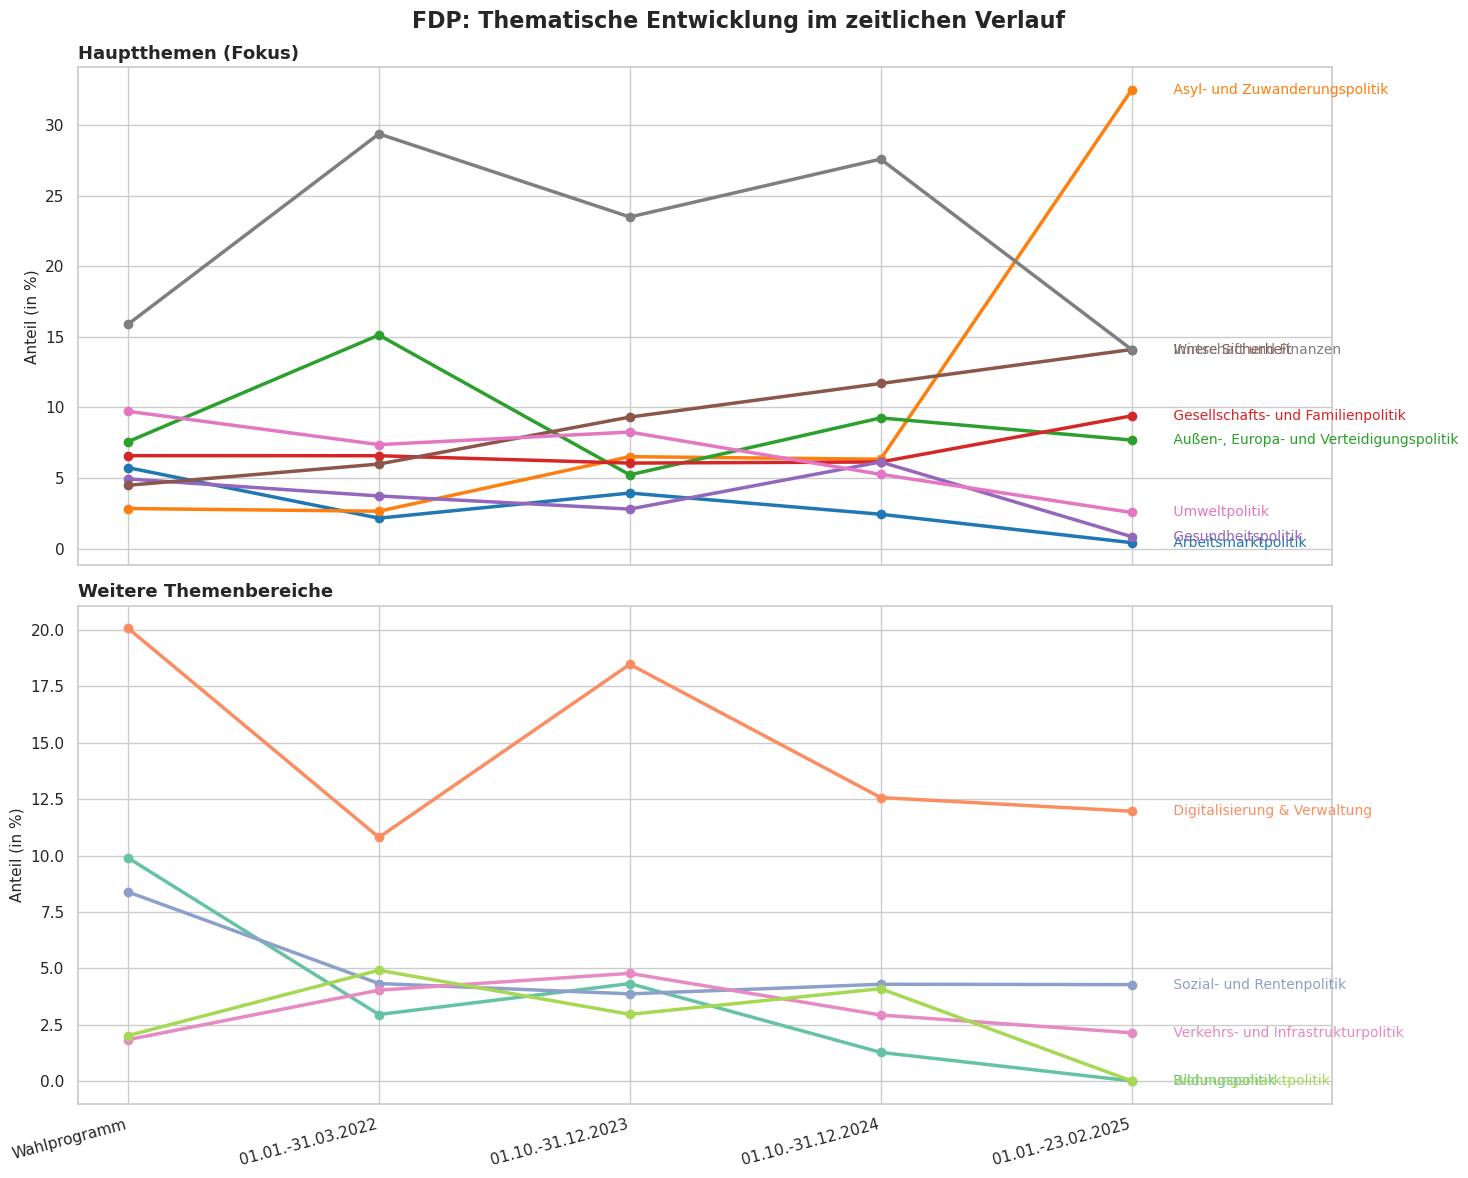

In [63]:
# 1. Daten gezielt für die FDP filtern
fdp_data = distribution[distribution["partei"] == "FDP"].copy()

# 2. Chronologische Reihenfolge der Zeiträume definieren (von links nach rechts)
# Falls du noch weitere Zeiträume dazwischen hast, füge sie einfach in dieser Liste ein.
zeitreihenfolge = [
    "Wahlprogramm",  # Ganz links
    "01.01.-31.03.2022",
    "01.10.-31.12.2023",
    "01.10.-31.12.2024",
    "01.01.-23.02.2025"
]

# 3. Nur die definierten Zeiträume im Plot berücksichtigen
fdp_data = fdp_data[fdp_data["zeitraum_name"].isin(zeitreihenfolge)]

# 4. Daten in eine Pivot-Tabelle umformen (Themen als Zeilen, Zeiträume als Spalten)
plot_df = fdp_data.pivot(
    index="topic", 
    columns="zeitraum_name", 
    values="anteil"
).fillna(0)

# Strikte chronologische Sortierung der Spalten erzwingen
plot_df = plot_df[zeitreihenfolge]

# ============================================================
# Grafik mit Matplotlib und Seaborn erstellen (Aufgeteilt in 2 Subplots)
# ============================================================
sns.set_theme(style="whitegrid")

# Definiere die Themen für die obere Hälfte
top_themen = [
    "Innere Sicherheit", 
    "Wirtschaft und Finanzen",
    "Asyl- und Zuwanderungspolitik", 
    "Arbeitsmarktpolitik",
    "Gesundheitspolitik",
    "Umweltpolitik",
    "Außen-, Europa- und Verteidigungspolitik",
    "Gesellschafts- und Familienpolitik"
]

# Datenrahmen in obere und untere Gruppe splitten
plot_df_top = plot_df[plot_df.index.isin(top_themen)]
plot_df_bottom = plot_df[~plot_df.index.isin(top_themen)]

# 2 Zeilen (übereinander), 1 Spalte erzeugen. sharex=True teilt die X-Achse.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
x_points = range(len(zeitreihenfolge))

# ------------------------------------------------------------
# 1. Obere Hälfte (Spezifische Kategorien)
# ------------------------------------------------------------
colors_top = sns.color_palette("tab10", len(plot_df_top))
for idx, (thema, reihe) in enumerate(plot_df_top.iterrows()):
    y_values = reihe.values
    ax1.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_top[idx])
    
    # Text-Label rechts
    ax1.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}", # ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_top[idx], va='center', fontweight='medium'
    )
ax1.set_title("Hauptthemen (Fokus)", fontsize=13, fontweight="bold", loc="left")
ax1.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# 2. Untere Hälfte (Der Rest)
# ------------------------------------------------------------
colors_bottom = sns.color_palette("Set2", len(plot_df_bottom)) # Andere Palette zur Unterscheidung
for idx, (thema, reihe) in enumerate(plot_df_bottom.iterrows()):
    y_values = reihe.values
    ax2.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_bottom[idx])
    
    # Text-Label rechts
    ax2.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}",  #  ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_bottom[idx], va='center', fontweight='medium'
    )
ax2.set_title("Weitere Themenbereiche", fontsize=13, fontweight="bold", loc="left")
ax2.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# Gemeinsames Styling und Achsen
# ------------------------------------------------------------
# Gesamttitel für das gesamte Plot-Fenster
fig.suptitle("FDP: Thematische Entwicklung im zeitlichen Verlauf", fontsize=16, fontweight="bold", y=0.98)

# X-Achsen-Beschriftung setzen (nur auf dem unteren Plot nötig wegen sharex=True)
ax2.set_xticks(x_points)
ax2.set_xticklabels(zeitreihenfolge, rotation=15, ha="right", fontsize=11)

# Rechten Rand auf beiden Plots erweitern für die Labels
ax1.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)
ax2.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)

plt.tight_layout()
plt.savefig('FDP_themen_verlauf_hard.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [64]:
fdp_data

,partei,zeitraum_name,topic,anteil
155,FDP,01.01.-23.02.2025,Arbeitsmarktpolitik,0.427350
156,FDP,01.01.-23.02.2025,Asyl- und Zuwanderungspolitik,32.478632
157,FDP,01.01.-23.02.2025,"Außen-, Europa- und Verteidigungspolitik",7.692308
158,FDP,01.01.-23.02.2025,Digitalisierung & Verwaltung,11.965812
159,FDP,01.01.-23.02.2025,Gesellschafts- und Familienpolitik,9.401709
...,...,...,...,...
213,FDP,Wahlprogramm,Sozial- und Rentenpolitik,8.384378
214,FDP,Wahlprogramm,Umweltpolitik,9.727452
215,FDP,Wahlprogramm,Verkehrs- und Infrastrukturpolitik,1.831975
216,FDP,Wahlprogramm,Wirtschaft und Finanzen,15.892105


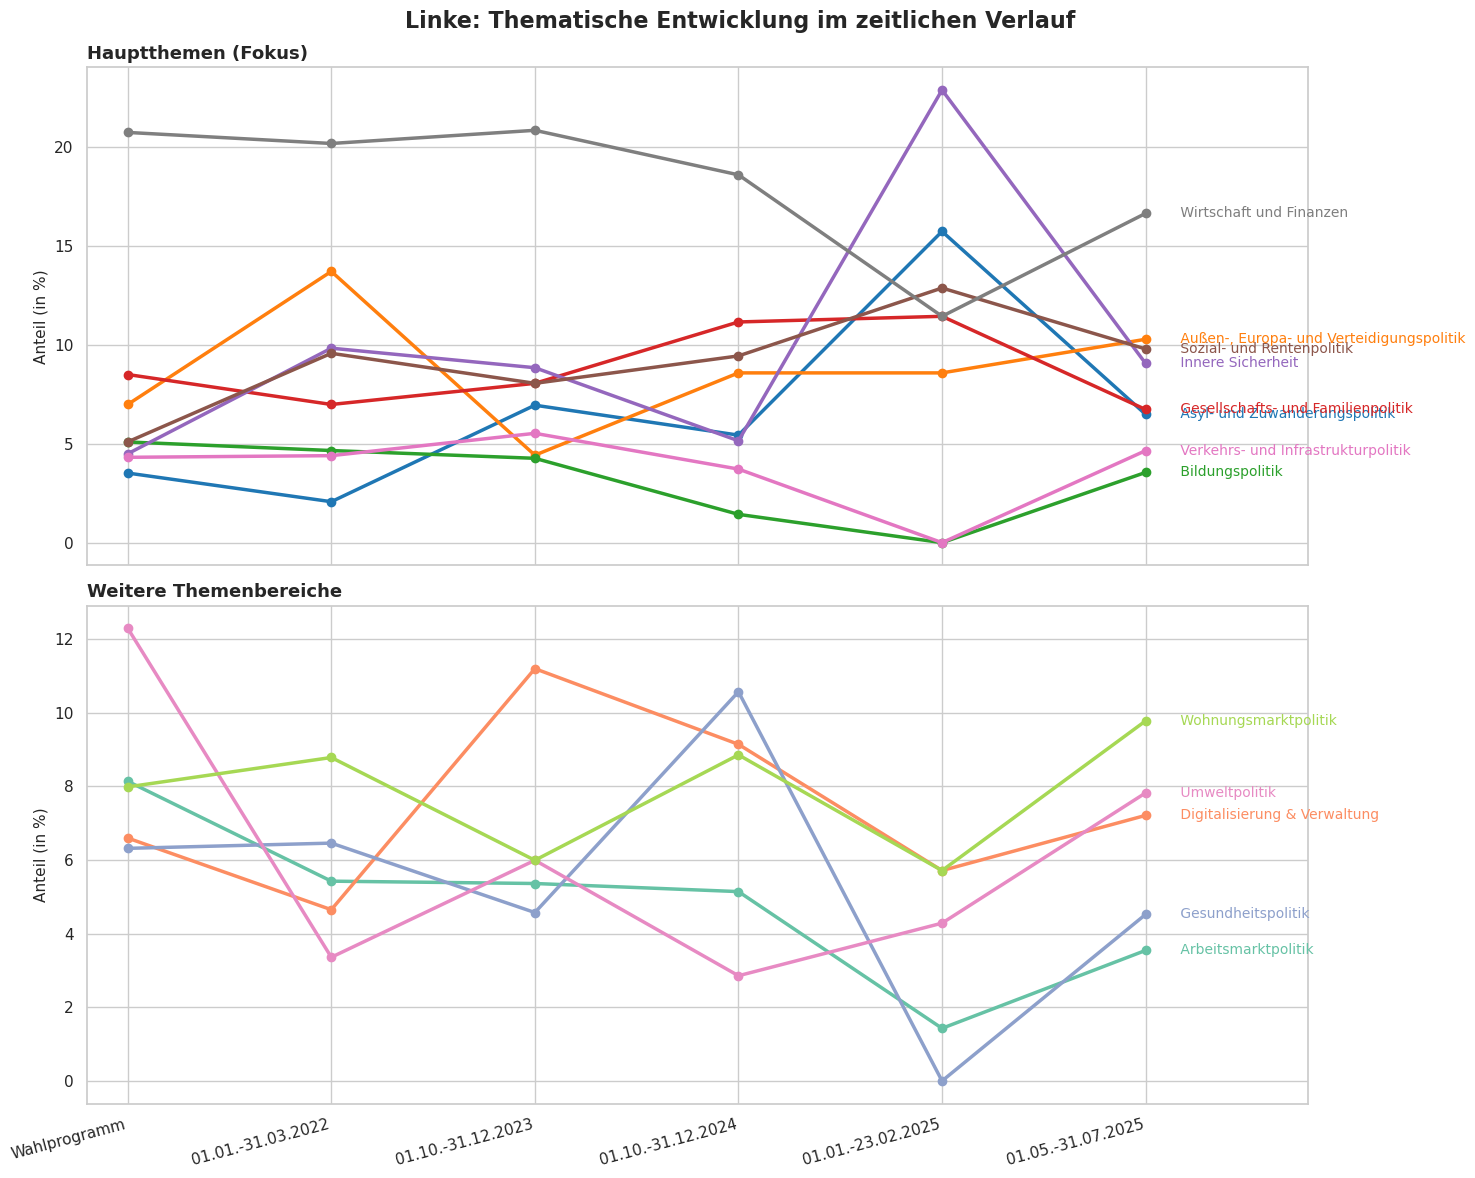

In [65]:
linke_data = distribution[distribution["partei"] == "Linke"].copy()

# 2. Chronologische Reihenfolge der Zeiträume definieren (von links nach rechts)
# Falls du noch weitere Zeiträume dazwischen hast, füge sie einfach in dieser Liste ein.
zeitreihenfolge = [
    "Wahlprogramm",  # Ganz links
    "01.01.-31.03.2022",
    "01.10.-31.12.2023",
    "01.10.-31.12.2024",
    "01.01.-23.02.2025",
    "01.05.-31.07.2025"
]

# 3. Nur die definierten Zeiträume im Plot berücksichtigen
linke_data = linke_data[linke_data["zeitraum_name"].isin(zeitreihenfolge)]

# 4. Daten in eine Pivot-Tabelle umformen (Themen als Zeilen, Zeiträume als Spalten)
plot_df = linke_data.pivot(
    index="topic", 
    columns="zeitraum_name", 
    values="anteil"
).fillna(0)

# Strikte chronologische Sortierung der Spalten erzwingen
plot_df = plot_df[zeitreihenfolge]

# ============================================================
# Grafik mit Matplotlib und Seaborn erstellen (Aufgeteilt in 2 Subplots)
# ============================================================
sns.set_theme(style="whitegrid")

# Definiere die Themen für die obere Hälfte
top_themen = [
    "Innere Sicherheit", 
    "Wirtschaft und Finanzen",
    "Asyl- und Zuwanderungspolitik", 
    "Außen-, Europa- und Verteidigungspolitik",
    "Sozial- und Rentenpolitik",
    "Bildungspolitik",
    "Gesellschafts- und Familienpolitik",
    "Verkehrs- und Infrastrukturpolitik"
]

# Datenrahmen in obere und untere Gruppe splitten
plot_df_top = plot_df[plot_df.index.isin(top_themen)]
plot_df_bottom = plot_df[~plot_df.index.isin(top_themen)]

# 2 Zeilen (übereinander), 1 Spalte erzeugen. sharex=True teilt die X-Achse.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)
x_points = range(len(zeitreihenfolge))

# ------------------------------------------------------------
# 1. Obere Hälfte (Spezifische Kategorien)
# ------------------------------------------------------------
colors_top = sns.color_palette("tab10", len(plot_df_top))
for idx, (thema, reihe) in enumerate(plot_df_top.iterrows()):
    y_values = reihe.values
    ax1.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_top[idx])
    
    # Text-Label rechts
    ax1.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}", # ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_top[idx], va='center', fontweight='medium'
    )
ax1.set_title("Hauptthemen (Fokus)", fontsize=13, fontweight="bold", loc="left")
ax1.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# 2. Untere Hälfte (Der Rest)
# ------------------------------------------------------------
colors_bottom = sns.color_palette("Set2", len(plot_df_bottom)) # Andere Palette zur Unterscheidung
for idx, (thema, reihe) in enumerate(plot_df_bottom.iterrows()):
    y_values = reihe.values
    ax2.plot(x_points, y_values, marker='o', linewidth=2.5, color=colors_bottom[idx])
    
    # Text-Label rechts
    ax2.text(
        len(zeitreihenfolge) - 0.85, 
        y_values[-1], 
        f" {thema}",  #  ({y_values[-1]:.1f}%)
        fontsize=10, color=colors_bottom[idx], va='center', fontweight='medium'
    )
ax2.set_title("Weitere Themenbereiche", fontsize=13, fontweight="bold", loc="left")
ax2.set_ylabel("Anteil (in %)", fontsize=11)

# ------------------------------------------------------------
# Gemeinsames Styling und Achsen
# ------------------------------------------------------------
# Gesamttitel für das gesamte Plot-Fenster
fig.suptitle("Linke: Thematische Entwicklung im zeitlichen Verlauf", fontsize=16, fontweight="bold", y=0.98)

# X-Achsen-Beschriftung setzen (nur auf dem unteren Plot nötig wegen sharex=True)
ax2.set_xticks(x_points)
ax2.set_xticklabels(zeitreihenfolge, rotation=15, ha="right", fontsize=11)

# Rechten Rand auf beiden Plots erweitern für die Labels
ax1.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)
ax2.set_xlim(-0.2, len(zeitreihenfolge) - 0.2)

plt.tight_layout()
plt.savefig('linke_themen_verlauf_hard.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [66]:
linke_data

,partei,zeitraum_name,topic,anteil
296,Linke,01.01.-23.02.2025,Arbeitsmarktpolitik,1.428571
297,Linke,01.01.-23.02.2025,Asyl- und Zuwanderungspolitik,15.714286
298,Linke,01.01.-23.02.2025,"Außen-, Europa- und Verteidigungspolitik",8.571429
299,Linke,01.01.-23.02.2025,Digitalisierung & Verwaltung,5.714286
300,Linke,01.01.-23.02.2025,Gesellschafts- und Familienpolitik,11.428571
...,...,...,...,...
366,Linke,Wahlprogramm,Sozial- und Rentenpolitik,5.087771
367,Linke,Wahlprogramm,Umweltpolitik,12.296274
368,Linke,Wahlprogramm,Verkehrs- und Infrastrukturpolitik,4.309233
369,Linke,Wahlprogramm,Wirtschaft und Finanzen,20.713081


In [67]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.patches as patches

# Zuordnung der Namen in exakt derselben Reihenfolge wie in Ihrer Liste
partei_namen = ['CDU/CSU', 'SPD', 'Linke', 'Grüne', 'AfD', 'FDP']

In [68]:
# Verläufe zum Thema "Außen-, Europa- und Verteidigungspolitik"

In [69]:
# Filtern der Zeilen nach dem gewünschten Topic
cdu_data_außen = cdu_data[cdu_data['topic'] == 'Außen-, Europa- und Verteidigungspolitik'].copy()
spd_data_außen = spd_data[spd_data['topic'] == 'Außen-, Europa- und Verteidigungspolitik'].copy()
linke_data_außen = linke_data[linke_data['topic'] == 'Außen-, Europa- und Verteidigungspolitik'].copy()
grüne_data_außen = grüne_data[grüne_data['topic'] == 'Außen-, Europa- und Verteidigungspolitik'].copy()
afd_data_außen = afd_data[afd_data['topic'] == 'Außen-, Europa- und Verteidigungspolitik'].copy()
fdp_data_außen = fdp_data[fdp_data['topic'] == 'Außen-, Europa- und Verteidigungspolitik'].copy()

In [70]:
cdu_data_außen

,partei,zeitraum_name,topic,anteil
79,CDU/CSU,01.01.-23.02.2025,"Außen-, Europa- und Verteidigungspolitik",9.742120
92,CDU/CSU,01.01.-31.03.2022,"Außen-, Europa- und Verteidigungspolitik",15.161290
105,CDU/CSU,01.05.-31.07.2025,"Außen-, Europa- und Verteidigungspolitik",13.732535
118,CDU/CSU,01.10.-31.12.2023,"Außen-, Europa- und Verteidigungspolitik",6.125898
131,CDU/CSU,01.10.-31.12.2024,"Außen-, Europa- und Verteidigungspolitik",9.121622
144,CDU/CSU,Wahlprogramm,"Außen-, Europa- und Verteidigungspolitik",9.623616


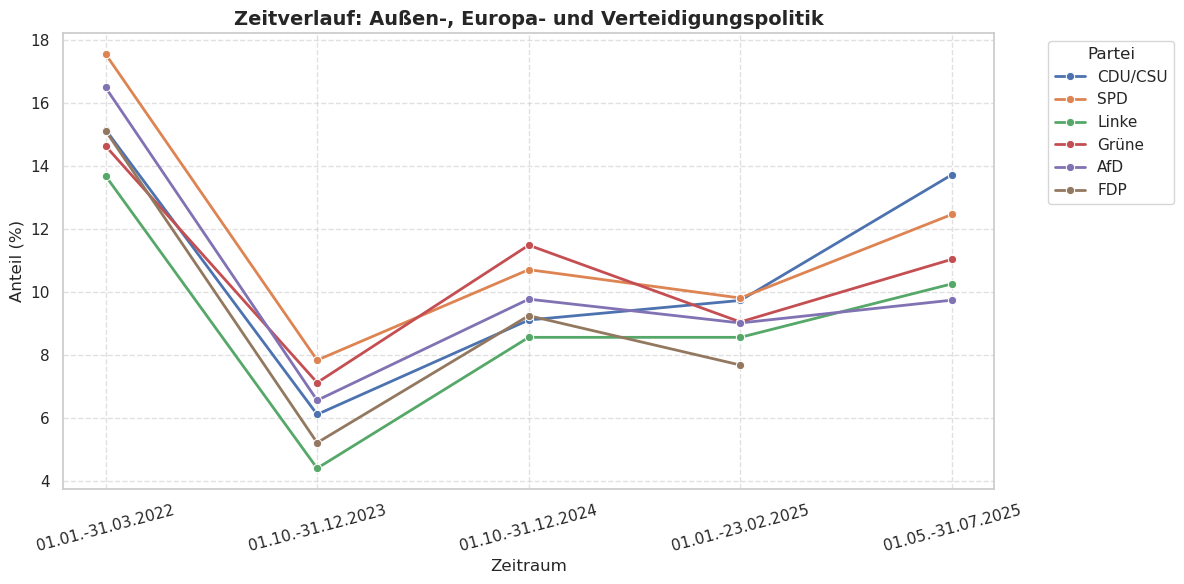

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Alle DataFrames in einer Liste sammeln und verknüpfen
dfs = [cdu_data_außen, spd_data_außen, linke_data_außen, grüne_data_außen, afd_data_außen, fdp_data_außen]
df_gesamt_außen = pd.concat(dfs, ignore_index=True)

# 2. Gewünschte Zeiträume in der exakten chronologischen Reihenfolge definieren
zeitreihenfolge = [
    "01.01.-31.03.2022",
    "01.10.-31.12.2023",
    "01.10.-31.12.2024",
    "01.01.-23.02.2025",
    "01.05.-31.07.2025"
]

# 3. Daten auf diese 5 Zeiträume filtern
df_gesamt_außen = df_gesamt_außen[df_gesamt_außen['zeitraum_name'].isin(zeitreihenfolge)].copy()

# 4. Zeitraum-Spalte als 'Kategorie' mit fester Reihenfolge definieren (wichtig für die X-Achse)
df_gesamt_außen['zeitraum_name'] = pd.Categorical(df_gesamt_außen['zeitraum_name'], categories=zeitreihenfolge, ordered=True)

# 5. Liniendiagramm erstellen
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_gesamt_außen, 
    x='zeitraum_name', 
    y='anteil', 
    hue='partei', 
    hue_order=partei_namen,  # Nutzt deine definierte Liste für die Legende
    marker='o',
    linewidth=2
)

# Diagramm-Styling
plt.title('Zeitverlauf: Außen-, Europa- und Verteidigungspolitik', fontsize=14, fontweight='bold')
plt.xlabel('Zeitraum', fontsize=12)
plt.ylabel('Anteil (%)', fontsize=12)
plt.xticks(rotation=15)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Partei', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()


In [72]:
# Verläufe zum Thema "Innere Sicherheit"

In [73]:
# Filtern der Zeilen nach dem gewünschten Topic
cdu_data_innen = cdu_data[cdu_data['topic'] == 'Innere Sicherheit'].copy()
spd_data_innen = spd_data[spd_data['topic'] == 'Innere Sicherheit'].copy()
linke_data_innen = linke_data[linke_data['topic'] == 'Innere Sicherheit'].copy()
grüne_data_innen = grüne_data[grüne_data['topic'] == 'Innere Sicherheit'].copy()
afd_data_innen = afd_data[afd_data['topic'] == 'Innere Sicherheit'].copy()
fdp_data_innen = fdp_data[fdp_data['topic'] == 'Innere Sicherheit'].copy()

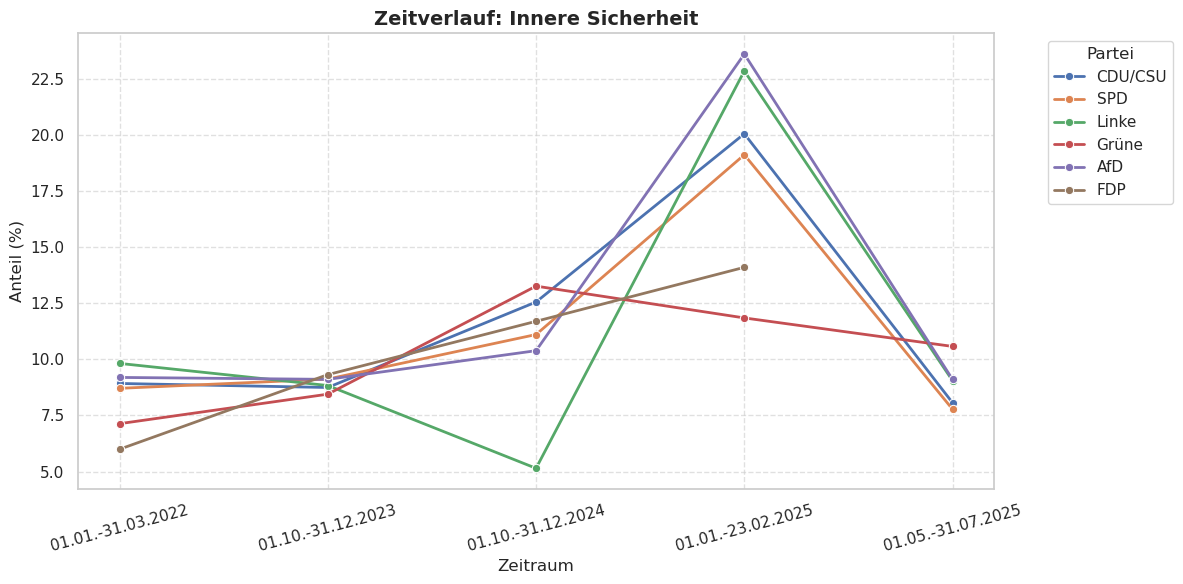

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Alle DataFrames in einer Liste sammeln und verknüpfen
dfs = [cdu_data_innen, spd_data_innen, linke_data_innen, grüne_data_innen, afd_data_innen, fdp_data_innen]
df_gesamt_innen = pd.concat(dfs, ignore_index=True)

# 2. Gewünschte Zeiträume in der exakten chronologischen Reihenfolge definieren
zeitreihenfolge = [
    "01.01.-31.03.2022",
    "01.10.-31.12.2023",
    "01.10.-31.12.2024",
    "01.01.-23.02.2025",
    "01.05.-31.07.2025"
]

# 3. Daten auf diese 5 Zeiträume filtern
df_gesamt_innen = df_gesamt_innen[df_gesamt_innen['zeitraum_name'].isin(zeitreihenfolge)].copy()

# 4. Zeitraum-Spalte als 'Kategorie' mit fester Reihenfolge definieren (wichtig für die X-Achse)
df_gesamt_innen['zeitraum_name'] = pd.Categorical(df_gesamt_innen['zeitraum_name'], categories=zeitreihenfolge, ordered=True)

# 5. Liniendiagramm erstellen
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_gesamt_innen, 
    x='zeitraum_name', 
    y='anteil', 
    hue='partei', 
    hue_order=partei_namen,  # Nutzt deine definierte Liste für die Legende
    marker='o',
    linewidth=2
)

# Diagramm-Styling
plt.title('Zeitverlauf: Innere Sicherheit', fontsize=14, fontweight='bold')
plt.xlabel('Zeitraum', fontsize=12)
plt.ylabel('Anteil (%)', fontsize=12)
plt.xticks(rotation=15)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Partei', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

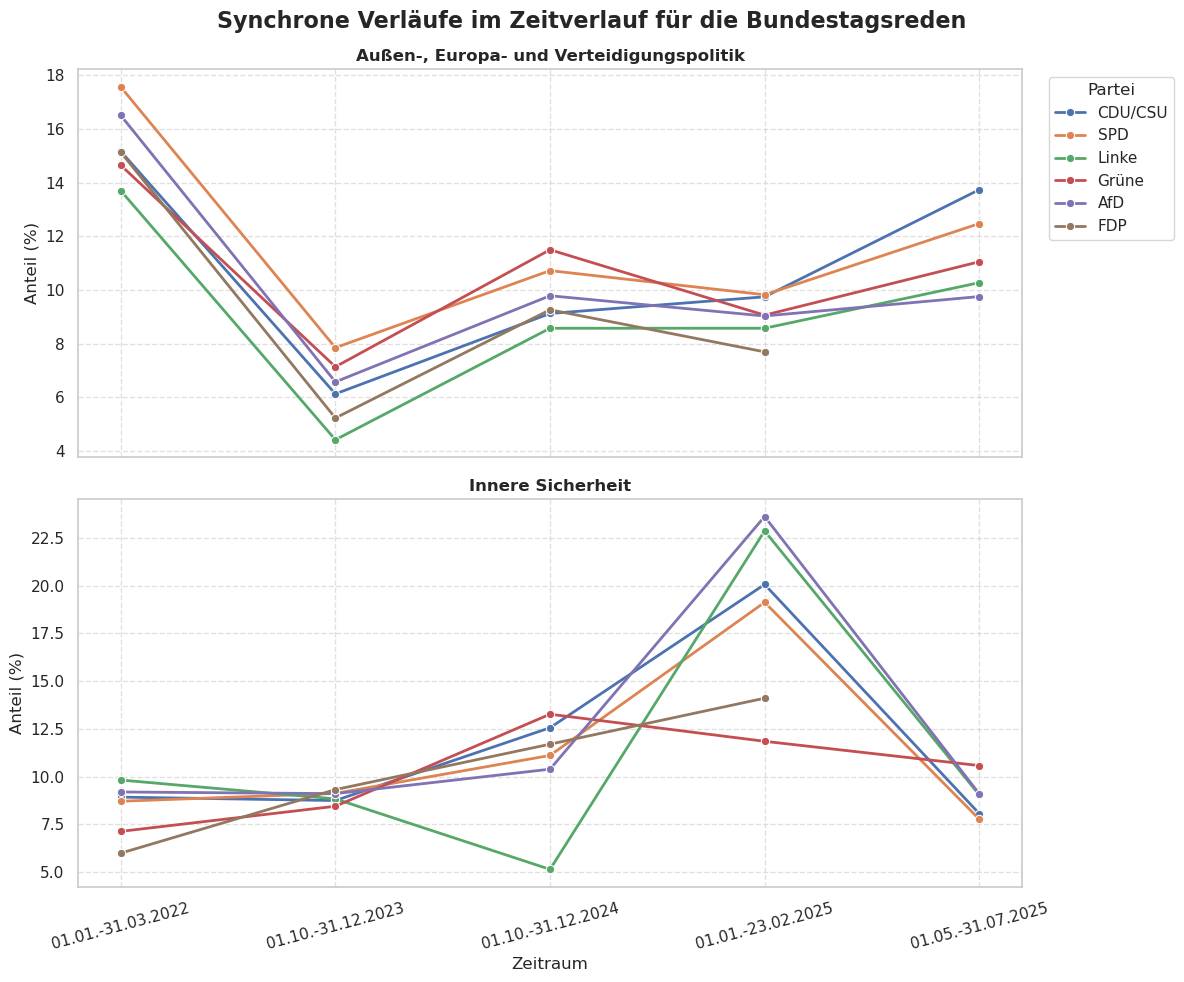

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Zeitreihenfolge für beide DataFrames als Kategorie erzwingen
zeitreihenfolge = [
    "01.01.-31.03.2022",
    "01.10.-31.12.2023",
    "01.10.-31.12.2024",
    "01.01.-23.02.2025",
    "01.05.-31.07.2025"
]

for df in [df_gesamt_außen, df_gesamt_innen]:
    if 'zeitraum_name' in df.columns:
        # Auf die 5 Zeiträume filtern
        df = df[df['zeitraum_name'].isin(zeitreihenfolge)].copy()
        # Reihenfolge festlegen
        df['zeitraum_name'] = pd.Categorical(df['zeitraum_name'], categories=zeitreihenfolge, ordered=True)

# 2. Eine Abbildung mit 2 Zeilen (untereinander) erstellen
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# --- OBERES DIAGRAMM: Außenpolitik ---
sns.lineplot(
    data=df_gesamt_außen, 
    x='zeitraum_name', 
    y='anteil', 
    hue='partei', 
    hue_order=partei_namen,
    marker='o',
    linewidth=2,
    ax=ax1 # Zeichnet in das obere Feld
)
ax1.set_title('Außen-, Europa- und Verteidigungspolitik', fontsize=12, fontweight='bold')
ax1.set_ylabel('Anteil (%)')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(title='Partei', bbox_to_anchor=(1.02, 1), loc='upper left')

# --- UNTERES DIAGRAMM: Innenpolitik ---
sns.lineplot(
    data=df_gesamt_innen, 
    x='zeitraum_name', 
    y='anteil', 
    hue='partei', 
    hue_order=partei_namen,
    marker='o',
    linewidth=2,
    ax=ax2 # Zeichnet in das untere Feld
)
ax2.set_title('Innere Sicherheit', fontsize=12, fontweight='bold')
ax2.set_xlabel('Zeitraum')
ax2.set_ylabel('Anteil (%)')
ax2.grid(True, linestyle='--', alpha=0.6)
# Legende unten ausblenden, da sie oben identisch ist (spart Platz)
ax2.get_legend().remove() 

# X-Achsen-Beschriftung leicht drehen für bessere Lesbarkeit
plt.xticks(rotation=15)

# Gesamt-Styling der Abbildung
fig.suptitle('Synchrone Verläufe im Zeitverlauf für die Bundestagsreden', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()

plt.savefig('synchrone_verläufe.jpg', dpi=300, bbox_inches='tight')

plt.show()


In [76]:
# Verläufe zum Thema "Umweltpolitik"

In [77]:
# Filtern der Zeilen nach dem gewünschten Topic
cdu_data_umwelt = cdu_data[cdu_data['topic'] == 'Umweltpolitik'].copy()
spd_data_umwelt = spd_data[spd_data['topic'] == 'Umweltpolitik'].copy()
linke_data_umwelt = linke_data[linke_data['topic'] == 'Umweltpolitik'].copy()
grüne_data_umwelt = grüne_data[grüne_data['topic'] == 'Umweltpolitik'].copy()
afd_data_umwelt = afd_data[afd_data['topic'] == 'Umweltpolitik'].copy()
fdp_data_umwelt = fdp_data[fdp_data['topic'] == 'Umweltpolitik'].copy()

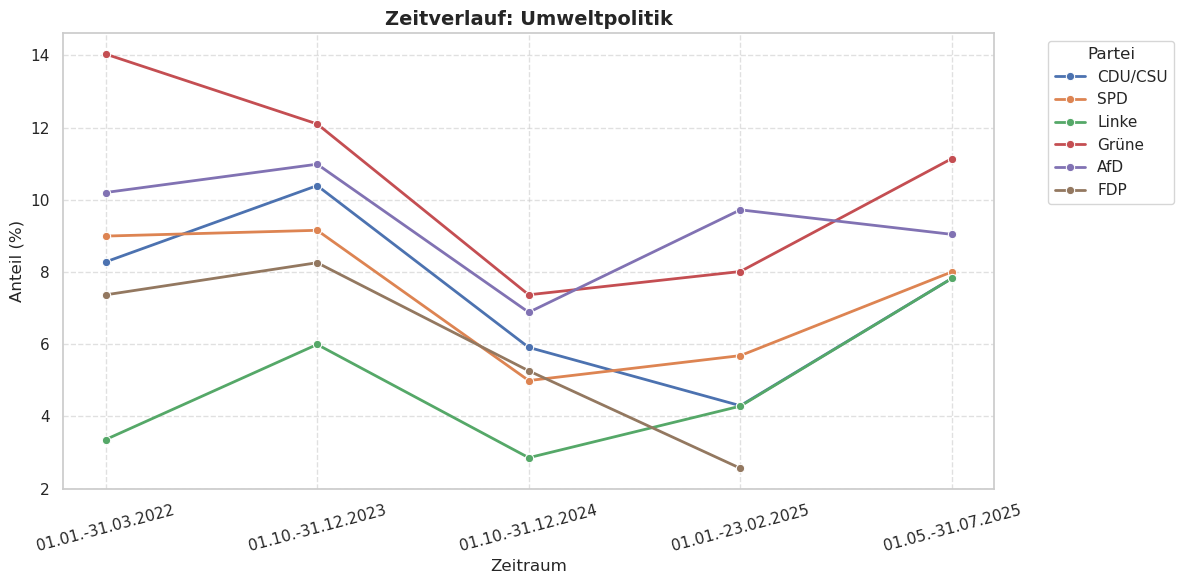

In [78]:
# 1. Alle DataFrames in einer Liste sammeln und verknüpfen
dfs = [cdu_data_umwelt, spd_data_umwelt, linke_data_umwelt, grüne_data_umwelt, afd_data_umwelt, fdp_data_umwelt]
df_gesamt_umwelt = pd.concat(dfs, ignore_index=True)

# 2. Gewünschte Zeiträume in der exakten chronologischen Reihenfolge definieren
zeitreihenfolge = [
    "01.01.-31.03.2022",
    "01.10.-31.12.2023",
    "01.10.-31.12.2024",
    "01.01.-23.02.2025",
    "01.05.-31.07.2025"
]

# 3. Daten auf diese 5 Zeiträume filtern
df_gesamt_umwelt = df_gesamt_umwelt[df_gesamt_umwelt['zeitraum_name'].isin(zeitreihenfolge)].copy()

# 4. Zeitraum-Spalte als 'Kategorie' mit fester Reihenfolge definieren (wichtig für die X-Achse)
df_gesamt_umwelt['zeitraum_name'] = pd.Categorical(df_gesamt_umwelt['zeitraum_name'], categories=zeitreihenfolge, ordered=True)

# 5. Liniendiagramm erstellen
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_gesamt_umwelt, 
    x='zeitraum_name', 
    y='anteil', 
    hue='partei', 
    hue_order=partei_namen,  # Nutzt deine definierte Liste für die Legende
    marker='o',
    linewidth=2
)

# Diagramm-Styling
plt.title('Zeitverlauf: Umweltpolitik', fontsize=14, fontweight='bold')
plt.xlabel('Zeitraum', fontsize=12)
plt.ylabel('Anteil (%)', fontsize=12)
plt.xticks(rotation=15)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Partei', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

In [79]:
# Verläufe zum Thema "Wohnungsmarktpolitik"

In [80]:
# Filtern der Zeilen nach dem gewünschten Topic
cdu_data_wohnen = cdu_data[cdu_data['topic'] == 'Wohnungsmarktpolitik'].copy()
spd_data_wohnen = spd_data[spd_data['topic'] == 'Wohnungsmarktpolitik'].copy()
linke_data_wohnen = linke_data[linke_data['topic'] == 'Wohnungsmarktpolitik'].copy()
grüne_data_wohnen = grüne_data[grüne_data['topic'] == 'Wohnungsmarktpolitik'].copy()
afd_data_wohnen = afd_data[afd_data['topic'] == 'Wohnungsmarktpolitik'].copy()
fdp_data_wohnen = fdp_data[fdp_data['topic'] == 'Wohnungsmarktpolitik'].copy()

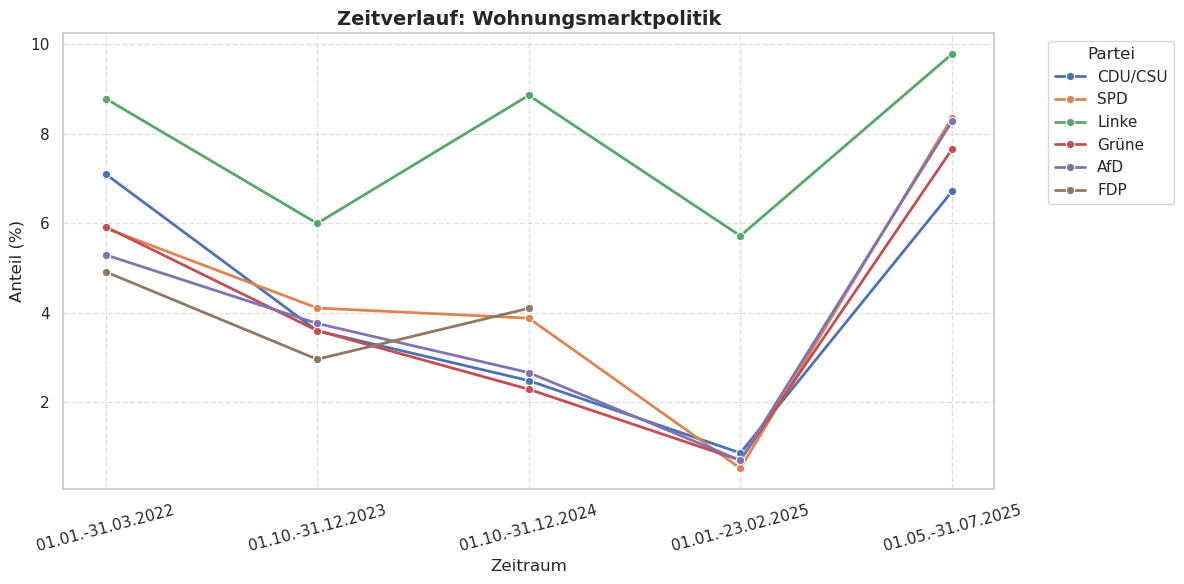

In [81]:
# 1. Alle DataFrames in einer Liste sammeln und verknüpfen
dfs = [cdu_data_wohnen, spd_data_wohnen, linke_data_wohnen, grüne_data_wohnen, afd_data_wohnen, fdp_data_wohnen]
df_gesamt_wohnen = pd.concat(dfs, ignore_index=True)

# 2. Gewünschte Zeiträume in der exakten chronologischen Reihenfolge definieren
zeitreihenfolge = [
    "01.01.-31.03.2022",
    "01.10.-31.12.2023",
    "01.10.-31.12.2024",
    "01.01.-23.02.2025",
    "01.05.-31.07.2025"
]

# 3. Daten auf diese 5 Zeiträume filtern
df_gesamt_wohnen = df_gesamt_wohnen[df_gesamt_wohnen['zeitraum_name'].isin(zeitreihenfolge)].copy()

# 4. Zeitraum-Spalte als 'Kategorie' mit fester Reihenfolge definieren (wichtig für die X-Achse)
df_gesamt_wohnen['zeitraum_name'] = pd.Categorical(df_gesamt_wohnen['zeitraum_name'], categories=zeitreihenfolge, ordered=True)

# 5. Liniendiagramm erstellen
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_gesamt_wohnen, 
    x='zeitraum_name', 
    y='anteil', 
    hue='partei', 
    hue_order=partei_namen,  # Nutzt deine definierte Liste für die Legende
    marker='o',
    linewidth=2
)

# Diagramm-Styling
plt.title('Zeitverlauf: Wohnungsmarktpolitik', fontsize=14, fontweight='bold')
plt.xlabel('Zeitraum', fontsize=12)
plt.ylabel('Anteil (%)', fontsize=12)
plt.xticks(rotation=15)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Partei', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

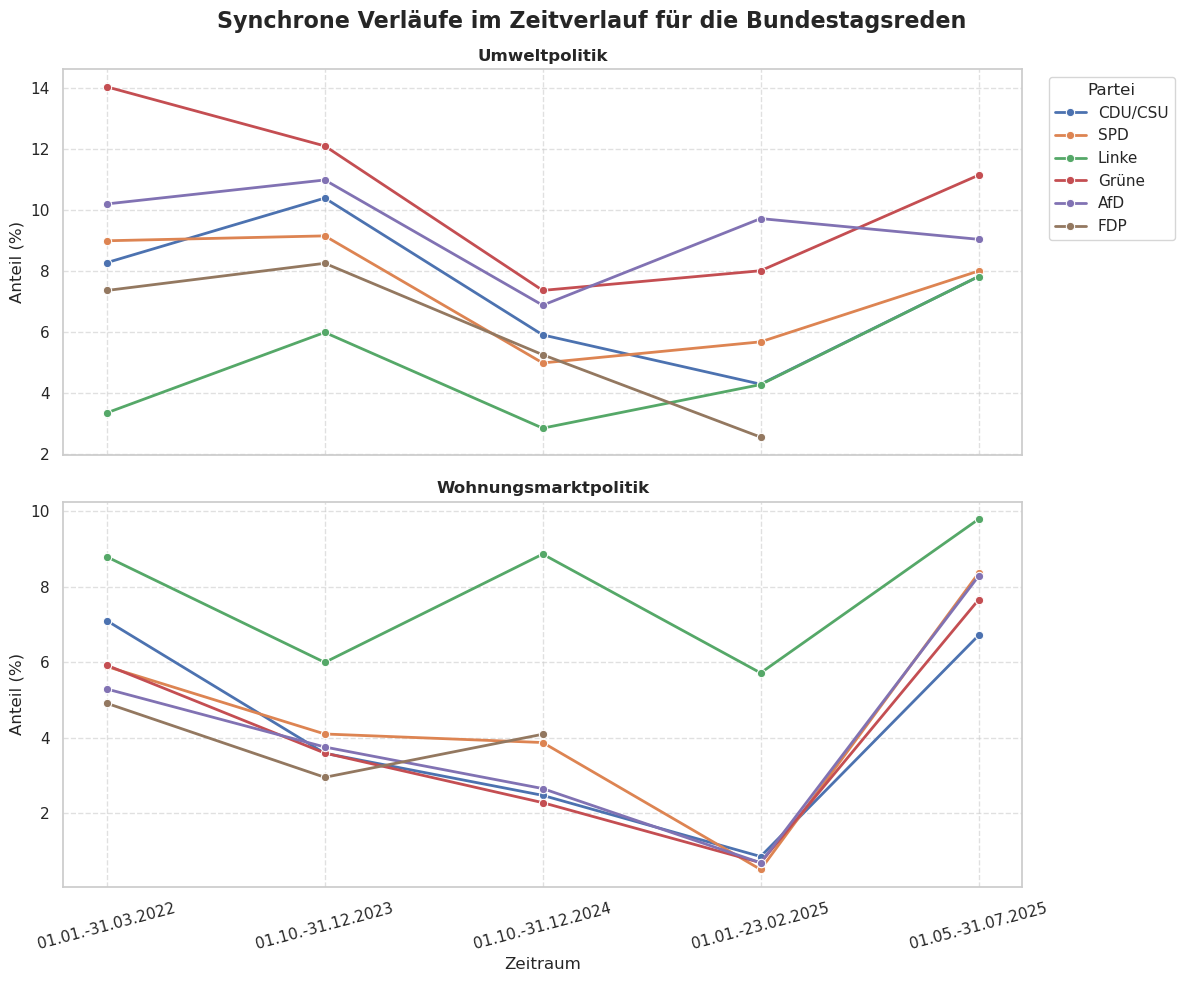

In [82]:
# 1. Zeitreihenfolge für beide DataFrames als Kategorie erzwingen
zeitreihenfolge = [
    "01.01.-31.03.2022",
    "01.10.-31.12.2023",
    "01.10.-31.12.2024",
    "01.01.-23.02.2025",
    "01.05.-31.07.2025"
]

for df in [df_gesamt_umwelt, df_gesamt_wohnen]:
    if 'zeitraum_name' in df.columns:
        # Auf die 5 Zeiträume filtern
        df = df[df['zeitraum_name'].isin(zeitreihenfolge)].copy()
        # Reihenfolge festlegen
        df['zeitraum_name'] = pd.Categorical(df['zeitraum_name'], categories=zeitreihenfolge, ordered=True)

# 2. Eine Abbildung mit 2 Zeilen (untereinander) erstellen
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# --- OBERES DIAGRAMM: Umweltpolitik ---
sns.lineplot(
    data=df_gesamt_umwelt, 
    x='zeitraum_name', 
    y='anteil', 
    hue='partei', 
    hue_order=partei_namen,
    marker='o',
    linewidth=2,
    ax=ax1 # Zeichnet in das obere Feld
)
ax1.set_title('Umweltpolitik', fontsize=12, fontweight='bold')
ax1.set_ylabel('Anteil (%)')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(title='Partei', bbox_to_anchor=(1.02, 1), loc='upper left')

# --- UNTERES DIAGRAMM: Wohnungsmarktpolitik, ---
sns.lineplot(
    data=df_gesamt_wohnen, 
    x='zeitraum_name', 
    y='anteil', 
    hue='partei', 
    hue_order=partei_namen,
    marker='o',
    linewidth=2,
    ax=ax2 # Zeichnet in das untere Feld
)
ax2.set_title('Wohnungsmarktpolitik', fontsize=12, fontweight='bold')
ax2.set_xlabel('Zeitraum')
ax2.set_ylabel('Anteil (%)')
ax2.grid(True, linestyle='--', alpha=0.6)
# Legende unten ausblenden, da sie oben identisch ist (spart Platz)
ax2.get_legend().remove() 

# X-Achsen-Beschriftung leicht drehen für bessere Lesbarkeit
plt.xticks(rotation=15)

# Gesamt-Styling der Abbildung
fig.suptitle('Synchrone Verläufe im Zeitverlauf für die Bundestagsreden', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()

plt.savefig('synchrone_verläufe_2.jpg', dpi=300, bbox_inches='tight')

plt.show()

In [83]:
# ENDE